# Advanced Error Analysis — Partial Reversal vs Other Errors
### Digit Span Backwards | DBS ATN Case 1 | Sessions 2 & 3

---

## What's new in this notebook

This notebook extends `Simple_Error_Analysis.ipynb` with:

1. **Centralised metric switch** — change a single variable `METRIC` at the top of the
   Setup section and **every** plot in the notebook re-computes its statistics with
   the new metric. No per-plot edits needed.

2. **New continuous metric — Reversal Completeness Score (RCS)**
   `RCS = (# digits in the correct reversed position) / (total digits)`
   RCS turns a wrong trial into a number between 0 and 1 instead of a binary
   right/wrong flag. This lets us use parametric and non-parametric tests directly
   on per-trial scores.

3. **Five supported metrics** (each with its own tab):
   - `fisher`        — Fisher's Exact Test (binary rate: error type present yes/no)
   - `chi2`          — Chi-Square Test of Independence (stim × error-type table)
   - `wilcoxon`      — Wilcoxon Signed-Rank (paired session-level rates)
   - `rm_anova`      — Repeated-Measures ANOVA (session × stim on rates)
   - `completeness`  — t-test / Mann-Whitney U on per-trial RCS
   Effect size (Cohen's *d* or Cramér's *V*) is reported alongside the p-value
   wherever it is statistically meaningful.

4. **Clean plot styling** — wrapped titles, no overlapping text, a metric badge
   on every panel so you never have to guess which test produced the numbers.

---

## Condition B still active (from Simple_Error_Analysis)

- `stim_present_condA` = any packet ≥ 2.0 mA anywhere in trial
- `feedback_only_stim` = stim present but ONLY in feedback window
  (`pre_fb_frac < 0.3` AND `fb_frac ≥ 0.3`)
- `stim_present_condB` = `stim_present_condA AND NOT feedback_only_stim`

---

## Error taxonomy (wrong trials only)

| Category | Rule | Example |
|---|---|---|
| **PARTIAL_REVERSAL** | `resp[0] == presented[-1]` — started reversing but didn't finish | presented `568` → resp `856` |
| **OTHER** (permutation) | Same digit multiset as presented, but no reversal signature | presented `5463` → resp `4653` |
| ~~DIFFERENT_NUMBER~~ | Response contains a digit not in the presented set — **excluded** | presented `352` → resp `256` |


---

# 1. Setup

Change `METRIC` below to switch the statistics used across **every** plot.


In [203]:
# ── Cell: Imports & display settings ─────────────────────────────────────────
import json
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        130,
    'savefig.dpi':       160,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# ── Colour palette ──────────────────────────────────────────────────────────
C_NO_STIM = '#90A4AE'
C_STIM    = '#1A56DB'
C_CORRECT = '#2E7D32'
C_WRONG   = '#C62828'
C_PARTIAL = '#E65100'
C_OTHER   = '#6A1B9A'
C_EXCL    = '#B0BEC5'

# Partial × stim and Other × stim (reused from Simple_Error_Analysis)
C_P_NO, C_P_ON = '#FFAB76', '#E65100'
C_O_NO, C_O_ON = '#CE93D8', '#6A1B9A'

# ── Constants ───────────────────────────────────────────────────────────────
STIM_THRESHOLD       = 2.0
N_TRIALS_PER_SESSION = 14

print('Imports OK  |  Condition B active  |  STIM_THRESHOLD =', STIM_THRESHOLD, 'mA')


Imports OK  |  Condition B active  |  STIM_THRESHOLD = 2.0 mA


In [204]:
# ── Cell: THE METRIC SWITCH  ← CHANGE THIS ONE WORD ──────────────────────────
#
#   'fisher'       — Fisher exact on 2x2 binary rate of the error type
#   'chi2'         — Chi-square test of independence (stim × error-type)
#   'wilcoxon'     — Wilcoxon signed-rank on paired per-session rates
#   'rm_anova'     — Repeated-measures ANOVA on per-session rates (descriptive at n=2)
#   'completeness' — t-test (with Mann-Whitney fallback) on per-trial RCS scores

METRIC = 'completeness'

VALID_METRICS = {'fisher', 'chi2', 'wilcoxon', 'rm_anova', 'completeness'}
assert METRIC in VALID_METRICS, f"METRIC must be one of {VALID_METRICS}"
print(f'Active metric: {METRIC}')


Active metric: completeness


# 2. File paths (edit these for your machine)

In [205]:
# ── Cell: File paths  ← EDIT THESE ──────────────────────────────────────────
JSON_PATH_S2   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json")
CSV_PATH_S2    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv")
EVENTS_PATH_S2 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv")

JSON_PATH_S3   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json")
CSV_PATH_S3    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv")
EVENTS_PATH_S3 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv")

COMBINED_DIR   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals")
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

print('Paths set.')


Paths set.


# 3. Data loading & trial classification

Carried over from `Simple_Error_Analysis.ipynb` — unchanged.


In [206]:
# ── Cell: Trial loading & stim classification (unchanged from simple notebook) ──
def load_session_data(json_path, csv_path, events_path):
    with open(json_path) as f:
        report = json.load(f)
    eprime_df = pd.read_csv(csv_path,    encoding='utf-8-sig', low_memory=False)
    ev_df     = pd.read_csv(events_path, encoding='utf-8-sig', low_memory=False)

    meta = dict(
        subject=str(eprime_df['Subject'].iloc[0]),
        session=str(eprime_df['Session'].iloc[0]),
        date=str(eprime_df['SessionDate'].iloc[0]),
    )

    stim_tick = None
    for stream in report['BrainSenseLfp']:
        prev = None
        for pkt in stream['LfpData']:
            curr = pkt['Left']['mA']
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_tick = pkt['TicksInMs']
                break
            prev = curr
        if stim_tick:
            break
    assert stim_tick, 'No 0->+mA transition in BrainSenseLfp!'

    welcome_ms    = int(eprime_df['Welcome.TargetOnsetTime'].iloc[0])
    MANUAL_OFFSET = stim_tick - welcome_ms
    def to_rel(ms): return float(ms) + MANUAL_OFFSET - stim_tick

    ticks, mAs = [], []
    for stream in report['BrainSenseLfp']:
        for pkt in stream['LfpData']:
            ticks.append(pkt['TicksInMs'])
            mAs.append(pkt['Left']['mA'])
    ticks = np.array(ticks, dtype=float)
    mAs   = np.array(mAs,   dtype=float)
    order = np.argsort(ticks)
    ticks_rel = ticks[order] - stim_tick
    mAs       = mAs[order]

    print(f"Loaded: Subject={meta['subject']}  Session={meta['session']}  "
          f"mA_max={mAs.max():.2f}  N_packets={len(ticks)}")
    return report, eprime_df, ev_df, meta, to_rel, ticks_rel, mAs


def stim_frac_in_window(t0, t1, ticks_rel, mAs, threshold=2.0):
    if t0 is None or t1 is None or t1 <= t0:
        return 0.0
    mask = (ticks_rel >= t0) & (ticks_rel <= t1)
    t_r, t_m = ticks_rel[mask], mAs[mask]
    if len(t_r) < 2:
        return 0.0
    dt    = np.diff(t_r)
    mid   = (t_m[:-1] + t_m[1:]) / 2.0
    total = t_r[-1] - t_r[0]
    return float(np.sum(dt[mid >= threshold]) / total) if total > 0 else 0.0


def peak_mA(t0, t1, ticks_rel, mAs):
    if t0 is None or t1 is None or t1 <= t0:
        return 0.0
    mask = (ticks_rel >= t0) & (ticks_rel <= t1)
    if not mask.any():
        idx = int(np.argmin(np.abs(ticks_rel - (t0 + t1) / 2)))
        return float(mAs[idx])
    return float(mAs[mask].max())


def build_all_trials(eprime_df, ev_df, to_rel, ticks_rel, mAs, sess_label):
    def ev_all(etype, tn):
        return ev_df[(ev_df['Event_Type'] == etype) &
                     (ev_df['Trial_Number'] == tn)]['Time_ms'].tolist()
    def ev_first(etype, tn):
        v = ev_all(etype, tn)
        return v[0] if v else None

    trials = []
    for tn in range(1, 15):
        sr = ev_df[(ev_df['Event_Type'] == 'Main Trial Start') &
                   (ev_df['Trial_Number'] == tn)]
        if sr.empty:
            continue
        r = sr.iloc[0]

        acc     = int(r['ACC'])        if pd.notna(r['ACC'])        else None
        cresp_v = r['CRESP']           if pd.notna(r['CRESP'])      else None
        resp_v  = r['RESP']            if pd.notna(r['RESP'])       else None
        nd      = int(r['Num_Digits']) if pd.notna(r['Num_Digits']) else None
        if None in (acc, cresp_v, resp_v, nd):
            continue

        cresp_s   = str(int(cresp_v)).zfill(nd)
        resp_s    = str(int(resp_v)).zfill(nd)
        presented = cresp_s[::-1]

        t_start_ms  = ev_first('Main Trial Start', tn)
        t_end_ms    = ev_first('Main Trial End',   tn)
        t_start     = to_rel(t_start_ms) if t_start_ms else None
        t_end       = to_rel(t_end_ms)   if t_end_ms   else None

        fix_starts  = [to_rel(ms) for ms in ev_all('Fixation Start', tn)]
        stim_starts = [to_rel(ms) for ms in ev_all('Stimulus Start', tn)]
        stim_ends   = [to_rel(ms) for ms in ev_all('Stimulus End',   tn)]
        cs_ms = ev_first('Choice Start',   tn); cs = to_rel(cs_ms) if cs_ms else None
        ce_ms = ev_first('Choice End',     tn); ce = to_rel(ce_ms) if ce_ms else None
        fs_ms = ev_first('Feedback Start', tn); fs = to_rel(fs_ms) if fs_ms else None
        fe_ms = ev_first('Feedback End',   tn); fe = to_rel(fe_ms) if fe_ms else None

        trial_lo = fix_starts[0] if fix_starts else t_start
        trial_hi = fe if fe else t_end
        mask_full = (ticks_rel >= trial_lo) & (ticks_rel <= trial_hi)
        stim_present_condA = bool(mask_full.any() and np.any(mAs[mask_full] >= STIM_THRESHOLD))

        pre_fb_frac = 0.0
        if fix_starts and stim_starts:
            pre_fb_frac = max(pre_fb_frac,
                stim_frac_in_window(fix_starts[0], stim_starts[0], ticks_rel, mAs, STIM_THRESHOLD))
        if stim_starts and stim_ends:
            pre_fb_frac = max(pre_fb_frac,
                stim_frac_in_window(stim_starts[0], stim_ends[0], ticks_rel, mAs, STIM_THRESHOLD))
        if cs and ce:
            pre_fb_frac = max(pre_fb_frac,
                stim_frac_in_window(cs, ce, ticks_rel, mAs, STIM_THRESHOLD))
        fb_frac = stim_frac_in_window(fs, fe, ticks_rel, mAs, STIM_THRESHOLD) if fs and fe else 0.0

        feedback_only_stim = stim_present_condA and (pre_fb_frac < 0.3) and (fb_frac >= 0.3)
        stim_present_condB = stim_present_condA and not feedback_only_stim

        whole_peak = peak_mA(trial_lo, trial_hi, ticks_rel, mAs)

        trials.append(dict(
            session            = sess_label,
            trial_num          = tn,
            digits             = nd,
            acc                = acc,
            presented          = presented,
            cresp              = cresp_s,
            resp               = resp_s,
            stim_present       = stim_present_condA,
            stim_present_condB = stim_present_condB,
            feedback_only_stim = feedback_only_stim,
            whole_peak_mA      = round(whole_peak, 3),
        ))
    return trials


print('Core functions defined.')


Core functions defined.


# 4. Error classification + **Reversal Completeness Score (RCS)**

**RCS (Reversal Completeness Score)** is computed for every trial (including correct ones):

\[\text{RCS} = \frac{\text{# digits sitting in the correct reversed position}}{\text{total digits}}\]

- A correct trial has RCS = 1.0
- A complete failure (no digits in the right slot) has RCS = 0.0
- Partial reversals typically land between 0.2 and 0.6

RCS is continuous, which unlocks t-tests, Mann-Whitney U, and Cohen's *d* directly
on per-trial scores — richer than a binary right/wrong flag.


In [207]:
# ── Cell: Error classification + Reversal Completeness Score ────────────────
def classify_error(presented, resp):
    presented = str(presented).strip()
    resp      = str(resp).strip()
    n = max(len(presented), len(resp))
    presented = presented.zfill(n)
    resp      = resp.zfill(n)

    if sorted(resp) != sorted(presented):
        return 'DIFFERENT_NUMBER'
    if resp[0] == presented[-1]:
        return 'PARTIAL_REVERSAL'
    return 'OTHER'


def reversal_completeness_score(presented, resp):
    """
    Fraction of digits sitting in the correct reversed position.

    Target positions = presented reversed (the correct answer).
    We compare `resp` against `cresp = presented[::-1]` digit by digit.
    """
    presented = str(presented).strip()
    resp      = str(resp).strip()
    n = max(len(presented), len(resp))
    if n == 0:
        return np.nan
    presented = presented.zfill(n)
    resp      = resp.zfill(n)
    cresp = presented[::-1]
    hits = sum(1 for a, b in zip(resp, cresp) if a == b)
    return hits / n


def annotate_trials(trials):
    for t in trials:
        if t['acc'] == 1:
            t['error_type'] = 'CORRECT'
        else:
            t['error_type'] = classify_error(t['presented'], t['resp'])
        t['rcs'] = reversal_completeness_score(t['presented'], t['resp'])
    return trials


print('Error-type + RCS functions defined.')


Error-type + RCS functions defined.


In [208]:
# ── Cell: Load both sessions ────────────────────────────────────────────────
_, ep_s2, ev_s2, meta_s2, to_rel_s2, tr_s2, mA_s2 = load_session_data(
    JSON_PATH_S2, CSV_PATH_S2, EVENTS_PATH_S2)
all_s2 = annotate_trials(build_all_trials(ep_s2, ev_s2, to_rel_s2, tr_s2, mA_s2, 'Session 2'))

print()

_, ep_s3, ev_s3, meta_s3, to_rel_s3, tr_s3, mA_s3 = load_session_data(
    JSON_PATH_S3, CSV_PATH_S3, EVENTS_PATH_S3)
all_s3 = annotate_trials(build_all_trials(ep_s3, ev_s3, to_rel_s3, tr_s3, mA_s3, 'Session 3'))

all_combined = all_s2 + all_s3

sessions_info = [
    ('Session 2',        all_s2,       14),
    ('Session 3',        all_s3,       14),
    ('Combined (S2+S3)', all_combined, 28),
]
print(f'\nTrial totals — S2: {len(all_s2)}, S3: {len(all_s3)}, Combined: {len(all_combined)}')


Loaded: Subject=6  Session=2  mA_max=4.60  N_packets=386

Loaded: Subject=6  Session=3  mA_max=4.70  N_packets=378

Trial totals — S2: 14, S3: 14, Combined: 28


In [209]:
# ── Cell: Quick RCS inventory per session ──────────────────────────────────
def print_rcs_inventory(trials, sess_label):
    print('=' * 85)
    print(f'  {sess_label}  —  RCS inventory  |  Condition B  |  mA >= {STIM_THRESHOLD}')
    print('=' * 85)
    hdr = (f'  {"Trial":>5} {"Digits":>6} {"Stim":>5} {"Presented":>10} '
           f'{"Resp":>10} {"ErrorType":>18} {"RCS":>5}')
    print(hdr)
    print('  ' + '-' * 82)
    for t in trials:
        stim_str = 'ON ' if t['stim_present_condB'] else 'OFF'
        print(f'  T{t["trial_num"]:>4} {t["digits"]:>6} {stim_str:>5} '
              f'{t["presented"]:>10} {t["resp"]:>10} {t["error_type"]:>18} '
              f'{t["rcs"]:>5.2f}')
    print()

print_rcs_inventory(all_s2, 'Session 2')
print_rcs_inventory(all_s3, 'Session 3')


  Session 2  —  RCS inventory  |  Condition B  |  mA >= 2.0
  Trial Digits  Stim  Presented       Resp          ErrorType   RCS
  ----------------------------------------------------------------------------------
  T   1      2   OFF         43         34            CORRECT  1.00
  T   2      2   OFF         52         25            CORRECT  1.00
  T   3      3   ON         141        141            CORRECT  1.00
  T   4      3   OFF        235        532            CORRECT  1.00
  T   5      4   OFF       2345       5432            CORRECT  1.00
  T   6      4   OFF       1245       5432   DIFFERENT_NUMBER  0.50
  T   7      4   ON        3124       4231   PARTIAL_REVERSAL  0.50
  T   8      4   ON        1354       5341              OTHER  0.25
  T   9      4   ON        2315       5132            CORRECT  1.00
  T  10      4   ON        1432       2314   PARTIAL_REVERSAL  0.50
  T  11      4   ON        5312       1325              OTHER  0.25
  T  12      4   ON        5413       1

---

# 5. Metric explainer — what does each `METRIC` actually do?

Read this once; the math doesn't change when you swap metrics, only the formula
the plots will invoke under the hood.

### `fisher` — Fisher's Exact Test (default)
- **Question:** "Does the *rate* of a specific error type (e.g. Partial Reversal)
  differ between Stim-OFF and Stim-ON?"
- **Data:** 2 × 2 contingency table of counts.
- **Why use it:** Exact, handles small samples (we have ≤ 14 trials per session),
  no distributional assumptions.
- **Effect size:** Cohen's *d* on the two 0/1 vectors.

### `chi2` — Chi-Square Test of Independence
- **Question:** "Is the **stim condition** (OFF / ON) related to **which error type**
  the patient makes?"
- **Data:** 2 × 2 or 2 × 3 contingency table (stim × {Partial, Other[, Correct]}).
- **Why use it:** Tests the *overall* association, not just one error type at a time.
  Good when you want a single p-value for the full error × stim grid.
- **Effect size:** Cramér's *V* (0 = no association, 1 = perfect).
- **Caveat:** Requires expected counts ≥ 5 per cell; with our sample sizes we fall
  back to the asymptotic test and flag the warning.

### `wilcoxon` — Wilcoxon Signed-Rank Test
- **Question:** "Across sessions, does the same patient show consistently higher
  error rates under Stim-ON than under Stim-OFF?"
- **Data:** pairs of per-session rates (S2 rate, S3 rate) per stim condition.
- **Why use it:** Non-parametric paired test — the natural choice for *within-subject*
  repeated measures with few sessions.
- **Caveat:** With n = 2 sessions the test has essentially no power; it is reported
  here for structure but should be interpreted descriptively until more sessions arrive.

### `rm_anova` — Repeated-Measures ANOVA
- **Question:** "After accounting for session-to-session baseline differences, does
  Stim-ON vs Stim-OFF explain a meaningful chunk of the variance in error rates?"
- **Data:** long-form table `(session × stim_condition → rate)`.
- **Why use it:** Models session as a random within-subject factor, stim as the
  within-subject condition of interest.
- **Caveat:** Again, 2 sessions ≪ the ≥ 5 usually wanted. We compute the F-ratio and
  report it but **label any p-value at n = 2 as descriptive**.

### `completeness` — RCS test (t-test or Mann-Whitney U)
- **Question:** "Is the **Reversal Completeness Score** on individual trials lower
  when stim is ON?"
- **Data:** per-trial RCS values, one vector for OFF, one for ON.
- **Why use it:** RCS is continuous, so we can use actual *t*-tests and get a real
  Cohen's *d* effect size instead of a proportion estimate.
- **Implementation:** Welch's *t*-test by default; Shapiro-Wilk checks normality and
  we fall back to Mann-Whitney U if either group deviates strongly from normality
  (p_Shapiro < 0.05).


In [210]:
# ── Cell: Generic helpers (Cohen's d, labels, stars) ────────────────────────
def cohens_d(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt(((len(a)-1)*np.var(a, ddof=1) +
                      (len(b)-1)*np.var(b, ddof=1)) / (len(a)+len(b)-2))
    return float((np.mean(a) - np.mean(b)) / pooled) if pooled > 0 else np.nan


def effect_label(d):
    if d is None or np.isnan(d): return 'N/A'
    v = abs(d)
    if v >= 0.8: return 'large'
    if v >= 0.5: return 'medium'
    if v >= 0.2: return 'small'
    return 'negligible'


def cramers_v(table):
    """Cramér's V from a contingency table. Returns nan if table is degenerate."""
    table = np.asarray(table, float)
    if table.sum() == 0 or table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    try:
        chi2, _, _, _ = stats.chi2_contingency(table, correction=False)
    except Exception:
        return np.nan
    n = table.sum()
    k = min(table.shape) - 1
    return float(np.sqrt(chi2 / (n * k))) if k > 0 else np.nan


def v_label(v):
    """Cramér's V effect-size label."""
    if v is None or np.isnan(v): return 'N/A'
    if v >= 0.5: return 'large'
    if v >= 0.3: return 'medium'
    if v >= 0.1: return 'small'
    return 'negligible'


def sig_stars(p):
    if p is None or np.isnan(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'


def save_fig(fig, path):
    fig.savefig(path, bbox_inches='tight', dpi=160, facecolor='white')
    plt.show()
    plt.close(fig)
    print(f'Saved -> {path}')


print('Generic helpers defined.')


Generic helpers defined.


In [211]:
# ── Cell: The single dispatcher — every plot calls this one function ────────
#
# Input: two *sets of trial dicts* to compare, plus a label for the target
#        category (error_type string like 'PARTIAL_REVERSAL' or 'OTHER').
#
# Output: a dict with p_value, effect value, effect label, metric name, etc.
#         Each metric populates the same dict so plot code never branches.

def run_metric(no_stim_trials, stim_on_trials, target_error,
               paired_rates_off=None, paired_rates_on=None,
               metric=None):
    """
    Parameters
    ----------
    no_stim_trials, stim_on_trials : list of trial dicts
        The two groups being compared (wrong trials only, already filtered).
    target_error : str
        'PARTIAL_REVERSAL' or 'OTHER' — which rate we are testing.
    paired_rates_off, paired_rates_on : list of floats, optional
        Per-session rates of `target_error` for Wilcoxon / RM-ANOVA.
        Ignored for other metrics.
    metric : str, optional
        Override the global METRIC (used by plots that want multiple tests).

    Returns
    -------
    dict with keys: metric, p_value, stat, effect, effect_label, stars,
                    n_off, n_on, pct_off, pct_on, count_off, count_on,
                    stat_name, effect_name, note
    """
    m = metric if metric is not None else METRIC

    # Binary 0/1 vectors (used by fisher, chi2, completeness fallback)
    vec_off = np.array([1 if t['error_type'] == target_error else 0
                        for t in no_stim_trials], float)
    vec_on  = np.array([1 if t['error_type'] == target_error else 0
                        for t in stim_on_trials], float)

    n_off, n_on = len(vec_off), len(vec_on)
    c_off, c_on = int(vec_off.sum()), int(vec_on.sum())
    pct_off = 100 * vec_off.mean() if n_off > 0 else np.nan
    pct_on  = 100 * vec_on.mean()  if n_on  > 0 else np.nan

    result = dict(
        metric       = m,
        p_value      = np.nan,
        stat         = np.nan,
        effect       = np.nan,
        effect_label = 'N/A',
        stars        = '',
        n_off        = n_off,
        n_on         = n_on,
        pct_off      = pct_off,
        pct_on       = pct_on,
        count_off    = c_off,
        count_on     = c_on,
        stat_name    = '',
        effect_name  = '',
        note         = '',
    )

    # ── FISHER ──────────────────────────────────────────────────────────────
    if m == 'fisher':
        if n_off > 0 and n_on > 0:
            _, p = stats.fisher_exact([[c_off, n_off - c_off],
                                       [c_on,  n_on  - c_on]])
            result['p_value'] = float(p)
        result['effect'] = cohens_d(vec_off, vec_on)
        result['stat_name']   = "Fisher's exact"
        result['effect_name'] = "Cohen's d"
        result['effect_label'] = effect_label(result['effect'])

    # ── CHI-SQUARE ──────────────────────────────────────────────────────────
    elif m == 'chi2':
        table = np.array([[c_off, n_off - c_off],
                          [c_on,  n_on  - c_on]], float)
        if table.sum() > 0 and table.shape == (2, 2) and table.min() >= 0:
            try:
                chi2, p, dof, expected = stats.chi2_contingency(table, correction=False)
                result['stat']    = float(chi2)
                result['p_value'] = float(p)
                if (expected < 5).any():
                    result['note'] = 'expected<5 — interpret with care'
            except Exception:
                pass
        result['effect'] = cramers_v(table)
        result['stat_name']   = 'Chi-square'
        result['effect_name'] = "Cramer's V"
        result['effect_label'] = v_label(result['effect'])

    # ── WILCOXON (paired per-session rates) ─────────────────────────────────
    elif m == 'wilcoxon':
        if paired_rates_off is None or paired_rates_on is None:
            result['note'] = 'paired rates not supplied'
        else:
            a = np.asarray(paired_rates_off, float)
            b = np.asarray(paired_rates_on,  float)
            if len(a) == len(b) and len(a) >= 1:
                diffs = a - b
                if len(diffs) >= 1 and np.any(diffs != 0):
                    try:
                        w, p = stats.wilcoxon(a, b, zero_method='wilcox',
                                              alternative='two-sided')
                        result['stat']    = float(w)
                        result['p_value'] = float(p)
                    except Exception as e:
                        result['note'] = f'wilcoxon failed ({e})'
                else:
                    result['note'] = 'all paired diffs = 0'
            else:
                result['note'] = 'need equal-length paired rates'
            result['effect'] = cohens_d(a, b) if (len(a) >= 2 and len(b) >= 2) else np.nan
        result['stat_name']   = 'Wilcoxon signed-rank'
        result['effect_name'] = "Cohen's d (paired)"
        result['effect_label'] = effect_label(result['effect'])
        if len(paired_rates_off or []) < 5:
            result['note'] = (result['note'] + ' | descriptive at n<5 sessions').strip(' |')

    # ── RM-ANOVA (session × stim on rates) ──────────────────────────────────
    elif m == 'rm_anova':
        if paired_rates_off is None or paired_rates_on is None:
            result['note'] = 'paired rates not supplied'
        else:
            a = np.asarray(paired_rates_off, float)
            b = np.asarray(paired_rates_on,  float)
            # Within-subject F-ratio on the stim factor, blocking on session.
            if len(a) == len(b) and len(a) >= 2:
                n_sess = len(a)
                all_vals = np.concatenate([a, b])
                grand = np.mean(all_vals)
                cond_means = np.array([a.mean(), b.mean()])
                subj_means = (a + b) / 2.0
                # k = 2 conditions, n = n_sess subjects (sessions)
                ss_cond  = n_sess * np.sum((cond_means - grand) ** 2)   # between conditions
                ss_subj  = 2 * np.sum((subj_means - grand) ** 2)        # between subjects
                ss_total = np.sum((all_vals - grand) ** 2)              # over all cells
                ss_err   = ss_total - ss_cond - ss_subj                 # within-subjects residual
                df_cond, df_err = 1, n_sess - 1
                if df_err >= 1 and ss_err > 1e-10:
                    ms_cond = ss_cond / df_cond
                    ms_err  = ss_err  / df_err
                    F = ms_cond / ms_err if ms_err > 0 else np.nan
                    p = 1 - stats.f.cdf(F, df_cond, df_err) if not np.isnan(F) else np.nan
                    eta_sq = ss_cond / (ss_cond + ss_err) if (ss_cond + ss_err) > 0 else np.nan
                    result['stat']    = float(F)
                    result['p_value'] = float(p)
                    result['effect']  = float(eta_sq)
                elif df_err >= 1 and ss_cond > 0:
                    # Perfectly parallel data: error SS is zero, F diverges
                    result['stat']    = np.inf
                    result['p_value'] = 0.0
                    result['effect']  = 1.0
                    result['note']    = 'ss_err=0 (perfectly parallel rates)'
                else:
                    result['note'] = 'degrees of freedom ≤ 0 or no variance'
            else:
                result['note'] = 'need ≥ 2 paired session rates'
        result['stat_name']   = 'RM-ANOVA F'
        result['effect_name'] = "partial eta^2"
        # eta-squared effect label
        e = result['effect']
        if e is None or (isinstance(e, float) and np.isnan(e)):
            result['effect_label'] = 'N/A'
        elif e >= 0.14: result['effect_label'] = 'large'
        elif e >= 0.06: result['effect_label'] = 'medium'
        elif e >= 0.01: result['effect_label'] = 'small'
        else: result['effect_label'] = 'negligible'
        if len(paired_rates_off or []) < 5:
            result['note'] = (result['note'] + ' | descriptive at n<5 sessions').strip(' |')

    # ── COMPLETENESS (per-trial RCS) ────────────────────────────────────────
    elif m == 'completeness':
        rcs_off = np.array([t['rcs'] for t in no_stim_trials if t['rcs'] is not None], float)
        rcs_on  = np.array([t['rcs'] for t in stim_on_trials if t['rcs'] is not None], float)
        if len(rcs_off) >= 2 and len(rcs_on) >= 2:
            # Decide on test based on Shapiro-Wilk normality
            use_param = True
            try:
                _, p_n1 = stats.shapiro(rcs_off)
                _, p_n2 = stats.shapiro(rcs_on)
                if min(p_n1, p_n2) < 0.05:
                    use_param = False
            except Exception:
                use_param = False
            if use_param:
                t_stat, p = stats.ttest_ind(rcs_off, rcs_on, equal_var=False)
                result['stat']    = float(t_stat)
                result['p_value'] = float(p)
                result['stat_name'] = "Welch's t"
            else:
                u, p = stats.mannwhitneyu(rcs_off, rcs_on, alternative='two-sided')
                result['stat']    = float(u)
                result['p_value'] = float(p)
                result['stat_name'] = 'Mann-Whitney U'
            result['effect'] = cohens_d(rcs_off, rcs_on)
            # Overwrite count/pct with RCS means for display clarity
            result['count_off'] = rcs_off.mean()
            result['count_on']  = rcs_on.mean()
            result['pct_off']   = 100 * rcs_off.mean()
            result['pct_on']    = 100 * rcs_on.mean()
        else:
            result['note'] = 'need ≥ 2 trials per group for RCS test'
        result['effect_name'] = "Cohen's d"
        result['effect_label'] = effect_label(result['effect'])

    result['stars'] = sig_stars(result['p_value'])
    return result


def metric_badge(res):
    """One-line string: 'Fisher  *  p=0.034  d=+0.62  [medium]'."""
    p = res['p_value']
    e = res['effect']
    p_s = f"p={p:.3f}" if not np.isnan(p) else "p=N/A"
    e_s = f"{res['effect_name']}={e:+.2f}" if not (e is None or np.isnan(e)) else f"{res['effect_name']}=N/A"
    stat_prefix = res['stat_name'] or res['metric'].title()
    stars = res['stars']
    return f"{stat_prefix}  {stars}  {p_s}  {e_s}  [{res['effect_label']}]"


def metric_badge_multiline(res):
    """Same info but wrapped for a tight stat box."""
    p = res['p_value']
    e = res['effect']
    p_s = f"p={p:.3f}" if not np.isnan(p) else "p=N/A"
    e_s = f"{res['effect_name']}={e:+.2f}" if not (e is None or np.isnan(e)) else f"{res['effect_name']}=N/A"
    stat_prefix = res['stat_name'] or res['metric'].title()
    stars = res['stars']
    return f"{stat_prefix}  {stars}\n{p_s}   {e_s}\n[{res['effect_label']}]"


def notable(res):
    p, e = res['p_value'], res['effect']
    if not np.isnan(p) and p < 0.05: return True
    if e is not None and not np.isnan(e):
        # 'notable' thresholds per effect type
        if res['effect_name'].startswith("Cohen") and abs(e) >= 0.8: return True
        if res['effect_name'].startswith("Cramer") and e >= 0.5:     return True
        if res['effect_name'] == "partial eta^2" and e >= 0.14:      return True
    return False


def draw_stat_box(ax, res, x=0.5, y=1.08, fontsize=8):
    """Draw a stat annotation above the panel (axes-coord)."""
    fc = '#FFF0F0' if notable(res) else '#F5F5F5'
    ec = '#C62828' if notable(res) else '#888888'
    ax.text(x, y, metric_badge_multiline(res),
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=fontsize, fontweight='bold', color=ec,
            linespacing=1.35,
            bbox=dict(boxstyle='round,pad=0.3', fc=fc, ec=ec, lw=1.0, alpha=0.97))


def wrap_title(text, width=58):
    return '\n'.join(textwrap.wrap(text, width=width))


print('Metric dispatcher defined.')


Metric dispatcher defined.


In [212]:
# ── Cell: Per-session paired rates (used by Wilcoxon & RM-ANOVA) ───────────
def session_error_rates(target_error):
    """
    For Wilcoxon / RM-ANOVA we need paired per-session rates of the target error.
    Returns (rates_off, rates_on) — each a list with one value per session.
    """
    rates_off, rates_on = [], []
    for sess_label, trials, _ in [('Session 2', all_s2, 14),
                                   ('Session 3', all_s3, 14)]:
        wrong = [t for t in trials if t['error_type'] in ('PARTIAL_REVERSAL', 'OTHER')]
        off = [t for t in wrong if not t['stim_present_condB']]
        on_ = [t for t in wrong if     t['stim_present_condB']]
        r_off = (sum(1 for t in off if t['error_type'] == target_error) / len(off)) if off else np.nan
        r_on  = (sum(1 for t in on_ if t['error_type'] == target_error) / len(on_)) if on_ else np.nan
        rates_off.append(r_off)
        rates_on.append(r_on)
    return rates_off, rates_on


paired_partial = session_error_rates('PARTIAL_REVERSAL')
paired_other   = session_error_rates('OTHER')
print('Paired partial rates (OFF, ON) per session:', paired_partial)
print('Paired other rates   (OFF, ON) per session:', paired_other)


Paired partial rates (OFF, ON) per session: ([nan, 1.0], [0.5, 1.0])
Paired other rates   (OFF, ON) per session: ([nan, 0.0], [0.5, 0.0])


---

# 6. Plots

Every subsequent plot uses the stat badge produced by `run_metric()`. Change
`METRIC` at the top and re-run; the badges and colours update automatically.

## Plot 1 — Trial Outcome Breakdown per Session
Pure counts. No statistical test is meaningful on a 4-category tally of a single
condition, so **no metric badge** is drawn here (by design — "if it wouldn't
make sense, don't add it just for the sake of adding").


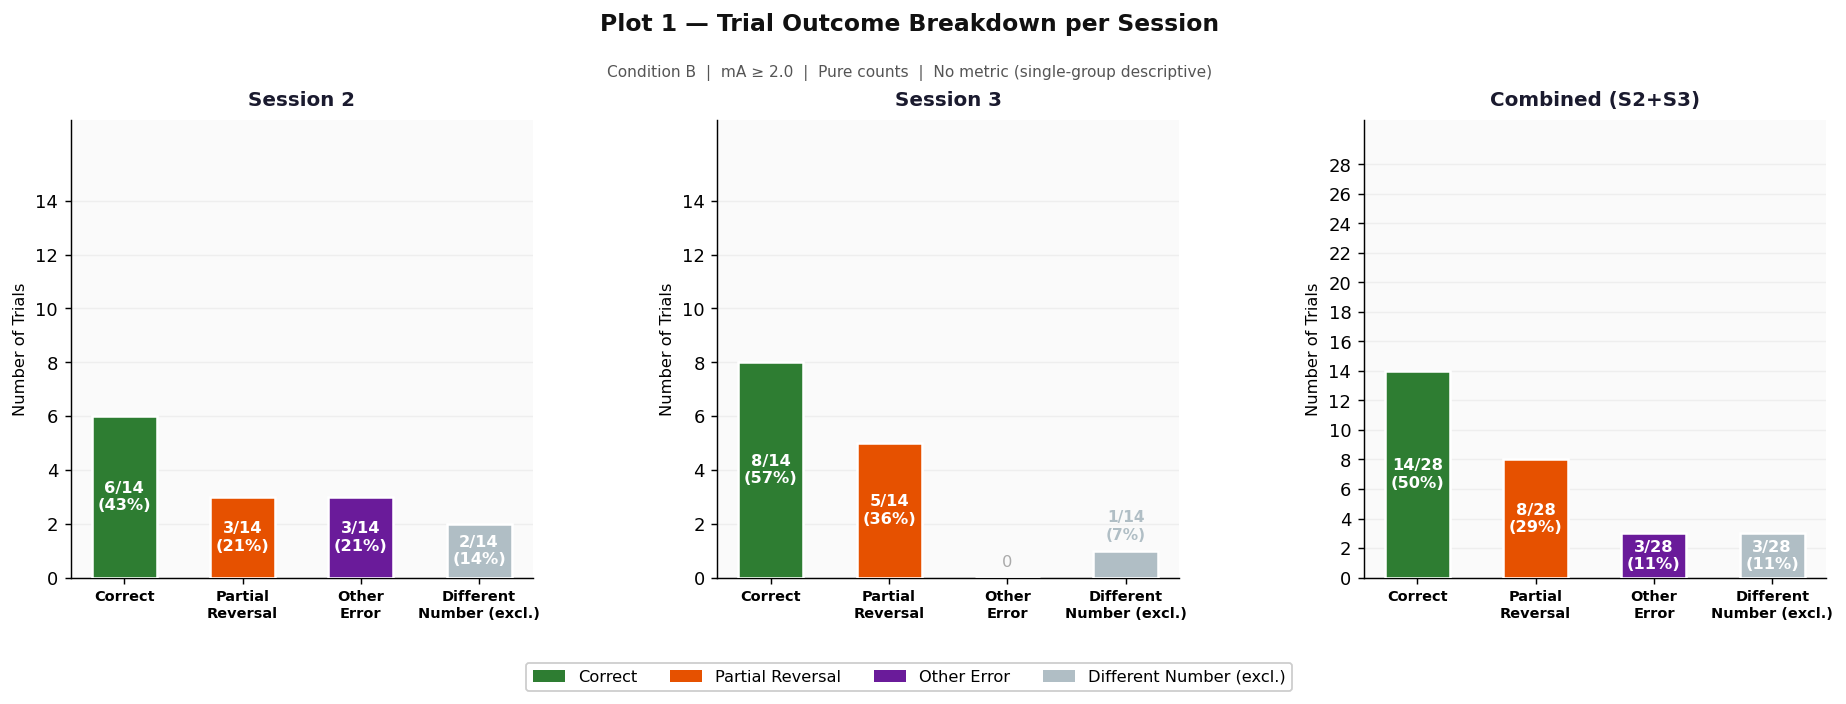

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plot1_breakdown_completeness.png


In [213]:
# ── Cell: Plot 1 — Trial outcome breakdown (no stats) ───────────────────────
def count_types(trials):
    c = {'CORRECT': 0, 'PARTIAL_REVERSAL': 0, 'OTHER': 0, 'DIFFERENT_NUMBER': 0}
    for t in trials:
        c[t['error_type']] += 1
    return c

bar_cats = [
    ('CORRECT',          C_CORRECT, 'Correct'),
    ('PARTIAL_REVERSAL', C_PARTIAL, 'Partial\nReversal'),
    ('OTHER',            C_OTHER,   'Other\nError'),
    ('DIFFERENT_NUMBER', C_EXCL,    'Different\nNumber (excl.)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), facecolor='white')
fig.subplots_adjust(wspace=0.40, top=0.82, bottom=0.18, left=0.07, right=0.97)

for ax, (sess_label, trials, n_total) in zip(axes, sessions_info):
    c = count_types(trials)
    xs     = np.arange(len(bar_cats))
    vals   = [c[bc[0]] for bc in bar_cats]
    colors = [bc[1]    for bc in bar_cats]
    ax.bar(xs, vals, width=0.55, color=colors,
           edgecolor='white', linewidth=1.4, zorder=3)
    for xi, v in enumerate(vals):
        pct = 100 * v / n_total
        lbl = f'{v}/{n_total}\n({pct:.0f}%)'
        if v >= 2:
            ax.text(xi, v/2, lbl, ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white', zorder=8)
        elif v > 0:
            ax.text(xi, v + 0.3, lbl, ha='center', va='bottom',
                    fontsize=8.5, fontweight='bold', color=colors[xi], zorder=8)
        else:
            ax.text(xi, 0.3, '0', ha='center', va='bottom',
                    fontsize=9, color='#aaa', zorder=8)
    ax.set_xticks(xs)
    ax.set_xticklabels([bc[2] for bc in bar_cats], fontsize=8, fontweight='bold')
    ax.set_ylim(0, n_total + 3)
    ax.set_yticks(range(0, n_total + 1, 2))
    ax.set_ylabel('Number of Trials', fontsize=9)
    ax.yaxis.grid(True, color='#eeeeee', zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    ax.set_title(sess_label, fontsize=11, fontweight='bold', color='#1A1A2E', pad=8)

fig.suptitle('Plot 1 — Trial Outcome Breakdown per Session',
             fontsize=13, fontweight='bold', color='#111', y=0.97)
fig.text(0.5, 0.88,
         'Condition B  |  mA ≥ 2.0  |  Pure counts  |  '
         'No metric (single-group descriptive)',
         ha='center', fontsize=8.5, color='#555')
fig.legend(handles=[mpatches.Patch(facecolor=bc[1], label=bc[2].replace('\n', ' '))
                    for bc in bar_cats],
           loc='lower center', ncol=4, fontsize=9, framealpha=0.97,
           facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))
save_fig(fig, COMBINED_DIR / f'plot1_breakdown_{METRIC}.png')


## Plot 2 — Wrong Trial Breakdown: Partial Reversal vs Other

This plot shows pure counts of the two focal error types. A metric badge *does*
make sense here when we test whether the mix of Partial vs Other differs between
Stim-OFF and Stim-ON within each scope — so we attach a per-scope metric result
using the selected `METRIC`.

- `fisher` / `completeness` → test rate of **Partial** (vs Other) between stim groups.
- `chi2` → full 2 × 2 table (stim × {Partial, Other}).
- `wilcoxon` / `rm_anova` → paired rates across sessions (only for Combined panel).


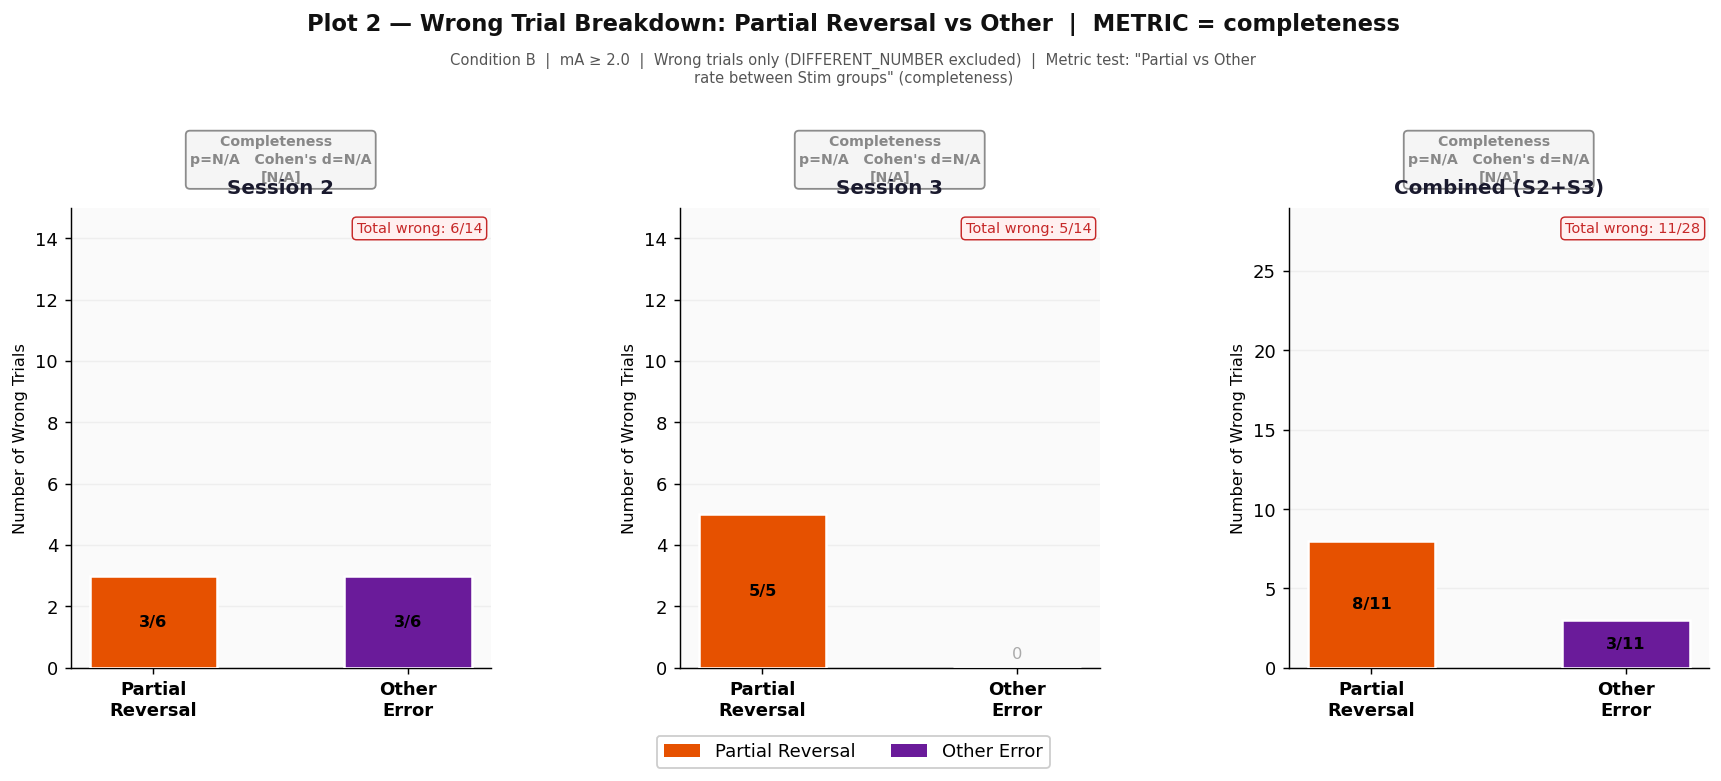

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plot2_wrong_breakdown_completeness.png


In [214]:
# ── Cell: Plot 2 — Partial vs Other (with metric badge) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), facecolor='white')
fig.subplots_adjust(wspace=0.45, top=0.74, bottom=0.15, left=0.07, right=0.97)

for ax, (sess_label, trials, n_total) in zip(axes, sessions_info):
    wrong = [t for t in trials if t['error_type'] in ('PARTIAL_REVERSAL', 'OTHER')]
    n_partial = sum(1 for t in wrong if t['error_type'] == 'PARTIAL_REVERSAL')
    n_other   = sum(1 for t in wrong if t['error_type'] == 'OTHER')
    n_wrong   = len(wrong)

    vals   = [n_partial, n_other]
    colors = [C_PARTIAL, C_OTHER]
    labels = ['Partial\nReversal', 'Other\nError']

    ax.bar([0, 1], vals, width=0.5, color=colors,
           edgecolor='white', linewidth=1.4, zorder=3)
    for xi, (v, col) in enumerate(zip(vals, colors)):
        lbl = f'{v}/{n_wrong}' if n_wrong > 0 else '0'
        if v >= 2:
            ax.text(xi, v/2, lbl, ha='center', va='center',
                    fontsize=9, fontweight='bold', color='black', zorder=8)
        elif v > 0:
            ax.text(xi, v + 0.2, lbl, ha='center', va='bottom',
                    fontsize=8.5, fontweight='bold', color=col)
        else:
            ax.text(xi, 0.2, '0', ha='center', va='bottom',
                    fontsize=9, color='#aaa')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(labels, fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(max(vals) + 3, n_total + 1))
    ax.set_ylabel('Number of Wrong Trials', fontsize=9)
    ax.yaxis.grid(True, color='#eeeeee', zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    ax.set_title(sess_label, fontsize=11, fontweight='bold', color='#1A1A2E', pad=8)

    # ── Metric: does the mix of Partial vs Other depend on stim? ───────────
    no_stim = [t for t in wrong if not t['stim_present_condB']]
    stim_on = [t for t in wrong if     t['stim_present_condB']]
    res = run_metric(no_stim, stim_on, 'PARTIAL_REVERSAL',
                     paired_rates_off=paired_partial[0] if sess_label.startswith('Combined') else None,
                     paired_rates_on=paired_partial[1] if sess_label.startswith('Combined') else None)
    draw_stat_box(ax, res, x=0.5, y=1.05, fontsize=7.8)

    ax.text(0.98, 0.97, f'Total wrong: {n_wrong}/{n_total}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8, color=C_WRONG,
            bbox=dict(boxstyle='round,pad=0.3', fc='#FFF0F0', ec=C_WRONG, lw=0.8))

fig.suptitle(wrap_title(f'Plot 2 — Wrong Trial Breakdown: Partial Reversal vs Other  '
                        f'|  METRIC = {METRIC}', width=100),
             fontsize=12.5, fontweight='bold', color='#111', y=0.99)
fig.text(0.5, 0.90,
         wrap_title('Condition B  |  mA ≥ 2.0  |  Wrong trials only (DIFFERENT_NUMBER excluded)  |  '
                    f'Metric test: "Partial vs Other rate between Stim groups" ({METRIC})', width=110),
         ha='center', fontsize=8.2, color='#555')
fig.legend(handles=[mpatches.Patch(facecolor=C_PARTIAL, label='Partial Reversal'),
                    mpatches.Patch(facecolor=C_OTHER,   label='Other Error')],
           loc='lower center', ncol=2, fontsize=10, framealpha=0.97,
           facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))
save_fig(fig, COMBINED_DIR / f'plot2_wrong_breakdown_{METRIC}.png')


## Plot 3 — Partial Reversal: Stim-OFF vs Stim-ON

Here the metric question is clean and focused: **"Does Stim-ON change the rate
(or RCS) of Partial Reversal errors?"** Every metric produces a sensible answer,
so the badge is always drawn.


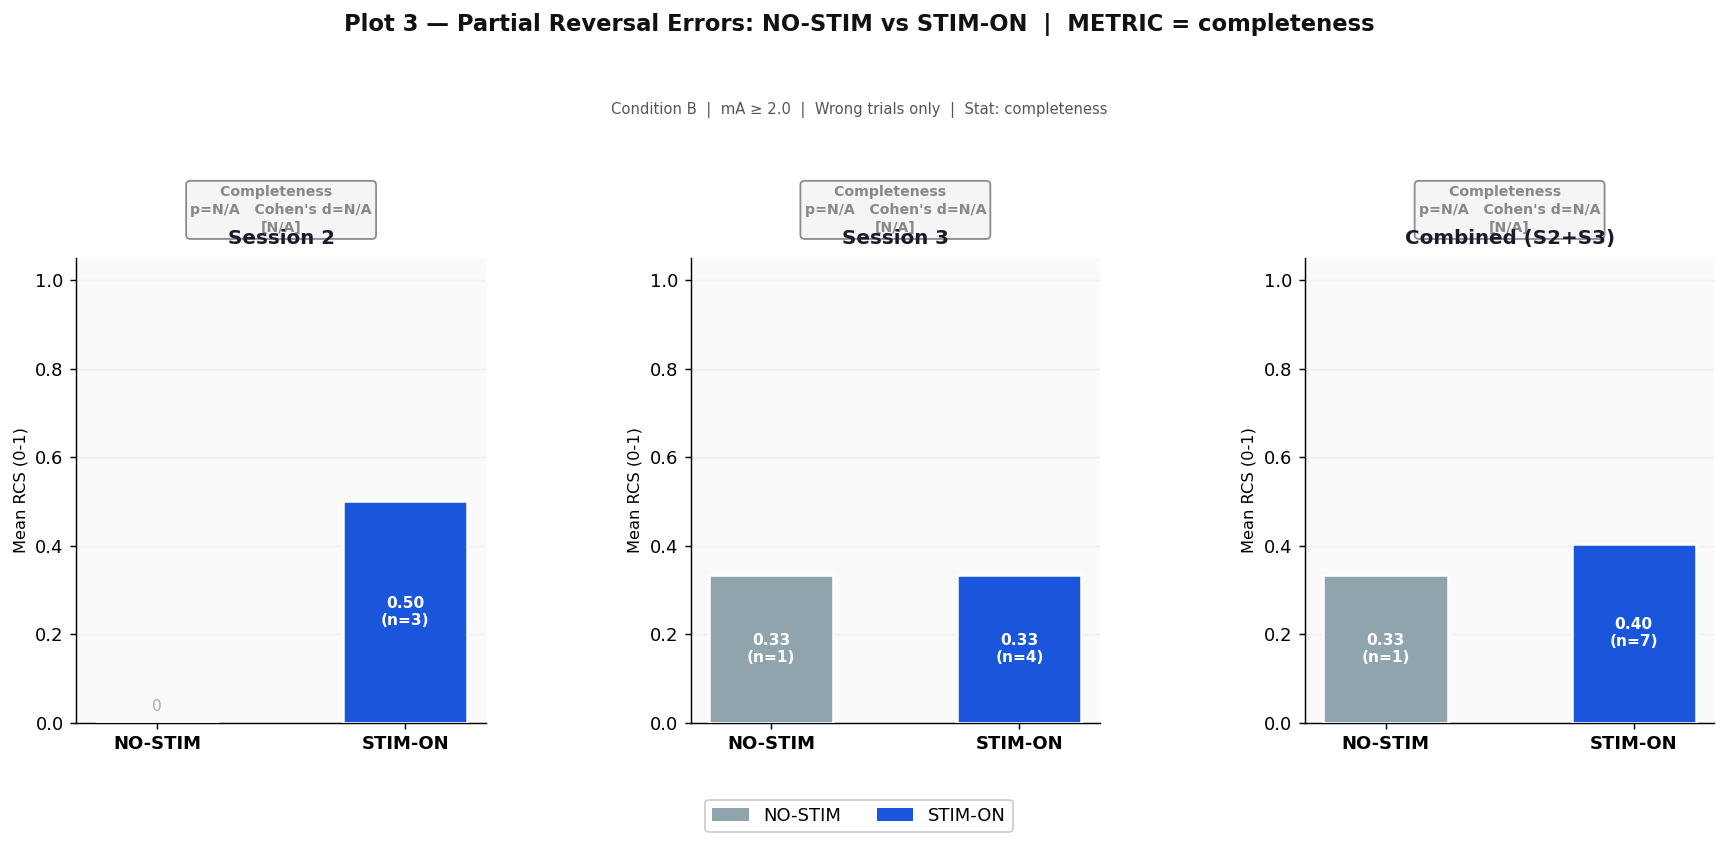

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plot3_partial_reversal_completeness.png


In [215]:
# ── Cell: Generic two-stim-group plotter (used by Plot 3 and Plot 4) ────────
def plot_error_stim_comparison(error_type, title_label, colour_off, colour_on,
                               fname, y_label='Number of Trials',
                               paired_rates=None):
    fig, axes = plt.subplots(1, 3, figsize=(14, 6.5), facecolor='white')
    fig.subplots_adjust(wspace=0.50, top=0.70, bottom=0.15, left=0.07, right=0.97)

    for ax, (sess_label, trials, n_total) in zip(axes, sessions_info):
        wrong = [t for t in trials if t['error_type'] in ('PARTIAL_REVERSAL', 'OTHER')]
        no_stim = [t for t in wrong if not t['stim_present_condB']]
        stim_on = [t for t in wrong if     t['stim_present_condB']]

        # For `completeness` we plot per-trial RCS means; for binary metrics we plot counts
        if METRIC == 'completeness':
            target = [t for t in wrong if t['error_type'] == error_type]
            # Two groups of trial RCS restricted to THIS error type
            rcs_off = [t['rcs'] for t in no_stim if t['error_type'] == error_type]
            rcs_on  = [t['rcs'] for t in stim_on if t['error_type'] == error_type]
            m_off   = np.mean(rcs_off) if rcs_off else np.nan
            m_on    = np.mean(rcs_on)  if rcs_on  else np.nan
            vals    = [0 if np.isnan(m_off) else m_off,
                       0 if np.isnan(m_on)  else m_on]
            totals  = [len(rcs_off), len(rcs_on)]
            bar_fmt = lambda v, t_: f'{v:.2f}\n(n={t_})'
            ax.set_ylim(0, 1.05)
            ax.set_yticks(np.arange(0, 1.01, 0.2))
            ax_ylabel = 'Mean RCS (0-1)'
        else:
            n_off = sum(1 for t in no_stim if t['error_type'] == error_type)
            n_on  = sum(1 for t in stim_on if t['error_type'] == error_type)
            vals    = [n_off, n_on]
            totals  = [len(no_stim), len(stim_on)]
            bar_fmt = lambda v, t_: f'{v}/{t_}'
            max_y = max(max(vals) + 2, 5)
            ax.set_ylim(0, max_y)
            ax.set_yticks(range(0, max_y + 1, 1))
            ax_ylabel = y_label

        colors = [colour_off, colour_on]
        ax.bar([0, 1], vals, width=0.5, color=colors,
               edgecolor='white', linewidth=1.4, zorder=3)
        for xi, (v, tot, col) in enumerate(zip(vals, totals, colors)):
            lbl = bar_fmt(v, tot) if tot > 0 else '0'
            if (METRIC != 'completeness' and v >= 2) or (METRIC == 'completeness' and v >= 0.15):
                ax.text(xi, v/2, lbl, ha='center', va='center',
                        fontsize=8.5, fontweight='bold', color='white', zorder=8)
            elif v > 0:
                ax.text(xi, v + 0.02, lbl, ha='center', va='bottom',
                        fontsize=8, fontweight='bold', color=col)
            else:
                ax.text(xi, 0.02, lbl if tot > 0 else '0',
                        ha='center', va='bottom', fontsize=8.5, color='#aaa')

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['NO-STIM', 'STIM-ON'], fontsize=10, fontweight='bold')
        ax.set_ylabel(ax_ylabel, fontsize=9)
        ax.yaxis.grid(True, color='#eeeeee', zorder=0)
        ax.set_axisbelow(True)
        ax.set_facecolor('#FAFAFA')
        ax.set_title(sess_label, fontsize=11, fontweight='bold', color='#1A1A2E', pad=8)

        pr_off = paired_rates[0] if paired_rates else None
        pr_on  = paired_rates[1] if paired_rates else None
        res = run_metric(no_stim, stim_on, error_type,
                         paired_rates_off=pr_off, paired_rates_on=pr_on)
        draw_stat_box(ax, res, x=0.5, y=1.05, fontsize=7.8)

    fig.suptitle(wrap_title(f'{title_label}: NO-STIM vs STIM-ON  |  METRIC = {METRIC}', width=100),
                 fontsize=12.5, fontweight='bold', color='#111', y=0.99)
    fig.text(0.5, 0.87,
             wrap_title(f'Condition B  |  mA ≥ {STIM_THRESHOLD}  |  Wrong trials only  |  '
                        f'Stat: {METRIC}', width=110),
             ha='center', fontsize=8.2, color='#555')
    fig.legend(handles=[mpatches.Patch(facecolor=colour_off, label='NO-STIM'),
                        mpatches.Patch(facecolor=colour_on,  label='STIM-ON')],
               loc='lower center', ncol=2, fontsize=10, framealpha=0.97,
               facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))
    save_fig(fig, COMBINED_DIR / fname)


# Plot 3 — Partial Reversal
plot_error_stim_comparison(
    error_type   = 'PARTIAL_REVERSAL',
    title_label  = 'Plot 3 — Partial Reversal Errors',
    colour_off   = C_NO_STIM,
    colour_on    = C_STIM,
    fname        = f'plot3_partial_reversal_{METRIC}.png',
    y_label      = 'Partial Reversal Count',
    paired_rates = paired_partial,
)


## Plot 4 — Other (Permutation) Errors: Stim-OFF vs Stim-ON

Same structure as Plot 3 but targeting the Other / permutation error category.


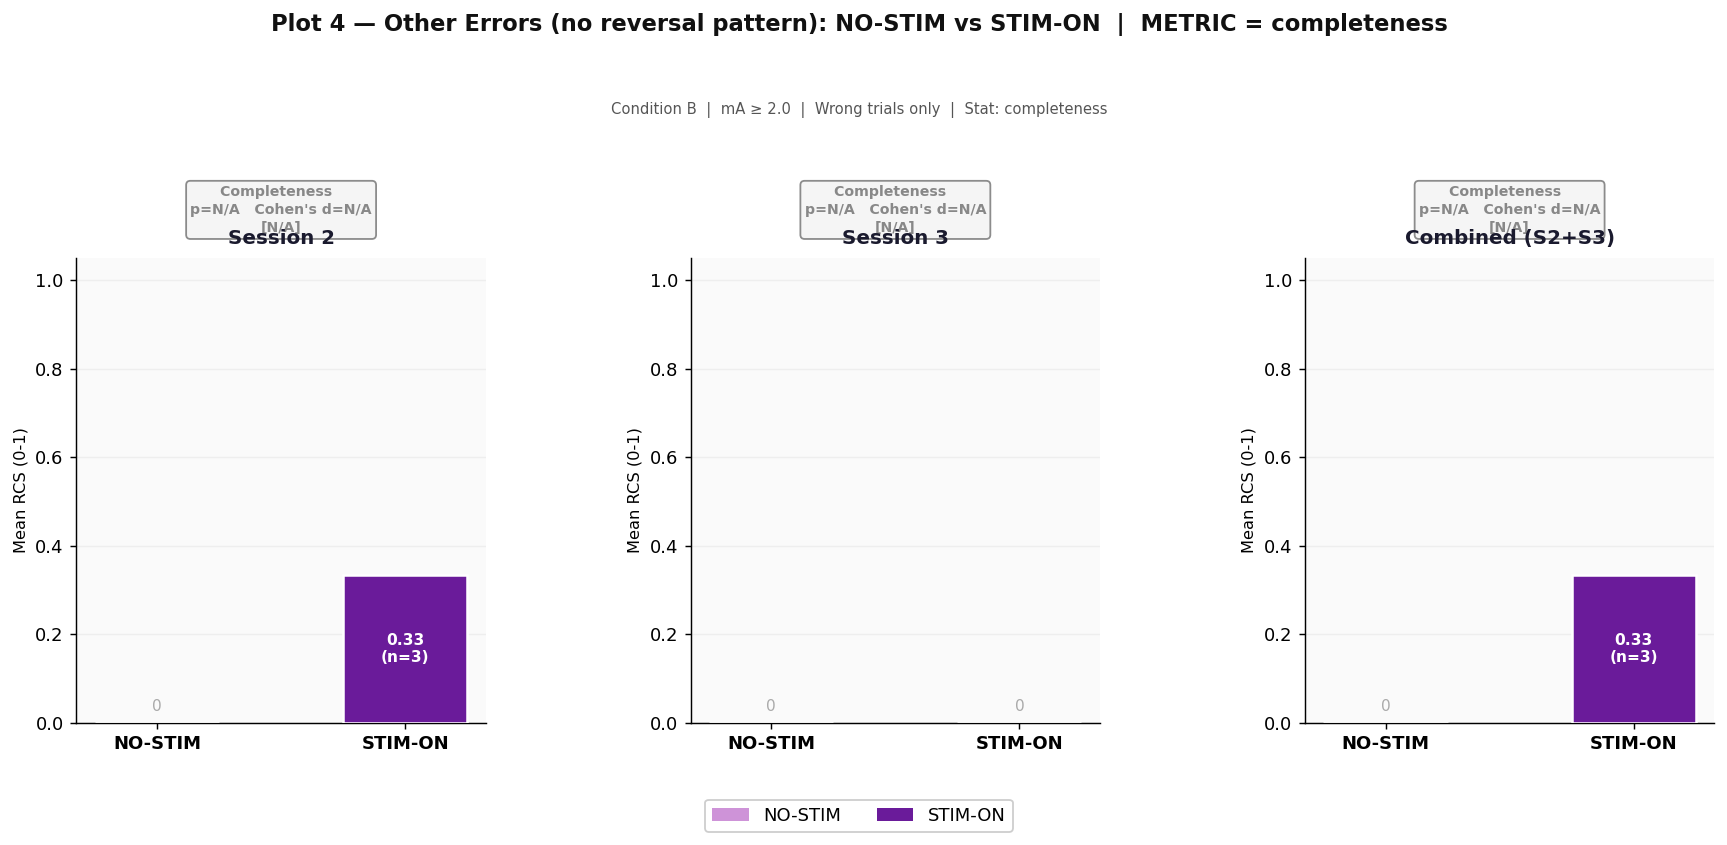

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plot4_other_errors_completeness.png


In [216]:
# ── Cell: Plot 4 — Other errors ────────────────────────────────────────────
plot_error_stim_comparison(
    error_type   = 'OTHER',
    title_label  = 'Plot 4 — Other Errors (no reversal pattern)',
    colour_off   = C_O_NO,
    colour_on    = C_O_ON,
    fname        = f'plot4_other_errors_{METRIC}.png',
    y_label      = 'Other Error Count',
    paired_rates = paired_other,
)


## Plot 5 — Error Composition by Stim Group (Stacked)

Shows the **proportion** of Partial vs Other within each stim group. The metric
badge tests whether the *distribution* of error types depends on stim. When
`METRIC = chi2` this is the most natural test; for `fisher` we still report the
Partial-vs-Other 2 × 2, which is equivalent in the 2 × 2 case.


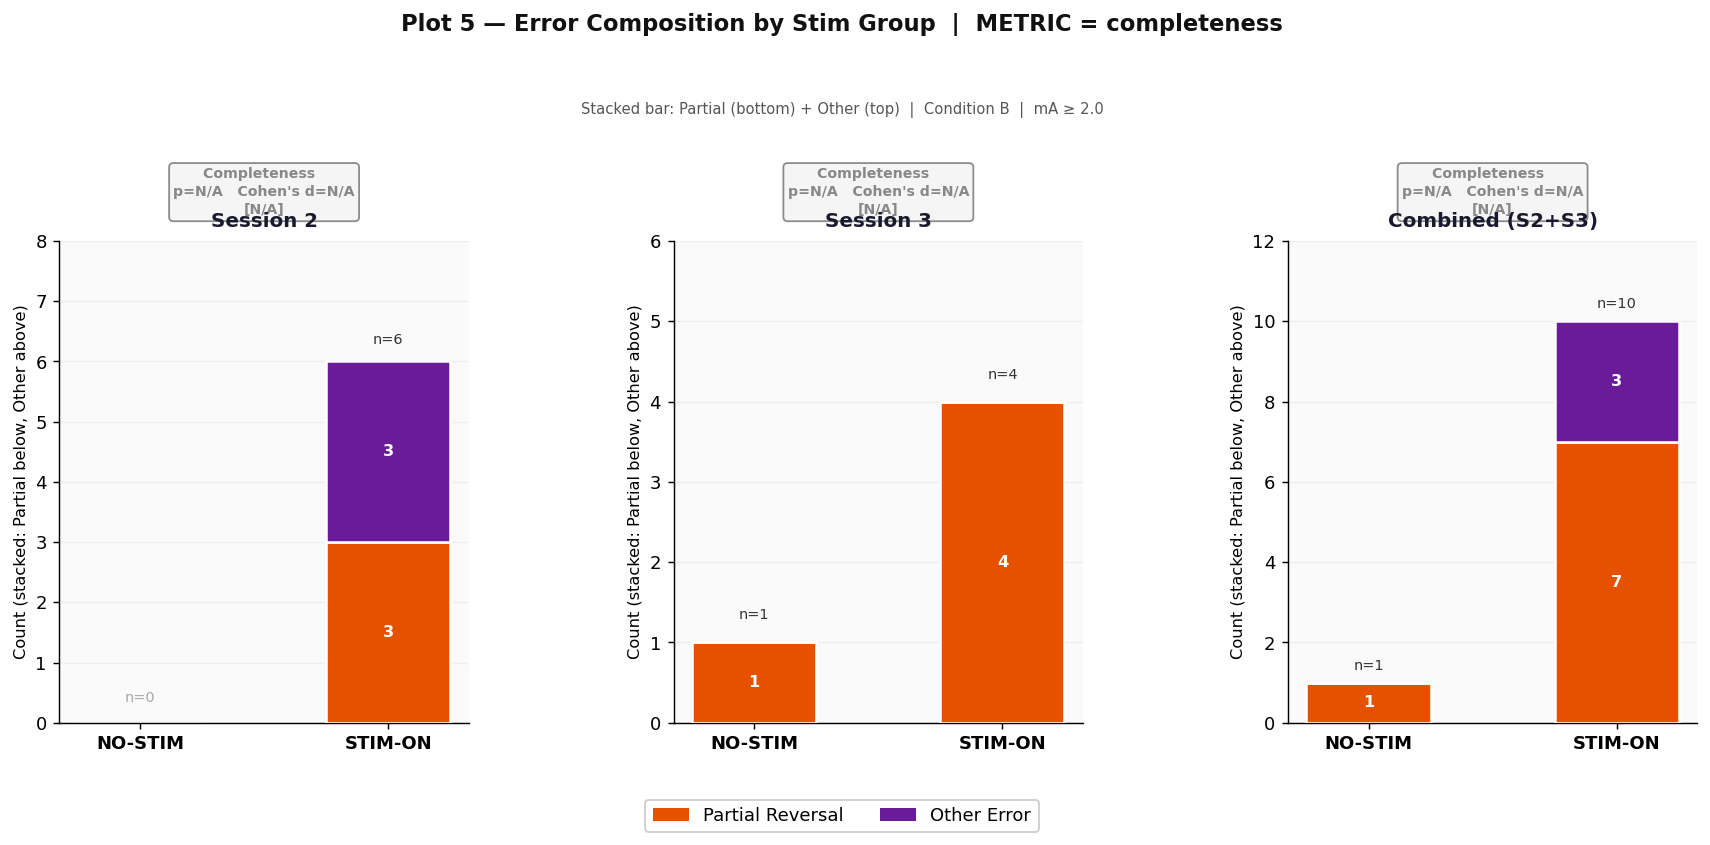

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plot5_composition_completeness.png


In [217]:
# ── Cell: Plot 5 — Stacked error composition (with metric badge) ───────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6.5), facecolor='white')
fig.subplots_adjust(wspace=0.50, top=0.72, bottom=0.15, left=0.07, right=0.97)

for ax, (sess_label, trials, n_total) in zip(axes, sessions_info):
    wrong = [t for t in trials if t['error_type'] in ('PARTIAL_REVERSAL', 'OTHER')]
    no_stim = [t for t in wrong if not t['stim_present_condB']]
    stim_on = [t for t in wrong if     t['stim_present_condB']]

    groups  = [no_stim, stim_on]
    xlabels = ['NO-STIM', 'STIM-ON']

    for xi, grp in enumerate(groups):
        n_grp     = len(grp)
        n_partial = sum(1 for t in grp if t['error_type'] == 'PARTIAL_REVERSAL')
        n_other   = sum(1 for t in grp if t['error_type'] == 'OTHER')
        if n_grp == 0:
            ax.bar(xi, 0, width=0.5, color='#eee', edgecolor='white')
            ax.text(xi, 0.3, 'n=0', ha='center', va='bottom', fontsize=8, color='#aaa')
            continue
        ax.bar(xi, n_partial, width=0.5, color=C_PARTIAL,
               edgecolor='white', linewidth=1.4, zorder=3)
        ax.bar(xi, n_other,   width=0.5, color=C_OTHER,
               edgecolor='white', linewidth=1.4, zorder=3, bottom=n_partial)

        if n_partial > 0:
            ax.text(xi, n_partial/2, f'{n_partial}',
                    ha='center', va='center', color='white',
                    fontsize=9, fontweight='bold', zorder=8)
        if n_other > 0:
            ax.text(xi, n_partial + n_other/2, f'{n_other}',
                    ha='center', va='center', color='white',
                    fontsize=9, fontweight='bold', zorder=8)
        ax.text(xi, n_grp + 0.25, f'n={n_grp}', ha='center', va='bottom',
                fontsize=8, color='#333')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(xlabels, fontsize=10, fontweight='bold')
    max_n = max(len(no_stim), len(stim_on), 1)
    ax.set_ylim(0, max_n + 2)
    ax.set_ylabel('Count (stacked: Partial below, Other above)', fontsize=9)
    ax.yaxis.grid(True, color='#eeeeee', zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    ax.set_title(sess_label, fontsize=11, fontweight='bold', color='#1A1A2E', pad=8)

    # Metric — test the 2×2 stim × error table
    res = run_metric(no_stim, stim_on, 'PARTIAL_REVERSAL',
                     paired_rates_off=paired_partial[0] if sess_label.startswith('Combined') else None,
                     paired_rates_on =paired_partial[1] if sess_label.startswith('Combined') else None)
    draw_stat_box(ax, res, x=0.5, y=1.05, fontsize=7.8)

fig.suptitle(wrap_title(f'Plot 5 — Error Composition by Stim Group  |  METRIC = {METRIC}', width=100),
             fontsize=12.5, fontweight='bold', color='#111', y=0.99)
fig.text(0.5, 0.87,
         wrap_title(f'Stacked bar: Partial (bottom) + Other (top)  |  Condition B  |  mA ≥ 2.0', width=110),
         ha='center', fontsize=8.2, color='#555')
fig.legend(handles=[mpatches.Patch(facecolor=C_PARTIAL, label='Partial Reversal'),
                    mpatches.Patch(facecolor=C_OTHER,   label='Other Error')],
           loc='lower center', ncol=2, fontsize=10, framealpha=0.97,
           facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))
save_fig(fig, COMBINED_DIR / f'plot5_composition_{METRIC}.png')


## Plot 6 — All 4 Combinations: Partial × Other × Stim-OFF × Stim-ON

Four bars per panel, two metric badges (one for Partial, one for Other)
so you can read both contrasts at a glance.


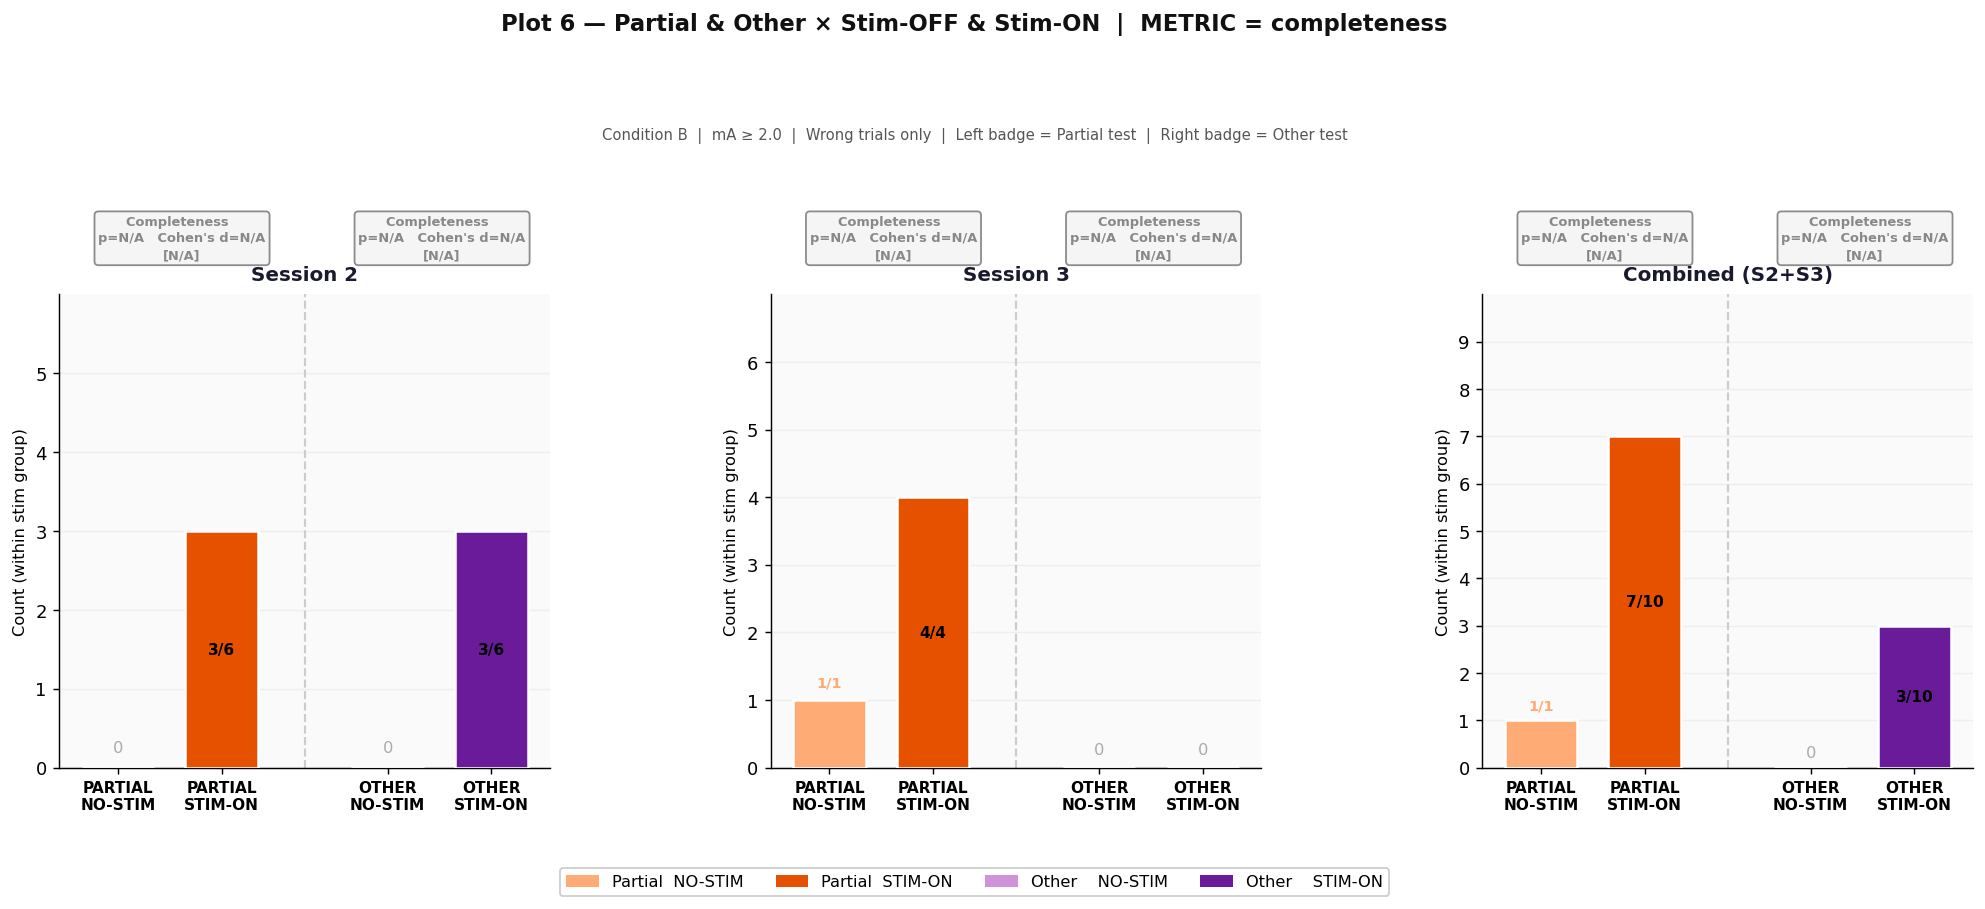

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plot6_all4_completeness.png


In [218]:
# ── Cell: Plot 6 — 4-combo view with two metric badges per panel ───────────
X_POS    = [0, 1, 2.6, 3.6]
XLABELS  = ['PARTIAL\nNO-STIM', 'PARTIAL\nSTIM-ON',
            'OTHER\nNO-STIM',   'OTHER\nSTIM-ON']
COLORS   = [C_P_NO, C_P_ON, C_O_NO, C_O_ON]
PAIR_ERR = ['PARTIAL_REVERSAL', 'PARTIAL_REVERSAL', 'OTHER', 'OTHER']
PAIR_STM = [False, True, False, True]

fig, axes = plt.subplots(1, 3, figsize=(16, 7), facecolor='white')
fig.subplots_adjust(wspace=0.45, top=0.68, bottom=0.16, left=0.06, right=0.98)

for ax, (sess_label, trials, n_total) in zip(axes, sessions_info):
    wrong = [t for t in trials if t['error_type'] in ('PARTIAL_REVERSAL', 'OTHER')]
    no_stim = [t for t in wrong if not t['stim_present_condB']]
    stim_on = [t for t in wrong if     t['stim_present_condB']]
    denom = {False: len(no_stim), True: len(stim_on)}

    pool = {
        ('PARTIAL_REVERSAL', False): [t for t in no_stim if t['error_type'] == 'PARTIAL_REVERSAL'],
        ('PARTIAL_REVERSAL', True ): [t for t in stim_on if t['error_type'] == 'PARTIAL_REVERSAL'],
        ('OTHER',            False): [t for t in no_stim if t['error_type'] == 'OTHER'],
        ('OTHER',            True ): [t for t in stim_on if t['error_type'] == 'OTHER'],
    }
    vals = [len(pool[(et, s)]) for et, s in zip(PAIR_ERR, PAIR_STM)]

    ax.bar(X_POS, vals, width=0.7, color=COLORS,
           edgecolor='white', linewidth=1.4, zorder=3)
    for xi, (v, et, stim_b, col) in enumerate(zip(vals, PAIR_ERR, PAIR_STM, COLORS)):
        tot = denom[stim_b]
        lbl = f'{v}/{tot}' if tot > 0 else '0'
        if v >= 2:
            ax.text(X_POS[xi], v/2, lbl, ha='center', va='center',
                    fontsize=8.5, fontweight='bold', color='black', zorder=8)
        elif v > 0:
            ax.text(X_POS[xi], v + 0.15, lbl, ha='center', va='bottom',
                    fontsize=8, fontweight='bold', color=col)
        else:
            ax.text(X_POS[xi], 0.15, '0', ha='center', va='bottom',
                    fontsize=9, color='#aaa')

    # ── Two metric badges — Partial (left pair) and Other (right pair) ───────
    is_combined = sess_label.startswith('Combined')
    res_p = run_metric(no_stim, stim_on, 'PARTIAL_REVERSAL',
                       paired_rates_off=paired_partial[0] if is_combined else None,
                       paired_rates_on =paired_partial[1] if is_combined else None)
    res_o = run_metric(no_stim, stim_on, 'OTHER',
                       paired_rates_off=paired_other[0] if is_combined else None,
                       paired_rates_on =paired_other[1] if is_combined else None)
    draw_stat_box(ax, res_p, x=0.25, y=1.07, fontsize=7.2)
    draw_stat_box(ax, res_o, x=0.78, y=1.07, fontsize=7.2)

    ax.axvline(x=1.8, color='#cccccc', linewidth=1.2, linestyle='--', zorder=1)
    ax.set_xticks(X_POS)
    ax.set_xticklabels(XLABELS, fontsize=8.5, fontweight='bold')
    max_y = max(max(vals) + 1, 4)
    ax.set_ylim(0, max_y + 2)
    ax.set_yticks(range(0, max_y + 2))
    ax.set_ylabel('Count (within stim group)', fontsize=9)
    ax.yaxis.grid(True, color='#eeeeee', zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    ax.set_title(sess_label, fontsize=11, fontweight='bold', color='#1A1A2E', pad=8)

fig.suptitle(wrap_title(f'Plot 6 — Partial & Other × Stim-OFF & Stim-ON  |  METRIC = {METRIC}', width=100),
             fontsize=12.5, fontweight='bold', color='#111', y=0.99)
fig.text(0.5, 0.85,
         wrap_title('Condition B  |  mA ≥ 2.0  |  Wrong trials only  |  '
                    'Left badge = Partial test  |  Right badge = Other test', width=110),
         ha='center', fontsize=8.2, color='#555')
fig.legend(handles=[mpatches.Patch(facecolor=C_P_NO, label='Partial  NO-STIM'),
                    mpatches.Patch(facecolor=C_P_ON, label='Partial  STIM-ON'),
                    mpatches.Patch(facecolor=C_O_NO, label='Other    NO-STIM'),
                    mpatches.Patch(facecolor=C_O_ON, label='Other    STIM-ON')],
           loc='lower center', ncol=4, fontsize=9, framealpha=0.97,
           facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))
save_fig(fig, COMBINED_DIR / f'plot6_all4_{METRIC}.png')


## Plot 7 — Error Types × Stim Group × Difficulty

2 rows (Easy = 2+3 digits, Hard = 4+5 digits) × 3 columns (S2, S3, Combined).
Two metric badges per panel, same structure as Plot 6 but sub-selected by
difficulty. **Heads up:** with the default Easy = {2,3} / Hard = {4,5} split,
Hard trials in Session 3 can be empty — in that case the panel shows n=0 and
the badge reports N/A gracefully.


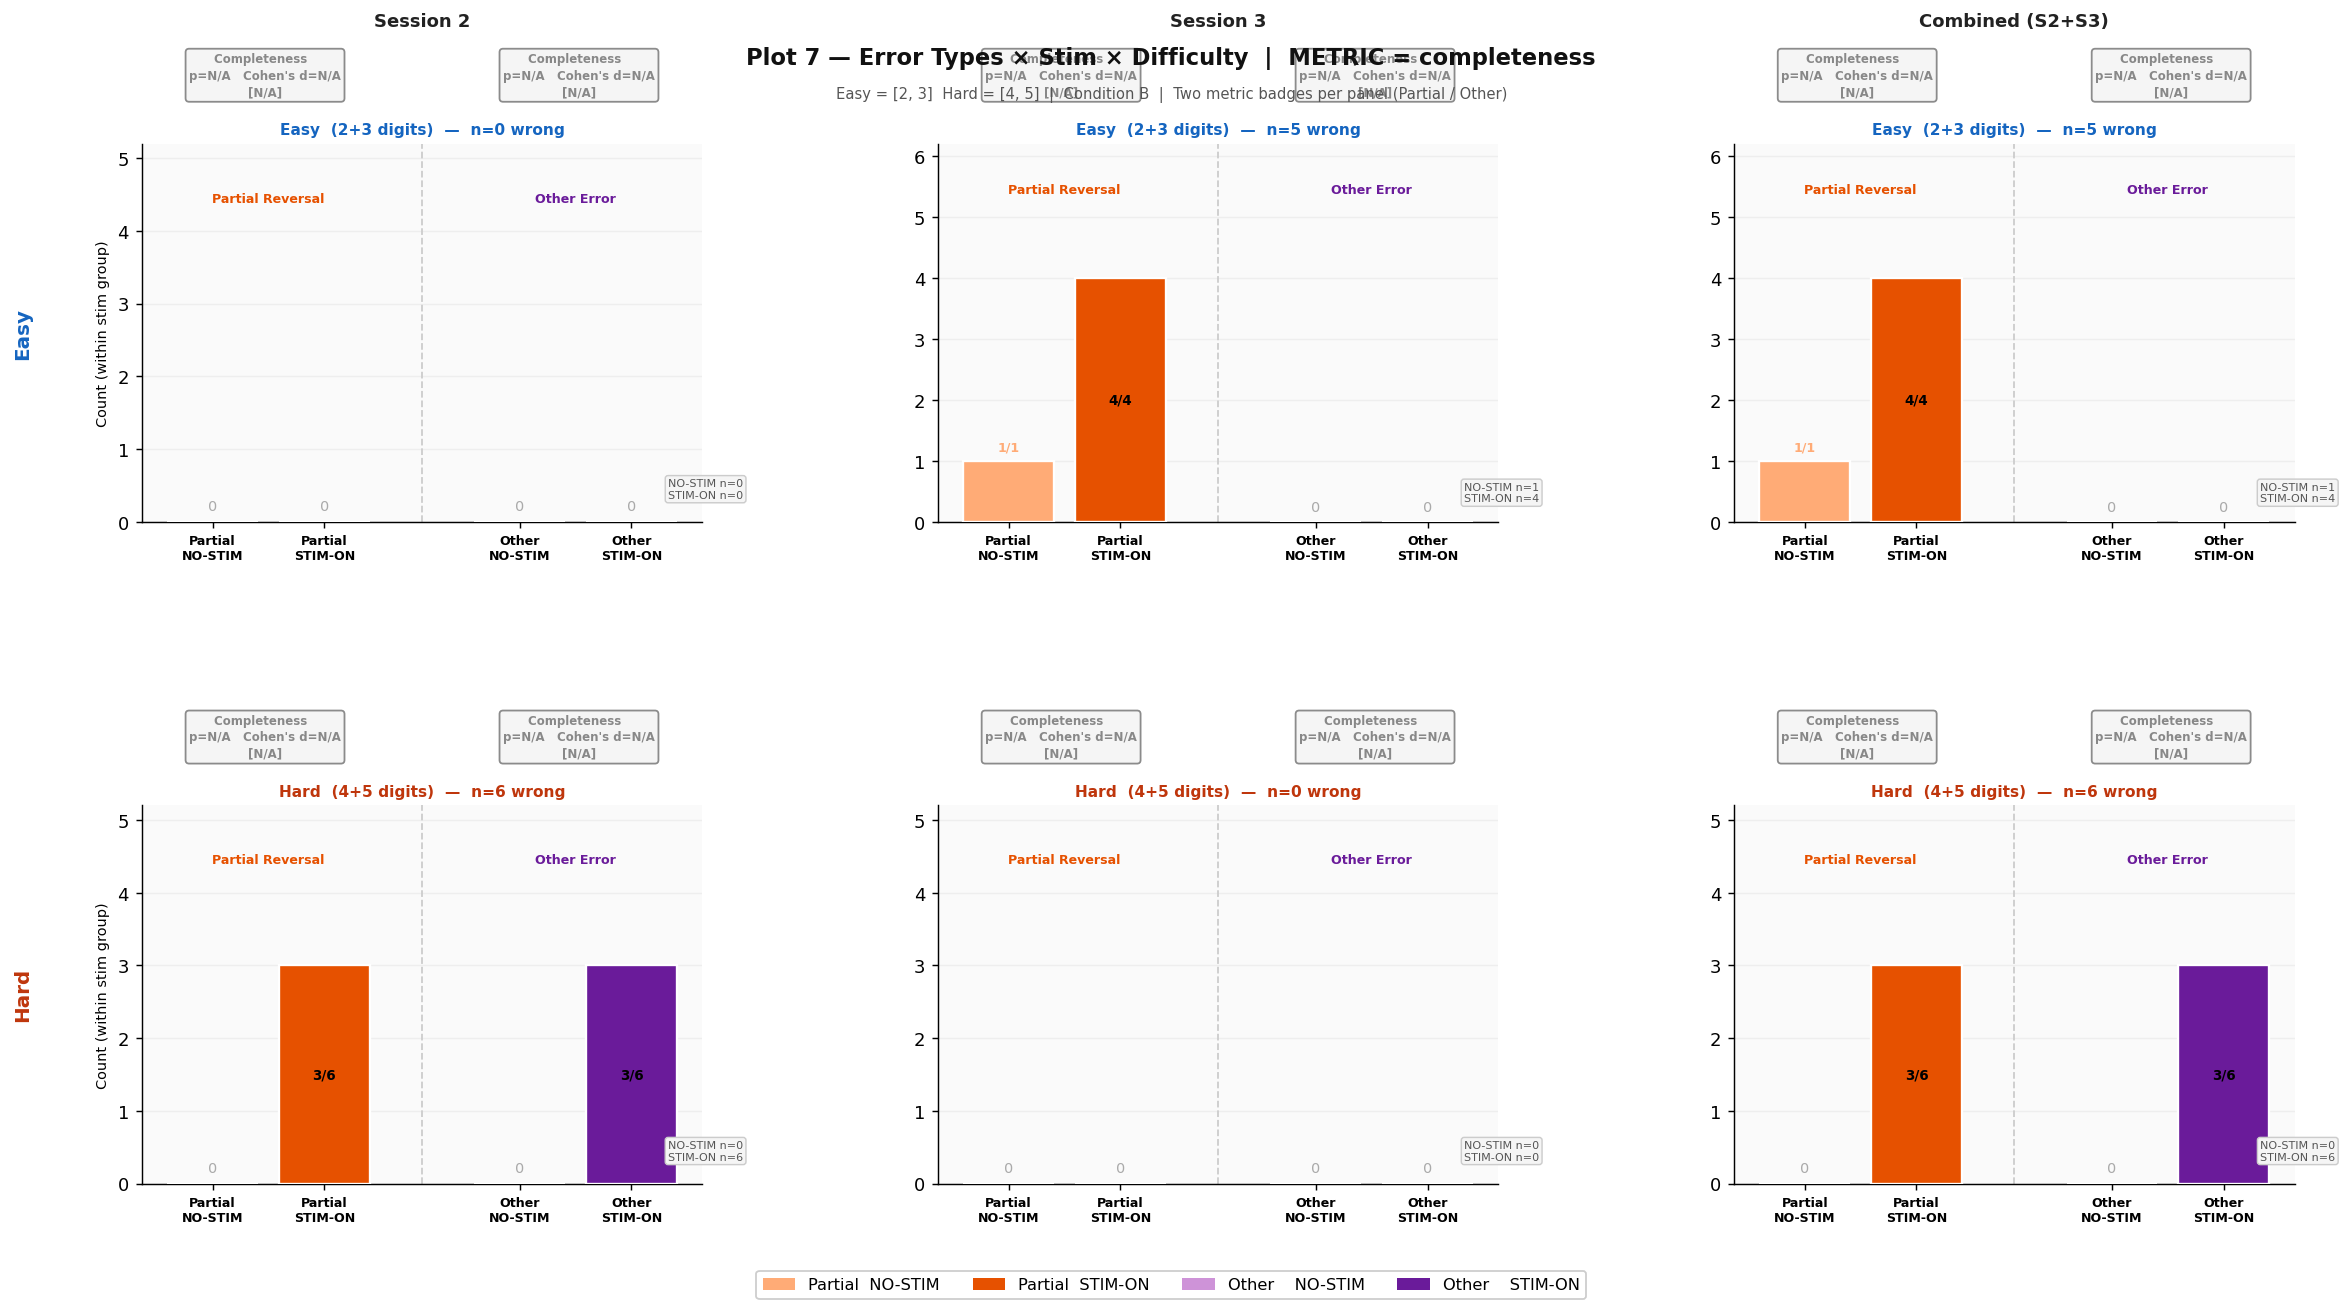

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plot7_diff_split_grid_completeness.png


In [219]:
# ── Cell: Plot 7 — Difficulty split grid (2 rows × 3 cols) ─────────────────
EASY_SET = {2, 3}
HARD_SET = {4, 5}

BAR_COLORS_7 = [C_P_NO, C_P_ON, C_O_NO, C_O_ON]
BAR_LABELS_7 = ['Partial\nNO-STIM', 'Partial\nSTIM-ON',
                'Other\nNO-STIM',   'Other\nSTIM-ON']
PAIR_ERRS_7  = ['PARTIAL_REVERSAL', 'PARTIAL_REVERSAL', 'OTHER', 'OTHER']
PAIR_STIMS_7 = [False, True, False, True]
X_POS_7      = [0, 0.8, 2.2, 3.0]


def plot_diff_panel(ax, wrong_trials, diff_label, diff_color, show_ylabel=True):
    no_stim = [t for t in wrong_trials if not t['stim_present_condB']]
    stim_on = [t for t in wrong_trials if     t['stim_present_condB']]
    denom   = {False: len(no_stim), True: len(stim_on)}
    pool = {
        ('PARTIAL_REVERSAL', False): [t for t in no_stim if t['error_type'] == 'PARTIAL_REVERSAL'],
        ('PARTIAL_REVERSAL', True ): [t for t in stim_on if t['error_type'] == 'PARTIAL_REVERSAL'],
        ('OTHER',            False): [t for t in no_stim if t['error_type'] == 'OTHER'],
        ('OTHER',            True ): [t for t in stim_on if t['error_type'] == 'OTHER'],
    }
    vals  = [len(pool[(et, s)]) for et, s in zip(PAIR_ERRS_7, PAIR_STIMS_7)]
    max_y = max(max(vals) + 1, 4)

    ax.bar(X_POS_7, vals, width=0.65, color=BAR_COLORS_7,
           edgecolor='white', linewidth=1.3, zorder=3)
    for xi, (v, et, stim_b, col) in enumerate(zip(vals, PAIR_ERRS_7, PAIR_STIMS_7, BAR_COLORS_7)):
        tot = denom[stim_b]
        lbl = f'{v}/{tot}' if tot > 0 else '0'
        if v >= 2:
            ax.text(X_POS_7[xi], v/2, lbl, ha='center', va='center',
                    fontsize=7.5, fontweight='bold', color='black', zorder=8)
        elif v == 1:
            ax.text(X_POS_7[xi], v + 0.12, lbl, ha='center', va='bottom',
                    fontsize=7, fontweight='bold', color=col)
        else:
            ax.text(X_POS_7[xi], 0.12, '0', ha='center', va='bottom',
                    fontsize=8, color='#aaa')

    ax.axvline(x=1.5, color='#cccccc', linewidth=1.0, linestyle='--', zorder=1)
    ax.text(0.4,  max_y + 0.45, 'Partial Reversal',
            ha='center', va='center', fontsize=7,
            color=C_P_ON, fontweight='bold')
    ax.text(2.6, max_y + 0.45, 'Other Error',
            ha='center', va='center', fontsize=7,
            color=C_O_ON, fontweight='bold')

    # Metric badges — Partial & Other side by side
    res_p = run_metric(no_stim, stim_on, 'PARTIAL_REVERSAL')
    res_o = run_metric(no_stim, stim_on, 'OTHER')
    draw_stat_box(ax, res_p, x=0.22, y=1.12, fontsize=6.5)
    draw_stat_box(ax, res_o, x=0.78, y=1.12, fontsize=6.5)

    ax.text(3.8, 0.3,
            f'NO-STIM n={len(no_stim)}\nSTIM-ON n={len(stim_on)}',
            ha='right', va='bottom', fontsize=6.2, color='#555',
            bbox=dict(boxstyle='round,pad=0.25', fc='#F5F5F5', ec='#ccc', lw=0.8))

    ax.set_xticks(X_POS_7)
    ax.set_xticklabels(BAR_LABELS_7, fontsize=7, fontweight='bold')
    ax.set_ylim(0, max_y + 1.2)
    ax.set_yticks(range(0, max_y + 2))
    if show_ylabel:
        ax.set_ylabel('Count (within stim group)', fontsize=8)
    ax.yaxis.grid(True, color='#eeeeee', zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')

    diff_str = '+'.join(str(d) for d in sorted(EASY_SET if diff_label == 'Easy' else HARD_SET))
    ax.set_title(f'{diff_label}  ({diff_str} digits)  —  n={len(wrong_trials)} wrong',
                 fontsize=8.5, fontweight='bold', color=diff_color, pad=5)


def plot_difficulty_split_grid(trials_s2, trials_s3, trials_combined, fname):
    scope_data   = [trials_s2, trials_s3, trials_combined]
    scope_labels = ['Session 2', 'Session 3', 'Combined (S2+S3)']
    diff_sets    = [EASY_SET, HARD_SET]
    diff_labels  = ['Easy', 'Hard']
    diff_colors  = ['#1565C0', '#BF360C']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='white')
    fig.subplots_adjust(wspace=0.42, hspace=0.75,
                        top=0.90, bottom=0.10, left=0.06, right=0.98)

    for row, (diff_label, diff_set, diff_color) in enumerate(
            zip(diff_labels, diff_sets, diff_colors)):
        for col, (trials, scope_label) in enumerate(
                zip(scope_data, scope_labels)):
            ax = axes[row, col]
            wrong = [t for t in trials
                     if t['error_type'] in ('PARTIAL_REVERSAL', 'OTHER')
                     and t['digits'] in diff_set]
            show_ylabel = (col == 0)
            plot_diff_panel(ax, wrong, diff_label, diff_color, show_ylabel=show_ylabel)
            if row == 0:
                ax.text(0.5, 1.30, scope_label,
                        transform=ax.transAxes, ha='center', va='bottom',
                        fontsize=10, fontweight='bold', color='#222')

    for row, (diff_label, diff_color) in enumerate(zip(diff_labels, diff_colors)):
        fig.text(0.005,
                 axes[row, 0].get_position().y0 +
                 axes[row, 0].get_position().height / 2,
                 diff_label, ha='left', va='center',
                 fontsize=11, fontweight='bold', color=diff_color,
                 rotation=90)

    fig.suptitle(wrap_title(f'Plot 7 — Error Types × Stim × Difficulty  |  METRIC = {METRIC}', width=100),
                 fontsize=12.5, fontweight='bold', color='#111', y=0.975)
    fig.text(0.5, 0.935,
             wrap_title(f'Easy = {sorted(EASY_SET)}  Hard = {sorted(HARD_SET)}  |  Condition B  |  '
                        f'Two metric badges per panel (Partial / Other)', width=110),
             ha='center', fontsize=8.2, color='#555')

    fig.legend(handles=[mpatches.Patch(facecolor=C_P_NO, label='Partial  NO-STIM'),
                        mpatches.Patch(facecolor=C_P_ON, label='Partial  STIM-ON'),
                        mpatches.Patch(facecolor=C_O_NO, label='Other    NO-STIM'),
                        mpatches.Patch(facecolor=C_O_ON, label='Other    STIM-ON')],
               loc='lower center', ncol=4, fontsize=9, framealpha=0.97,
               facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.005))
    save_fig(fig, COMBINED_DIR / fname)


plot_difficulty_split_grid(all_s2, all_s3, all_combined,
                           f'plot7_diff_split_grid_{METRIC}.png')


## Plot 8 — **NEW** — Reversal Completeness Score (RCS) distributions

RCS is a single continuous number per trial, so we can plot every trial as a
dot and see the full distribution rather than a summary count. The strip plot
below shows:

- Each dot = one trial's RCS
- A horizontal tick at the mean
- A metric badge testing **Stim-OFF vs Stim-ON RCS** using the selected `METRIC`

For `completeness` the metric is computed on RCS directly; for `fisher` / `chi2`
RCS is dichotomised at 0.5 (a quick "good reversal attempt yes/no" rate);
`wilcoxon` / `rm_anova` use the paired per-session mean RCS.


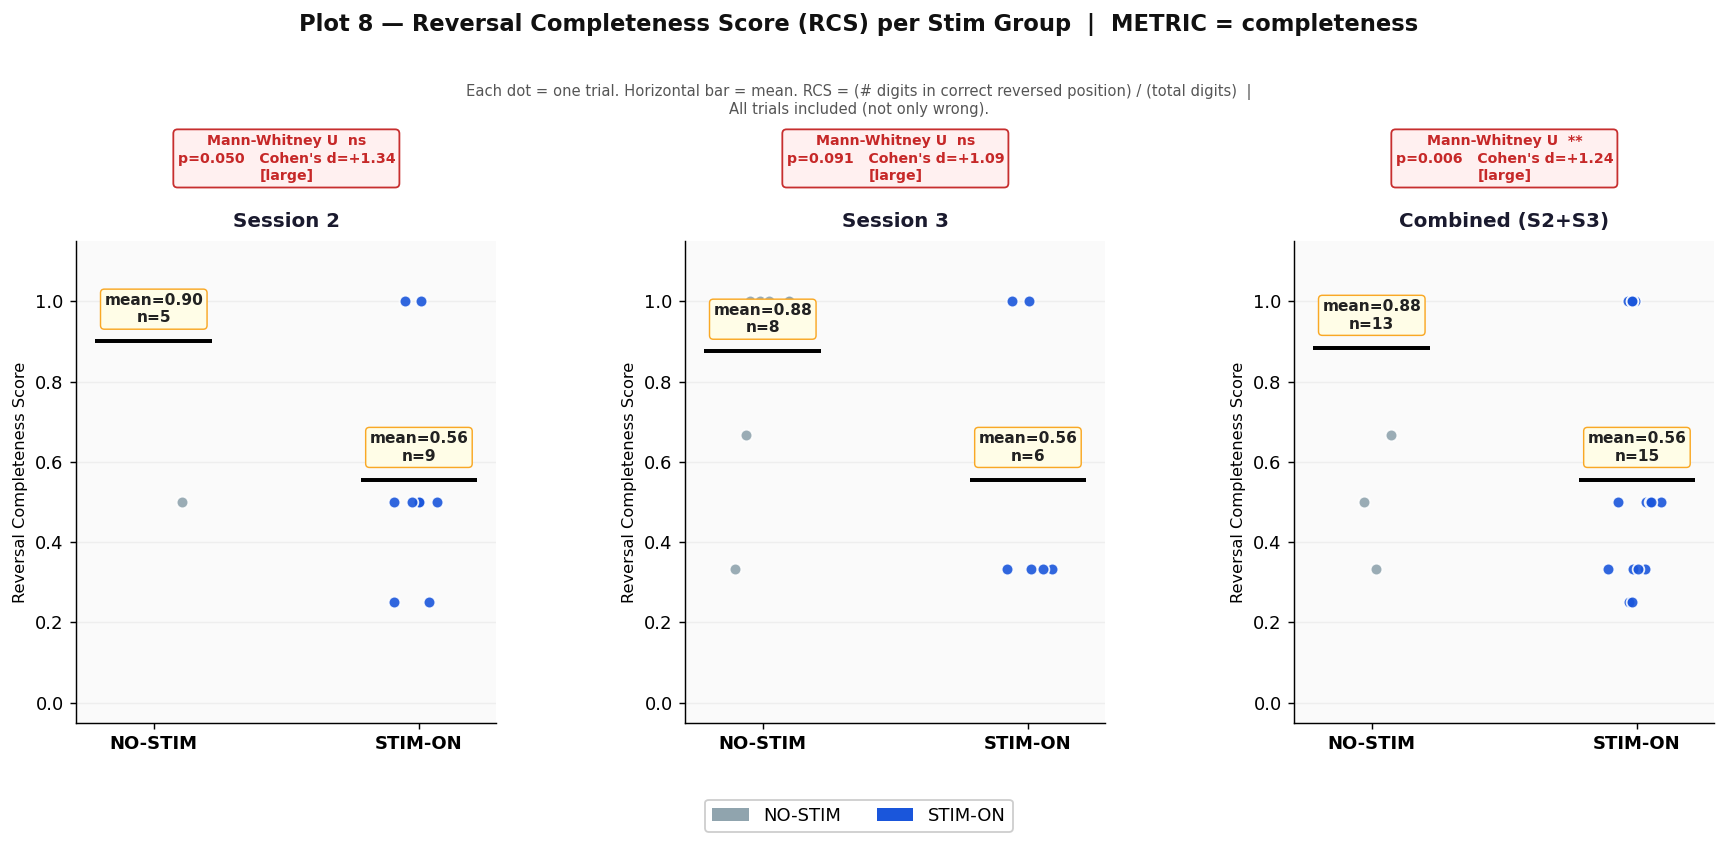

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plot8_rcs_stripplot_completeness.png


In [220]:
# ── Cell: Plot 8 — RCS strip plot per stim group (includes correct trials) ──
def paired_mean_rcs(scope='both'):
    """Return (list_off, list_on) of per-session *mean* RCS values."""
    off_means, on_means = [], []
    for sess_label, trials, _ in [('Session 2', all_s2, 14),
                                   ('Session 3', all_s3, 14)]:
        pool = trials if scope == 'all' else [t for t in trials
                                              if t['error_type'] in ('PARTIAL_REVERSAL',
                                                                      'OTHER', 'CORRECT')]
        off = [t['rcs'] for t in pool if not t['stim_present_condB']]
        on_ = [t['rcs'] for t in pool if     t['stim_present_condB']]
        off_means.append(np.mean(off) if off else np.nan)
        on_means.append(np.mean(on_)  if on_ else np.nan)
    return off_means, on_means


def _rcs_badge(off_trials, on_trials, is_combined):
    """Return a run_metric-style dict tailored for RCS display."""
    # For fisher/chi2 we need a binary; threshold RCS at 0.5 (good reversal yes/no)
    # and attach a synthetic error_type for dispatch.
    def _binarise(ts):
        out = []
        for t in ts:
            t2 = dict(t)
            t2['error_type'] = 'HIGH_RCS' if t['rcs'] >= 0.5 else 'LOW_RCS'
            out.append(t2)
        return out

    if METRIC in ('fisher', 'chi2'):
        binned_off = _binarise(off_trials)
        binned_on  = _binarise(on_trials)
        res = run_metric(binned_off, binned_on, 'HIGH_RCS')
        res['note'] = 'RCS dichotomised at 0.5 for this metric'
        return res

    if METRIC in ('wilcoxon', 'rm_anova'):
        poff, pon = paired_mean_rcs()
        # Reuse run_metric with a dummy target; the paired rates drive the test.
        res = run_metric([], [], 'DUMMY',
                         paired_rates_off=poff, paired_rates_on=pon)
        # patch display
        res['pct_off'] = 100 * np.nanmean(poff) if any(~np.isnan(poff)) else np.nan
        res['pct_on']  = 100 * np.nanmean(pon)  if any(~np.isnan(pon))  else np.nan
        return res

    # completeness — direct t-test / Mann-Whitney on RCS
    return run_metric(off_trials, on_trials, '__RCS__')  # target ignored inside completeness


# Override run_metric behaviour for '__RCS__' target by a tiny patch:
_orig_run_metric = run_metric
def run_metric_rcs_aware(no_stim_trials, stim_on_trials, target_error,
                         paired_rates_off=None, paired_rates_on=None, metric=None):
    m = metric if metric is not None else METRIC
    if target_error == '__RCS__' and m == 'completeness':
        rcs_off = np.array([t['rcs'] for t in no_stim_trials], float)
        rcs_on  = np.array([t['rcs'] for t in stim_on_trials], float)
        result = dict(metric=m, p_value=np.nan, stat=np.nan, effect=np.nan,
                      effect_label='N/A', stars='', n_off=len(rcs_off), n_on=len(rcs_on),
                      pct_off=100*np.mean(rcs_off) if len(rcs_off) else np.nan,
                      pct_on =100*np.mean(rcs_on)  if len(rcs_on)  else np.nan,
                      count_off=np.mean(rcs_off) if len(rcs_off) else np.nan,
                      count_on =np.mean(rcs_on)  if len(rcs_on)  else np.nan,
                      stat_name='', effect_name="Cohen's d", note='')
        if len(rcs_off) >= 2 and len(rcs_on) >= 2:
            try:
                _, p_n1 = stats.shapiro(rcs_off); _, p_n2 = stats.shapiro(rcs_on)
                use_param = min(p_n1, p_n2) >= 0.05
            except Exception:
                use_param = False
            if use_param:
                t_stat, p = stats.ttest_ind(rcs_off, rcs_on, equal_var=False)
                result['stat'] = float(t_stat); result['p_value'] = float(p); result['stat_name'] = "Welch's t"
            else:
                u, p = stats.mannwhitneyu(rcs_off, rcs_on, alternative='two-sided')
                result['stat'] = float(u); result['p_value'] = float(p); result['stat_name'] = 'Mann-Whitney U'
            result['effect'] = cohens_d(rcs_off, rcs_on)
            result['effect_label'] = effect_label(result['effect'])
        result['stars'] = sig_stars(result['p_value'])
        return result
    return _orig_run_metric(no_stim_trials, stim_on_trials, target_error,
                            paired_rates_off, paired_rates_on, metric)

run_metric = run_metric_rcs_aware


# Now the actual plot
fig, axes = plt.subplots(1, 3, figsize=(14, 6.5), facecolor='white')
fig.subplots_adjust(wspace=0.45, top=0.72, bottom=0.15, left=0.07, right=0.97)

np.random.seed(7)
for ax, (sess_label, trials, n_total) in zip(axes, sessions_info):
    off = [t for t in trials if not t['stim_present_condB']]
    on_ = [t for t in trials if     t['stim_present_condB']]

    for xi, (grp, color, xlab) in enumerate([(off, C_NO_STIM, 'NO-STIM'),
                                              (on_, C_STIM,    'STIM-ON')]):
        vals = [t['rcs'] for t in grp]
        if not vals:
            ax.text(xi, 0.5, 'n=0', ha='center', va='center',
                    fontsize=9, color='#aaa')
            continue
        x_jit = xi + (np.random.rand(len(vals)) - 0.5) * 0.22
        ax.scatter(x_jit, vals, s=42, color=color,
                   edgecolor='white', linewidth=1.0, alpha=0.9, zorder=3)
        m = np.mean(vals)
        ax.hlines(m, xi - 0.22, xi + 0.22, colors='black', linewidth=2.2, zorder=5)
        ax.text(xi, m + 0.04, f'mean={m:.2f}\nn={len(vals)}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold',
                color='#222',
                bbox=dict(boxstyle='round,pad=0.25', fc='#FFFDE7', ec='#F9A825', lw=0.8))

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['NO-STIM', 'STIM-ON'], fontsize=10, fontweight='bold')
    ax.set_ylim(-0.05, 1.15)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_ylabel('Reversal Completeness Score', fontsize=9)
    ax.yaxis.grid(True, color='#eeeeee', zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    ax.set_title(sess_label, fontsize=11, fontweight='bold', color='#1A1A2E', pad=8)

    res = _rcs_badge(off, on_, sess_label.startswith('Combined'))
    draw_stat_box(ax, res, x=0.5, y=1.12, fontsize=7.8)

fig.suptitle(wrap_title(f'Plot 8 — Reversal Completeness Score (RCS) per Stim Group  |  METRIC = {METRIC}',
                        width=100),
             fontsize=12.5, fontweight='bold', color='#111', y=0.99)
fig.text(0.5, 0.87,
         wrap_title('Each dot = one trial. Horizontal bar = mean. '
                    'RCS = (# digits in correct reversed position) / (total digits)  |  '
                    'All trials included (not only wrong).',
                    width=110),
         ha='center', fontsize=8.2, color='#555')
fig.legend(handles=[mpatches.Patch(facecolor=C_NO_STIM, label='NO-STIM'),
                    mpatches.Patch(facecolor=C_STIM,    label='STIM-ON')],
           loc='lower center', ncol=2, fontsize=10, framealpha=0.97,
           facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))
save_fig(fig, COMBINED_DIR / f'plot8_rcs_stripplot_{METRIC}.png')


In [221]:
# # ── Cell: Plot 8 — CPS strip plot per stim group (includes correct trials) ──

# # ── CPS computation (self-contained, no prerequisites) ────────────────────
# def compute_cps(recalled_positions, span_length):
#     """
#     Credit Partial Score for a single trial (digit span backward).

#     Parameters
#     ----------
#     recalled_positions : list[int]
#         1-indexed positions from the END of the sequence that were correct.
#         E.g. for span-5 with last 3 items correct: [1, 2, 3].
#     span_length : int
#         Total number of items in the sequence.

#     Returns
#     -------
#     float in [0, 1]
#     """
#     if span_length <= 0:
#         return 0.0
#     max_score = span_length * (span_length + 1) / 2
#     return sum(recalled_positions) / max_score


# def _ensure_cps(trials):
#     for t in trials:
#         presented = str(t.get('presented', ''))
#         resp      = str(t.get('resp', ''))
#         n = len(presented)
#         if n == 0:
#             t['cps'] = 0.0
#             continue
#         cresp = presented[::-1]
#         recalled_positions = []
#         for i in range(n):
#             if i < len(resp) and resp[i] == cresp[i]:
#                 recalled_positions.append(n - i)  # 1-indexed from end: last digit=1, first=n
#         t['recalled_positions'] = recalled_positions
#         t['span_length']        = n
#         t['cps']                = compute_cps(recalled_positions, n)

# # Compute CPS for all sessions right here, no external call needed
# for _sess_trials in [all_s2, all_s3]:
#     _ensure_cps(_sess_trials)


# # ── Helpers ───────────────────────────────────────────────────────────────
# def paired_mean_cps(scope='both'):
#     """Return (list_off, list_on) of per-session *mean* CPS values."""
#     off_means, on_means = [], []
#     for sess_label, trials, _ in [('Session 2', all_s2, 14),
#                                    ('Session 3', all_s3, 14)]:
#         pool = trials if scope == 'all' else [t for t in trials
#                                               if t['error_type'] in ('PARTIAL_REVERSAL',
#                                                                       'OTHER', 'CORRECT')]
#         off = [t['cps'] for t in pool if not t['stim_present_condB']]
#         on_ = [t['cps'] for t in pool if     t['stim_present_condB']]
#         off_means.append(np.mean(off) if off else np.nan)
#         on_means.append(np.mean(on_)  if on_ else np.nan)
#     return off_means, on_means


# def _cps_badge(off_trials, on_trials, is_combined):
#     """Return a run_metric-style dict tailored for CPS display."""
#     def _binarise(ts):
#         out = []
#         for t in ts:
#             t2 = dict(t)
#             t2['error_type'] = 'HIGH_CPS' if t['cps'] >= 0.5 else 'LOW_CPS'
#             out.append(t2)
#         return out

#     if METRIC in ('fisher', 'chi2'):
#         res = run_metric(_binarise(off_trials), _binarise(on_trials), 'HIGH_CPS')
#         res['note'] = 'CPS dichotomised at 0.5 for this metric'
#         return res

#     if METRIC in ('wilcoxon', 'rm_anova'):
#         poff, pon = paired_mean_cps()
#         res = run_metric([], [], 'DUMMY',
#                          paired_rates_off=poff, paired_rates_on=pon)
#         res['pct_off'] = 100 * np.nanmean(poff) if any(~np.isnan(poff)) else np.nan
#         res['pct_on']  = 100 * np.nanmean(pon)  if any(~np.isnan(pon))  else np.nan
#         return res

#     return run_metric(off_trials, on_trials, '__CPS__')


# # ── Patch run_metric to handle '__CPS__' target ───────────────────────────
# _orig_run_metric_p8 = run_metric

# def run_metric_cps_aware(no_stim_trials, stim_on_trials, target_error,
#                          paired_rates_off=None, paired_rates_on=None, metric=None):
#     m = metric if metric is not None else METRIC
#     if target_error == '__CPS__' and m == 'completeness':
#         cps_off = np.array([t['cps'] for t in no_stim_trials], float)
#         cps_on  = np.array([t['cps'] for t in stim_on_trials], float)
#         result  = dict(metric=m, p_value=np.nan, stat=np.nan, effect=np.nan,
#                        effect_label='N/A', stars='', n_off=len(cps_off), n_on=len(cps_on),
#                        pct_off =100*np.mean(cps_off) if len(cps_off) else np.nan,
#                        pct_on  =100*np.mean(cps_on)  if len(cps_on)  else np.nan,
#                        count_off=np.mean(cps_off)    if len(cps_off) else np.nan,
#                        count_on =np.mean(cps_on)     if len(cps_on)  else np.nan,
#                        stat_name='', effect_name="Cohen's d", note='')
#         if len(cps_off) >= 2 and len(cps_on) >= 2:
#             try:
#                 _, p_n1 = stats.shapiro(cps_off)
#                 _, p_n2 = stats.shapiro(cps_on)
#                 use_param = min(p_n1, p_n2) >= 0.05
#             except Exception:
#                 use_param = False
#             if use_param:
#                 t_stat, p = stats.ttest_ind(cps_off, cps_on, equal_var=False)
#                 result['stat'] = float(t_stat); result['p_value'] = float(p)
#                 result['stat_name'] = "Welch's t"
#             else:
#                 u, p = stats.mannwhitneyu(cps_off, cps_on, alternative='two-sided')
#                 result['stat'] = float(u); result['p_value'] = float(p)
#                 result['stat_name'] = 'Mann-Whitney U'
#             result['effect']       = cohens_d(cps_off, cps_on)
#             result['effect_label'] = effect_label(result['effect'])
#         result['stars'] = sig_stars(result['p_value'])
#         return result
#     return _orig_run_metric_p8(no_stim_trials, stim_on_trials, target_error,
#                                paired_rates_off, paired_rates_on, metric)

# run_metric = run_metric_cps_aware


# # ── Plot ──────────────────────────────────────────────────────────────────
# fig, axes = plt.subplots(1, 3, figsize=(14, 6.5), facecolor='white')
# fig.subplots_adjust(wspace=0.45, top=0.72, bottom=0.15, left=0.07, right=0.97)

# np.random.seed(7)
# for ax, (sess_label, trials, n_total) in zip(axes, sessions_info):
#     off = [t for t in trials if not t['stim_present_condB']]
#     on_ = [t for t in trials if     t['stim_present_condB']]

#     for xi, (grp, color, xlab) in enumerate([(off, C_NO_STIM, 'NO-STIM'),
#                                               (on_, C_STIM,    'STIM-ON')]):
#         vals = [t['cps'] for t in grp]
#         if not vals:
#             ax.text(xi, 0.5, 'n=0', ha='center', va='center',
#                     fontsize=9, color='#aaa')
#             continue
#         x_jit = xi + (np.random.rand(len(vals)) - 0.5) * 0.22
#         ax.scatter(x_jit, vals, s=42, color=color,
#                    edgecolor='white', linewidth=1.0, alpha=0.9, zorder=3)
#         m = np.mean(vals)
#         ax.hlines(m, xi - 0.22, xi + 0.22, colors='black', linewidth=2.2, zorder=5)
#         ax.text(xi, m + 0.04, f'mean={m:.2f}\nn={len(vals)}',
#                 ha='center', va='bottom', fontsize=8.5, fontweight='bold',
#                 color='#222',
#                 bbox=dict(boxstyle='round,pad=0.25', fc='#FFFDE7', ec='#F9A825', lw=0.8))

#     ax.set_xticks([0, 1])
#     ax.set_xticklabels(['NO-STIM', 'STIM-ON'], fontsize=10, fontweight='bold')
#     ax.set_ylim(-0.05, 1.15)
#     ax.set_yticks(np.arange(0, 1.01, 0.2))
#     ax.set_ylabel('Credit Partial Score (CPS)', fontsize=9)
#     ax.yaxis.grid(True, color='#eeeeee', zorder=0)
#     ax.set_axisbelow(True)
#     ax.set_facecolor('#FAFAFA')
#     ax.set_title(sess_label, fontsize=11, fontweight='bold', color='#1A1A2E', pad=8)

#     res = _cps_badge(off, on_, sess_label.startswith('Combined'))
#     draw_stat_box(ax, res, x=0.5, y=1.12, fontsize=7.8)

# fig.suptitle(wrap_title(f'Plot 8 — Credit Partial Score (CPS) per Stim Group  |  METRIC = {METRIC}',
#                         width=100),
#              fontsize=12.5, fontweight='bold', color='#111', y=0.99)
# fig.text(0.5, 0.87,
#          wrap_title('Each dot = one trial. Horizontal bar = mean. '
#                     'CPS = positional credit score: item recalled at position i from end '
#                     'earns weight i / [n(n+1)/2], giving scores in [0, 1].  |  '
#                     'All trials included (not only wrong).',
#                     width=110),
#          ha='center', fontsize=8.2, color='#555')
# fig.legend(handles=[mpatches.Patch(facecolor=C_NO_STIM, label='NO-STIM'),
#                     mpatches.Patch(facecolor=C_STIM,    label='STIM-ON')],
#            loc='lower center', ncol=2, fontsize=10, framealpha=0.97,
#            facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))
# save_fig(fig, COMBINED_DIR / f'plot8_cps_stripplot_{METRIC}.png')

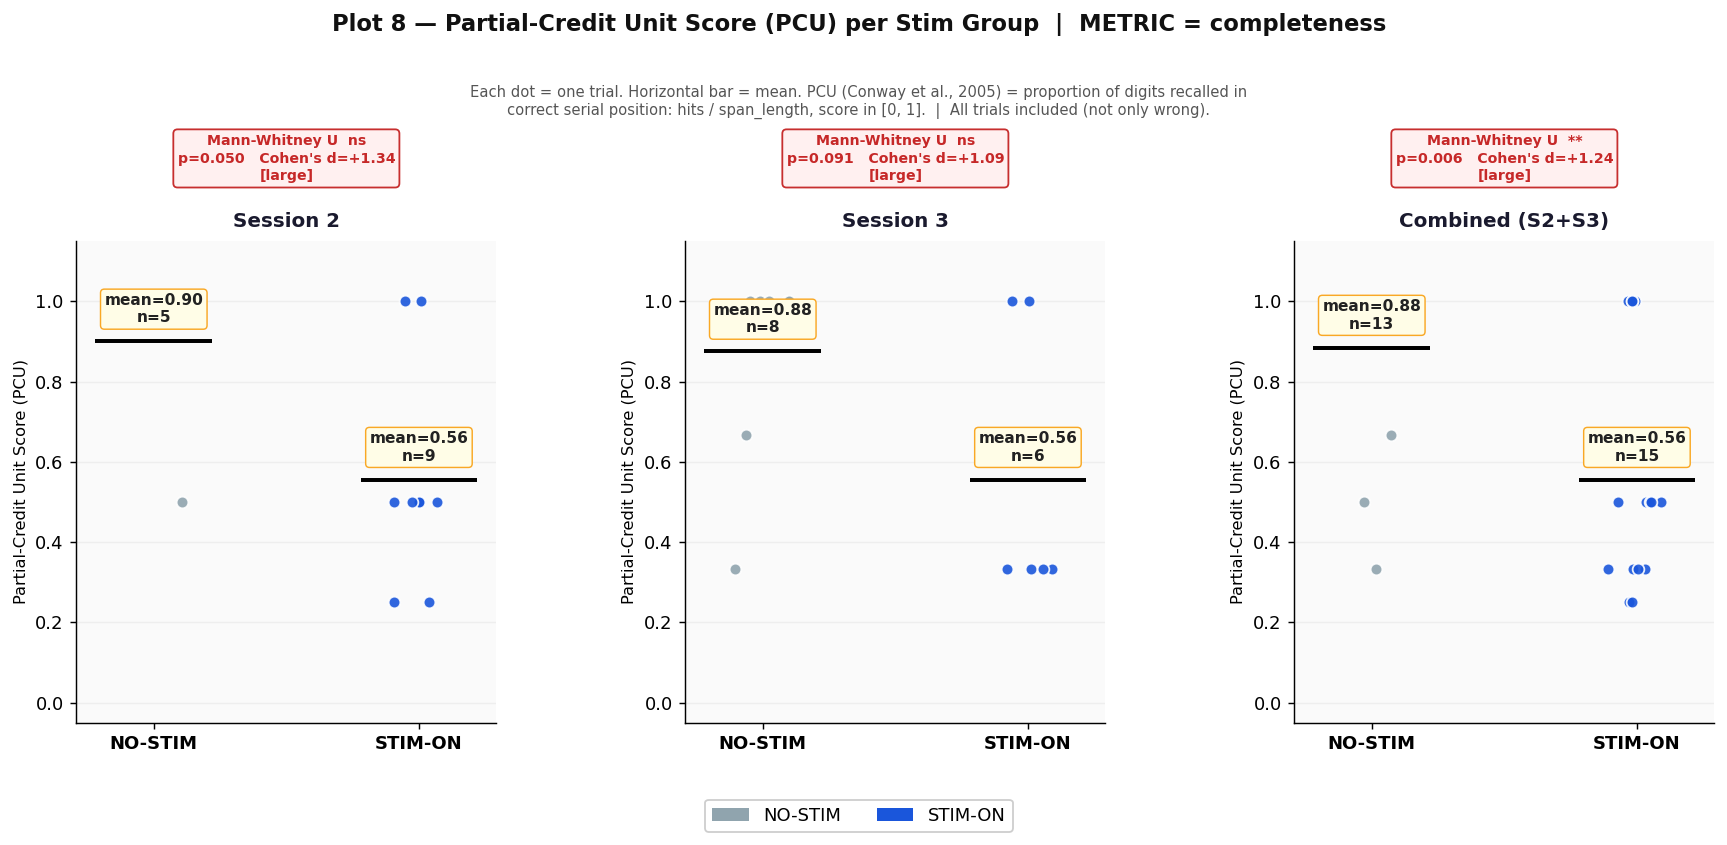

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plot8_pcu_stripplot_completeness.png


In [222]:
# ── Cell: Plot 8 — PCU (Partial-Credit Unit) strip plot per stim group ──
# PCU = Conway et al. (2005) standard: proportion of digits correct in right serial position
# Formula: hits_in_correct_position / span_length  →  score in [0, 1]
# This is identical to RCS; CPS positional weighting is replaced with equal weighting.

def compute_pcu(presented, resp):
    """
    Partial-Credit Unit scoring (Conway et al., 2005).

    Credits each digit recalled in the correct serial position equally.
    Score = number of position-correct digits / span length.

    Parameters
    ----------
    presented : str  — the digit sequence shown to the patient
    resp      : str  — the patient's backward recall response

    Returns
    -------
    float in [0, 1]
    """
    presented = str(presented).strip()
    resp      = str(resp).strip()
    n = len(presented)
    if n == 0:
        return 0.0
    cresp = presented[::-1]          # correct reversed answer
    hits  = sum(1 for i in range(n)
                if i < len(resp) and resp[i] == cresp[i])
    return hits / n


def _ensure_pcu(trials):
    """Compute and store 'pcu' on every trial dict in-place."""
    for t in trials:
        t['pcu'] = compute_pcu(t.get('presented', ''), t.get('resp', ''))

# Compute PCU for all sessions
for _sess_trials in [all_s2, all_s3]:
    _ensure_pcu(_sess_trials)


# ── Helpers ───────────────────────────────────────────────────────────────
def paired_mean_pcu():
    """Return (list_off, list_on) of per-session mean PCU values."""
    off_means, on_means = [], []
    for sess_label, trials, _ in [('Session 2', all_s2, 14),
                                   ('Session 3', all_s3, 14)]:
        off = [t['pcu'] for t in trials if not t['stim_present_condB']]
        on_ = [t['pcu'] for t in trials if     t['stim_present_condB']]
        off_means.append(np.mean(off) if off else np.nan)
        on_means.append(np.mean(on_)  if on_ else np.nan)
    return off_means, on_means


def _pcu_badge(off_trials, on_trials):
    """Return a run_metric-style dict for PCU display."""
    def _binarise(ts):
        out = []
        for t in ts:
            t2 = dict(t)
            t2['error_type'] = 'HIGH_PCU' if t['pcu'] >= 0.5 else 'LOW_PCU'
            out.append(t2)
        return out

    if METRIC in ('fisher', 'chi2'):
        res = run_metric(_binarise(off_trials), _binarise(on_trials), 'HIGH_PCU')
        res['note'] = 'PCU dichotomised at 0.5 for this metric'
        return res

    if METRIC in ('wilcoxon', 'rm_anova'):
        poff, pon = paired_mean_pcu()
        res = run_metric([], [], 'DUMMY',
                         paired_rates_off=poff, paired_rates_on=pon)
        res['pct_off'] = 100 * np.nanmean(poff) if any(~np.isnan(poff)) else np.nan
        res['pct_on']  = 100 * np.nanmean(pon)  if any(~np.isnan(pon))  else np.nan
        return res

    return run_metric(off_trials, on_trials, '__PCU__')


# ── Patch run_metric to handle '__PCU__' target ───────────────────────────
_orig_run_metric_p8 = run_metric

def run_metric_pcu_aware(no_stim_trials, stim_on_trials, target_error,
                         paired_rates_off=None, paired_rates_on=None, metric=None):
    m = metric if metric is not None else METRIC
    if target_error == '__PCU__' and m == 'completeness':
        pcu_off = np.array([t['pcu'] for t in no_stim_trials], float)
        pcu_on  = np.array([t['pcu'] for t in stim_on_trials], float)
        result  = dict(metric=m, p_value=np.nan, stat=np.nan, effect=np.nan,
                       effect_label='N/A', stars='', n_off=len(pcu_off), n_on=len(pcu_on),
                       pct_off  = 100*np.mean(pcu_off) if len(pcu_off) else np.nan,
                       pct_on   = 100*np.mean(pcu_on)  if len(pcu_on)  else np.nan,
                       count_off= np.mean(pcu_off)     if len(pcu_off) else np.nan,
                       count_on = np.mean(pcu_on)      if len(pcu_on)  else np.nan,
                       stat_name='', effect_name="Cohen's d", note='')
        if len(pcu_off) >= 2 and len(pcu_on) >= 2:
            try:
                _, p_n1 = stats.shapiro(pcu_off)
                _, p_n2 = stats.shapiro(pcu_on)
                use_param = min(p_n1, p_n2) >= 0.05
            except Exception:
                use_param = False
            if use_param:
                t_stat, p = stats.ttest_ind(pcu_off, pcu_on, equal_var=False)
                result['stat']      = float(t_stat)
                result['p_value']   = float(p)
                result['stat_name'] = "Welch's t"
            else:
                u, p = stats.mannwhitneyu(pcu_off, pcu_on, alternative='two-sided')
                result['stat']      = float(u)
                result['p_value']   = float(p)
                result['stat_name'] = 'Mann-Whitney U'
            result['effect']       = cohens_d(pcu_off, pcu_on)
            result['effect_label'] = effect_label(result['effect'])
        result['stars'] = sig_stars(result['p_value'])
        return result
    return _orig_run_metric_p8(no_stim_trials, stim_on_trials, target_error,
                               paired_rates_off, paired_rates_on, metric)

run_metric = run_metric_pcu_aware


# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6.5), facecolor='white')
fig.subplots_adjust(wspace=0.45, top=0.72, bottom=0.15, left=0.07, right=0.97)

np.random.seed(7)
for ax, (sess_label, trials, n_total) in zip(axes, sessions_info):
    off = [t for t in trials if not t['stim_present_condB']]
    on_ = [t for t in trials if     t['stim_present_condB']]

    for xi, (grp, color, xlab) in enumerate([(off, C_NO_STIM, 'NO-STIM'),
                                              (on_, C_STIM,    'STIM-ON')]):
        vals = [t['pcu'] for t in grp]
        if not vals:
            ax.text(xi, 0.5, 'n=0', ha='center', va='center',
                    fontsize=9, color='#aaa')
            continue
        x_jit = xi + (np.random.rand(len(vals)) - 0.5) * 0.22
        ax.scatter(x_jit, vals, s=42, color=color,
                   edgecolor='white', linewidth=1.0, alpha=0.9, zorder=3)
        m = np.mean(vals)
        ax.hlines(m, xi - 0.22, xi + 0.22, colors='black', linewidth=2.2, zorder=5)
        ax.text(xi, m + 0.04, f'mean={m:.2f}\nn={len(vals)}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold',
                color='#222',
                bbox=dict(boxstyle='round,pad=0.25', fc='#FFFDE7', ec='#F9A825', lw=0.8))

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['NO-STIM', 'STIM-ON'], fontsize=10, fontweight='bold')
    ax.set_ylim(-0.05, 1.15)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_ylabel('Partial-Credit Unit Score (PCU)', fontsize=9)
    ax.yaxis.grid(True, color='#eeeeee', zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    ax.set_title(sess_label, fontsize=11, fontweight='bold', color='#1A1A2E', pad=8)

    res = _pcu_badge(off, on_)
    draw_stat_box(ax, res, x=0.5, y=1.12, fontsize=7.8)

fig.suptitle(wrap_title(f'Plot 8 — Partial-Credit Unit Score (PCU) per Stim Group  |  METRIC = {METRIC}',
                        width=100),
             fontsize=12.5, fontweight='bold', color='#111', y=0.99)
fig.text(0.5, 0.87,
         wrap_title('Each dot = one trial. Horizontal bar = mean. '
                    'PCU (Conway et al., 2005) = proportion of digits recalled in correct '
                    'serial position: hits / span_length, score in [0, 1].  |  '
                    'All trials included (not only wrong).',
                    width=110),
         ha='center', fontsize=8.2, color='#555')
fig.legend(handles=[mpatches.Patch(facecolor=C_NO_STIM, label='NO-STIM'),
                    mpatches.Patch(facecolor=C_STIM,    label='STIM-ON')],
           loc='lower center', ncol=2, fontsize=10, framealpha=0.97,
           facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))
save_fig(fig, COMBINED_DIR / f'plot8_pcu_stripplot_{METRIC}.png')

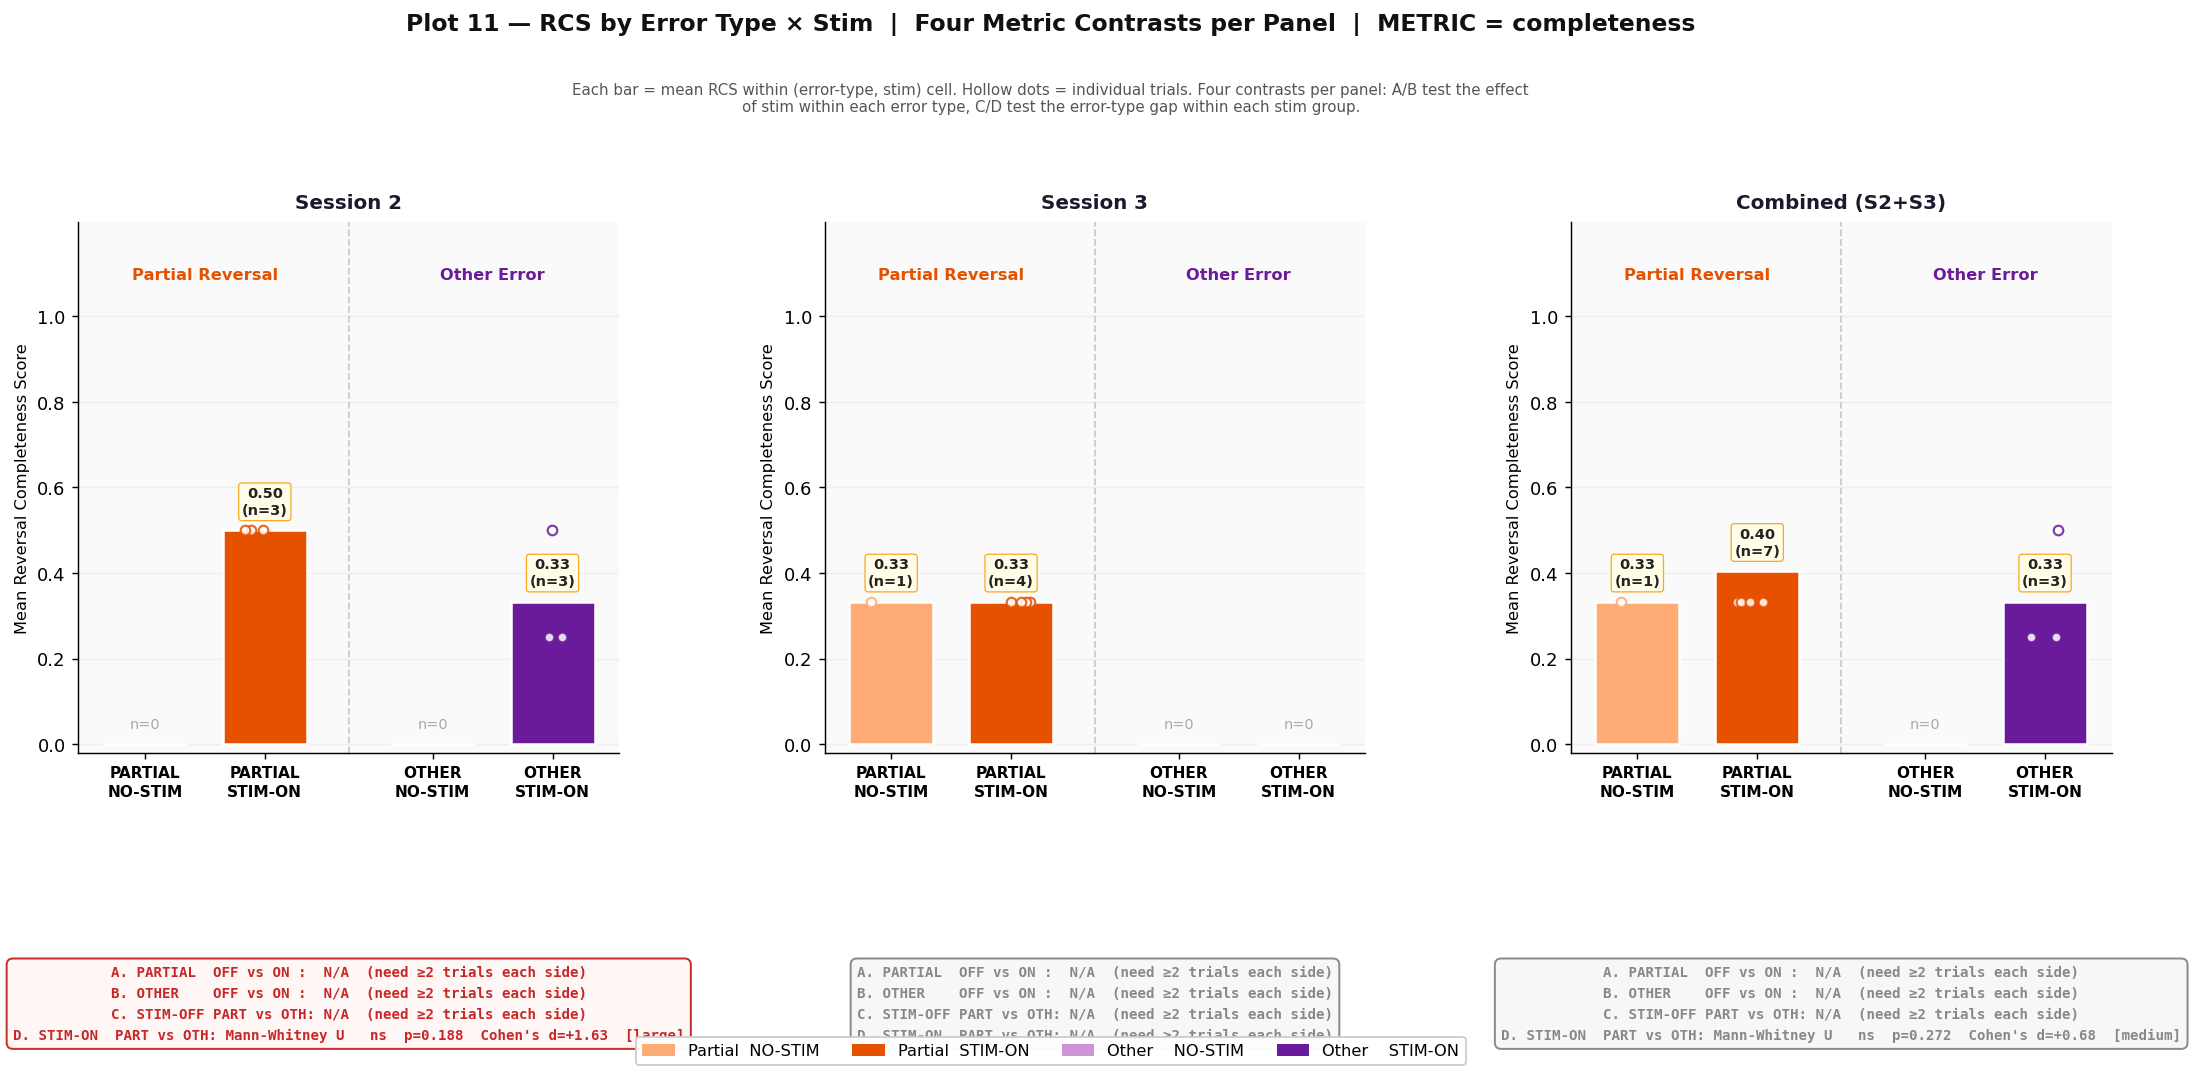

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plot11_rcs_error_x_stim_completeness.png

  Plot 11 — Four Contrasts per Scope  |  METRIC = completeness
  Scope               Contrast                        Test                    p           Effect              Sig
  -----------------------------------------------------------------------------------------------------
  Session 2           A. PARTIAL: OFF vs ON           completeness               N/A      Cohen's d=N/A           [N/A]
  Session 2           B. OTHER:   OFF vs ON           completeness               N/A      Cohen's d=N/A           [N/A]
  Session 2           C. STIM-OFF: PART vs OTHER      completeness               N/A      Cohen's d=N/A           [N/A]
  Session 2           D. STIM-ON:  PART vs OTHER      Mann-Whitney U          0.1876      Cohen's d=+1.633    ns  [large]
  Session 3           A. PARTIAL: OFF vs ON           completeness               N/A      

In [223]:
# ── Cell: Plot 11 — RCS × Error Type × Stim with 4 metric contrasts ─────────
#
# Four bars per panel (one panel per scope: S2 | S3 | Combined):
#   (1) PARTIAL  NO-STIM   (2) PARTIAL  STIM-ON
#   (3) OTHER    NO-STIM   (4) OTHER    STIM-ON
#
# Each bar's height = mean RCS of trials in that cell.
# Dots overlaid = individual trials so you can see the spread.
#
# Four metric comparisons per panel:
#   A. PARTIAL:  STIM-OFF vs STIM-ON   (effect of stim within partial-reversal trials)
#   B. OTHER:    STIM-OFF vs STIM-ON   (effect of stim within other-error trials)
#   C. STIM-OFF: PARTIAL vs OTHER      (error-type contrast when stim is off)
#   D. STIM-ON:  PARTIAL vs OTHER      (error-type contrast when stim is on)

X_POS_11    = [0, 1, 2.4, 3.4]
XLABELS_11  = ['PARTIAL\nNO-STIM', 'PARTIAL\nSTIM-ON',
               'OTHER\nNO-STIM',   'OTHER\nSTIM-ON']
COLORS_11   = [C_P_NO, C_P_ON, C_O_NO, C_O_ON]


def _rcs_contrast(trials_a, trials_b, label_a, label_b):
    """
    Run the currently-selected METRIC on two arbitrary trial buckets using RCS
    values. Works exactly like _rcs_badge but with caller-supplied buckets so
    we can run Partial-vs-Other comparisons in addition to Stim-OFF-vs-Stim-ON.
    """
    def _binarise(ts):
        out = []
        for t in ts:
            t2 = dict(t)
            t2['error_type'] = 'HIGH_RCS' if t['rcs'] >= 0.5 else 'LOW_RCS'
            out.append(t2)
        return out

    if METRIC in ('fisher', 'chi2'):
        res = run_metric(_binarise(trials_a), _binarise(trials_b), 'HIGH_RCS')
        res['note'] = 'RCS dichotomised at 0.5'
        return res

    if METRIC in ('wilcoxon', 'rm_anova'):
        # Build paired per-session mean RCS for the two buckets
        a_means, b_means = [], []
        for sess_label, trials, _ in [('Session 2', all_s2, 14),
                                       ('Session 3', all_s3, 14)]:
            a_this = [t['rcs'] for t in trials_a if t.get('session') == sess_label]
            b_this = [t['rcs'] for t in trials_b if t.get('session') == sess_label]
            a_means.append(np.mean(a_this) if a_this else np.nan)
            b_means.append(np.mean(b_this) if b_this else np.nan)
        # Drop session rows where either side is nan
        paired = [(x, y) for x, y in zip(a_means, b_means)
                  if not (np.isnan(x) or np.isnan(y))]
        if paired:
            a_clean = [p[0] for p in paired]
            b_clean = [p[1] for p in paired]
        else:
            a_clean, b_clean = a_means, b_means
        return run_metric([], [], 'DUMMY',
                          paired_rates_off=a_clean, paired_rates_on=b_clean)

    # completeness — direct RCS test
    return run_metric(trials_a, trials_b, '__RCS__')


def _format_contrast_line(label, res, max_label_len=28):
    p = res['p_value']; e = res['effect']
    p_s = f"p={p:.3f}" if not np.isnan(p) else "p=N/A"
    e_s = f"{res['effect_name']}={e:+.2f}" if (e is not None and not (isinstance(e, float) and np.isnan(e))) else f"{res['effect_name']}=N/A"
    stars = res['stars'].ljust(3)
    stat_short = (res['stat_name'] or METRIC)[:18]
    return f"{label:<{max_label_len}s} {stars} {p_s:<10s} {e_s:<22s} [{res['effect_label']}]"


fig, axes = plt.subplots(1, 3, figsize=(17, 8.5), facecolor='white')
fig.subplots_adjust(wspace=0.38, top=0.78, bottom=0.30, left=0.06, right=0.98)

np.random.seed(11)

contrast_rows_all = []   # for a printed summary table at the end

for ax, (sess_label, trials, n_total) in zip(axes, sessions_info):
    # Scope restricted to Partial + Other wrong trials (RCS still defined & meaningful)
    wrong = [t for t in trials if t['error_type'] in ('PARTIAL_REVERSAL', 'OTHER')]

    # Four buckets
    part_off = [t for t in wrong if t['error_type'] == 'PARTIAL_REVERSAL' and not t['stim_present_condB']]
    part_on  = [t for t in wrong if t['error_type'] == 'PARTIAL_REVERSAL' and     t['stim_present_condB']]
    oth_off  = [t for t in wrong if t['error_type'] == 'OTHER'            and not t['stim_present_condB']]
    oth_on   = [t for t in wrong if t['error_type'] == 'OTHER'            and     t['stim_present_condB']]
    buckets  = [part_off, part_on, oth_off, oth_on]
    means    = [np.mean([t['rcs'] for t in b]) if b else 0 for b in buckets]
    counts   = [len(b) for b in buckets]

    # ── Bars ───────────────────────────────────────────────────────────────
    ax.bar(X_POS_11, means, width=0.7, color=COLORS_11,
           edgecolor='white', linewidth=1.4, zorder=3)

    # Individual-trial dots overlaid
    for xp, bucket, col in zip(X_POS_11, buckets, COLORS_11):
        if not bucket:
            continue
        vals = [t['rcs'] for t in bucket]
        jitter = (np.random.rand(len(vals)) - 0.5) * 0.35
        ax.scatter(np.full(len(vals), xp) + jitter, vals,
                   s=28, facecolor='white', edgecolor=col, linewidth=1.2,
                   alpha=0.85, zorder=5)

    # Bar labels (mean, n)
    for xp, m, n, col in zip(X_POS_11, means, counts, COLORS_11):
        if n == 0:
            ax.text(xp, 0.03, 'n=0', ha='center', va='bottom',
                    fontsize=8, color='#aaa', zorder=8)
            continue
        ax.text(xp, m + 0.03, f'{m:.2f}\n(n={n})',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='#222',
                linespacing=1.3,
                bbox=dict(boxstyle='round,pad=0.22', fc='#FFFDE7',
                          ec='#F9A825', lw=0.7),
                zorder=9)

    # Divider between Partial and Other pairs
    ax.axvline(x=1.7, color='#cccccc', linewidth=1.0, linestyle='--', zorder=1)

    # Group headers above pairs
    ax.text(0.5,  1.08, 'Partial Reversal',
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            color=C_P_ON, zorder=10)
    ax.text(2.9, 1.08, 'Other Error',
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            color=C_O_ON, zorder=10)

    # ── Run four metric contrasts ──────────────────────────────────────────
    res_A = _rcs_contrast(part_off, part_on, 'PARTIAL OFF', 'PARTIAL ON')
    res_B = _rcs_contrast(oth_off,  oth_on,  'OTHER OFF',   'OTHER ON')
    res_C = _rcs_contrast(part_off, oth_off, 'PARTIAL OFF', 'OTHER OFF')
    res_D = _rcs_contrast(part_on,  oth_on,  'PARTIAL ON',  'OTHER ON')

    for lbl, res in [('A. PARTIAL: OFF vs ON', res_A),
                     ('B. OTHER:   OFF vs ON', res_B),
                     ('C. STIM-OFF: PART vs OTHER', res_C),
                     ('D. STIM-ON:  PART vs OTHER', res_D)]:
        contrast_rows_all.append(dict(scope=sess_label, contrast=lbl,
                                      **{k: res[k] for k in ('stat_name', 'p_value',
                                                              'effect', 'effect_name',
                                                              'effect_label', 'stars',
                                                              'note')}))

    # ── Render the 4-line stats box below the panel ────────────────────────
    lines = [
        f"A. PARTIAL  OFF vs ON :  {res_A['stat_name'] or METRIC}   "
        f"{res_A['stars']}  p={res_A['p_value']:.3f}  "
        f"{res_A['effect_name']}={res_A['effect']:+.2f}  [{res_A['effect_label']}]"
        if not np.isnan(res_A['p_value']) else
        f"A. PARTIAL  OFF vs ON :  N/A  (need ≥2 trials each side)",

        f"B. OTHER    OFF vs ON :  {res_B['stat_name'] or METRIC}   "
        f"{res_B['stars']}  p={res_B['p_value']:.3f}  "
        f"{res_B['effect_name']}={res_B['effect']:+.2f}  [{res_B['effect_label']}]"
        if not np.isnan(res_B['p_value']) else
        f"B. OTHER    OFF vs ON :  N/A  (need ≥2 trials each side)",

        f"C. STIM-OFF PART vs OTH: {res_C['stat_name'] or METRIC}   "
        f"{res_C['stars']}  p={res_C['p_value']:.3f}  "
        f"{res_C['effect_name']}={res_C['effect']:+.2f}  [{res_C['effect_label']}]"
        if not np.isnan(res_C['p_value']) else
        f"C. STIM-OFF PART vs OTH: N/A  (need ≥2 trials each side)",

        f"D. STIM-ON  PART vs OTH: {res_D['stat_name'] or METRIC}   "
        f"{res_D['stars']}  p={res_D['p_value']:.3f}  "
        f"{res_D['effect_name']}={res_D['effect']:+.2f}  [{res_D['effect_label']}]"
        if not np.isnan(res_D['p_value']) else
        f"D. STIM-ON  PART vs OTH: N/A  (need ≥2 trials each side)",
    ]
    any_notable = any(notable(r) for r in (res_A, res_B, res_C, res_D))
    fc = '#FFF6F6' if any_notable else '#F7F7F7'
    ec = '#C62828' if any_notable else '#888888'

    ax.text(0.5, -0.40, '\n'.join(lines),
            transform=ax.transAxes, ha='center', va='top',
            fontsize=7.8, fontweight='bold',
            family='monospace', color=ec, linespacing=1.65,
            bbox=dict(boxstyle='round,pad=0.45', fc=fc, ec=ec,
                      lw=1.1, alpha=0.97))

    # Axis formatting
    ax.set_xticks(X_POS_11)
    ax.set_xticklabels(XLABELS_11, fontsize=8.5, fontweight='bold',
                       linespacing=1.3)
    ax.set_ylim(-0.02, 1.22)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_ylabel('Mean Reversal Completeness Score', fontsize=9)
    ax.yaxis.grid(True, color='#eeeeee', zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    ax.set_title(sess_label, fontsize=11, fontweight='bold',
                 color='#1A1A2E', pad=8)

# ── Figure-level text ──────────────────────────────────────────────────────
fig.suptitle(
    wrap_title(f'Plot 11 — RCS by Error Type × Stim  |  '
               f'Four Metric Contrasts per Panel  |  METRIC = {METRIC}',
               width=100),
    fontsize=13, fontweight='bold', color='#111', y=0.97)

fig.text(0.5, 0.88,
         wrap_title('Each bar = mean RCS within (error-type, stim) cell. '
                    'Hollow dots = individual trials. '
                    'Four contrasts per panel: A/B test the effect of stim within '
                    'each error type, C/D test the error-type gap within each stim group.',
                    width=130),
         ha='center', fontsize=8.3, color='#555')

fig.legend(handles=[
    mpatches.Patch(facecolor=C_P_NO, label='Partial  NO-STIM'),
    mpatches.Patch(facecolor=C_P_ON, label='Partial  STIM-ON'),
    mpatches.Patch(facecolor=C_O_NO, label='Other    NO-STIM'),
    mpatches.Patch(facecolor=C_O_ON, label='Other    STIM-ON'),
], loc='lower center', ncol=4, fontsize=9, framealpha=0.97,
   facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))

save_fig(fig, COMBINED_DIR / f'plot11_rcs_error_x_stim_{METRIC}.png')


# ── Printed summary table ─────────────────────────────────────────────────
print('\n' + '=' * 105)
print(f'  Plot 11 — Four Contrasts per Scope  |  METRIC = {METRIC}')
print('=' * 105)
print(f'  {"Scope":<18}  {"Contrast":<30}  {"Test":<22}  {"p":<10}  {"Effect":<18}  Sig')
print('  ' + '-' * 101)
for r in contrast_rows_all:
    p_s = f'{r["p_value"]:.4f}' if not np.isnan(r['p_value']) else '   N/A  '
    e_s = (f'{r["effect_name"]}={r["effect"]:+.3f}'
           if (r['effect'] is not None and not (isinstance(r['effect'], float) and np.isnan(r['effect'])))
           else f'{r["effect_name"]}=N/A')
    print(f'  {r["scope"]:<18}  {r["contrast"]:<30}  '
          f'{(r["stat_name"] or METRIC):<22}  {p_s:<10}  '
          f'{e_s:<18}  {r["stars"]:<3} [{r["effect_label"]}]')
print()

## Plot 9 — **NEW** — RCS by Digit-Span Length × Stim

How does RCS degrade as sequence length grows? Bars per digit-length, two per
length (NO-STIM vs STIM-ON), annotated with the number of trials contributing.


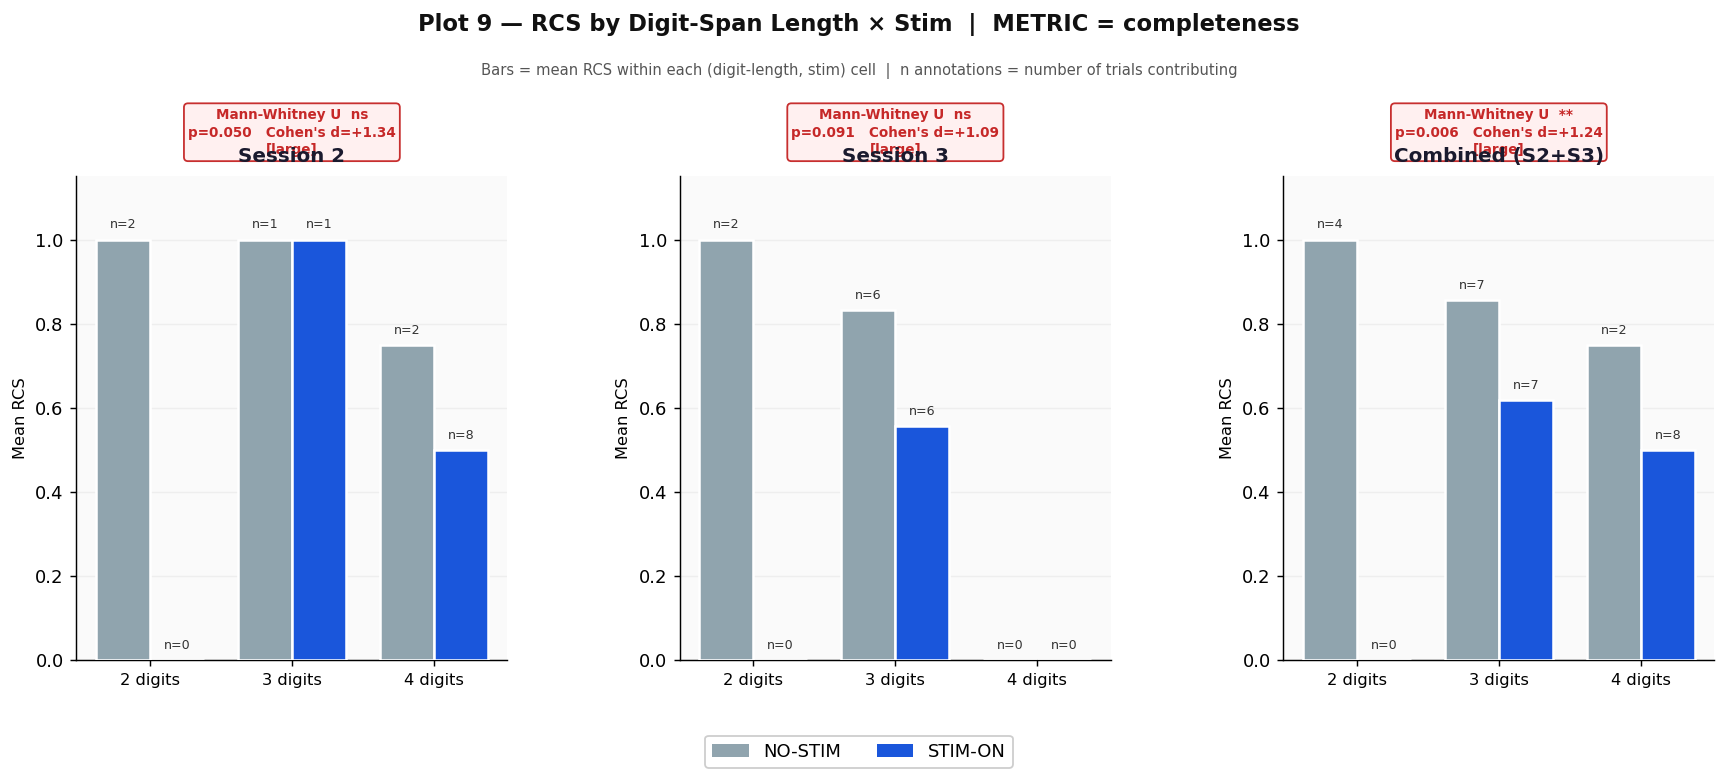

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plot9_rcs_by_digits_completeness.png


In [224]:
# ── Cell: Plot 9 — RCS by digit-length × stim group ────────────────────────
digit_lengths = sorted(set(t['digits'] for t in all_combined))

fig, axes = plt.subplots(1, 3, figsize=(14, 6), facecolor='white')
fig.subplots_adjust(wspace=0.40, top=0.78, bottom=0.16, left=0.07, right=0.97)

for ax, (sess_label, trials, n_total) in zip(axes, sessions_info):
    xs = np.arange(len(digit_lengths))
    w = 0.38
    means_off, means_on, n_off, n_on = [], [], [], []
    for d in digit_lengths:
        bucket = [t for t in trials if t['digits'] == d]
        off = [t['rcs'] for t in bucket if not t['stim_present_condB']]
        on_ = [t['rcs'] for t in bucket if     t['stim_present_condB']]
        means_off.append(np.mean(off) if off else 0)
        means_on.append( np.mean(on_) if on_ else 0)
        n_off.append(len(off))
        n_on.append(len(on_))

    bars_off = ax.bar(xs - w/2, means_off, width=w, color=C_NO_STIM,
                      edgecolor='white', linewidth=1.4, zorder=3, label='NO-STIM')
    bars_on  = ax.bar(xs + w/2, means_on, width=w, color=C_STIM,
                      edgecolor='white', linewidth=1.4, zorder=3, label='STIM-ON')
    for i, (mo, mn, no_, no_on) in enumerate(zip(means_off, means_on, n_off, n_on)):
        ax.text(xs[i] - w/2, mo + 0.02, f'n={no_}', ha='center', va='bottom',
                fontsize=7, color='#333')
        ax.text(xs[i] + w/2, mn + 0.02, f'n={no_on}', ha='center', va='bottom',
                fontsize=7, color='#333')

    ax.set_xticks(xs)
    ax.set_xticklabels([f'{d} digits' for d in digit_lengths], fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_ylabel('Mean RCS', fontsize=9)
    ax.yaxis.grid(True, color='#eeeeee', zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    ax.set_title(sess_label, fontsize=11, fontweight='bold', color='#1A1A2E', pad=8)

    # Overall metric badge per panel — pool across digit lengths
    off_all = [t for t in trials if not t['stim_present_condB']]
    on_all  = [t for t in trials if     t['stim_present_condB']]
    res = _rcs_badge(off_all, on_all, sess_label.startswith('Combined'))
    draw_stat_box(ax, res, x=0.5, y=1.04, fontsize=7.5)

fig.suptitle(wrap_title(f'Plot 9 — RCS by Digit-Span Length × Stim  |  METRIC = {METRIC}', width=100),
             fontsize=12.5, fontweight='bold', color='#111', y=0.99)
fig.text(0.5, 0.91,
         wrap_title('Bars = mean RCS within each (digit-length, stim) cell  |  '
                    'n annotations = number of trials contributing', width=110),
         ha='center', fontsize=8.2, color='#555')
fig.legend(handles=[mpatches.Patch(facecolor=C_NO_STIM, label='NO-STIM'),
                    mpatches.Patch(facecolor=C_STIM,    label='STIM-ON')],
           loc='lower center', ncol=2, fontsize=10, framealpha=0.97,
           facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))
save_fig(fig, COMBINED_DIR / f'plot9_rcs_by_digits_{METRIC}.png')


## Plot 10 — **NEW** — All-metrics comparison table

Because the METRIC switch is only one step, here we run **every** metric side
by side and print the result table. Handy when you want to see at a glance
how the numbers move as you change the test.


In [225]:
# ── Cell: Plot 10 — Every metric side-by-side ──────────────────────────────
rows = []
for sess_label, trials, _ in sessions_info:
    wrong = [t for t in trials if t['error_type'] in ('PARTIAL_REVERSAL', 'OTHER')]
    off = [t for t in wrong if not t['stim_present_condB']]
    on_ = [t for t in wrong if     t['stim_present_condB']]

    for target in ['PARTIAL_REVERSAL', 'OTHER']:
        paired = paired_partial if target == 'PARTIAL_REVERSAL' else paired_other
        for m in ['fisher', 'chi2', 'wilcoxon', 'rm_anova', 'completeness']:
            r = run_metric(off, on_, target,
                           paired_rates_off=paired[0], paired_rates_on=paired[1],
                           metric=m)
            rows.append(dict(
                scope      = sess_label,
                target     = target,
                metric     = m,
                test       = r['stat_name'] or m,
                p_value    = r['p_value'],
                effect     = r['effect'],
                effect_lab = r['effect_label'],
                n_off      = r['n_off'],
                n_on       = r['n_on'],
                stars      = r['stars'],
                note       = r['note'],
            ))

results_df = pd.DataFrame(rows)
print('=' * 95)
print('  All metrics — side-by-side comparison (Partial Reversal + Other)')
print('=' * 95)

for target in ['PARTIAL_REVERSAL', 'OTHER']:
    print(f'\n  TARGET = {target}')
    print('  ' + '-' * 93)
    sub = results_df[results_df['target'] == target]
    for _, r in sub.iterrows():
        p_s = f"{r['p_value']:.4f}" if not np.isnan(r['p_value']) else '   N/A'
        e_s = f"{r['effect']:+.3f}" if (r['effect'] is not None and not np.isnan(r['effect'])) else '   N/A'
        note = f"  [{r['note']}]" if r['note'] else ''
        print(f'    {r["scope"]:<20s} {r["metric"]:<14s} {r["test"]:<22s} '
              f'p={p_s}  {r["stars"]:<3s}  eff={e_s}  [{r["effect_lab"]}]{note}')

print()
results_df.to_csv(COMBINED_DIR / 'all_metrics_results.csv', index=False)
print(f'Full table saved -> {COMBINED_DIR / "all_metrics_results.csv"}')


  All metrics — side-by-side comparison (Partial Reversal + Other)

  TARGET = PARTIAL_REVERSAL
  ---------------------------------------------------------------------------------------------
    Session 2            fisher         Fisher's exact         p=   N/A       eff=   N/A  [N/A]
    Session 2            chi2           Chi-square             p=   N/A       eff=   N/A  [N/A]
    Session 2            wilcoxon       Wilcoxon signed-rank   p=   N/A       eff=   N/A  [N/A]  [descriptive at n<5 sessions]
    Session 2            rm_anova       RM-ANOVA F             p=   N/A       eff=   N/A  [N/A]  [degrees of freedom ≤ 0 or no variance | descriptive at n<5 sessions]
    Session 2            completeness   completeness           p=   N/A       eff=   N/A  [N/A]  [need ≥ 2 trials per group for RCS test]
    Session 3            fisher         Fisher's exact         p=1.0000  ns   eff=   N/A  [N/A]
    Session 3            chi2           Chi-square             p=   N/A       eff=   N/A

---

# 7. How to switch metrics — in one line

Edit the `METRIC` cell at the top of the Setup section to one of:

```python
METRIC = 'fisher'
METRIC = 'chi2'
METRIC = 'wilcoxon'
METRIC = 'rm_anova'
METRIC = 'completeness'
```

Then "Run All". Every plot regenerates with the new metric on the badge, and
output filenames are suffixed with `_<metric>.png` so old runs aren't overwritten.

---

# 8. Interpretation cheat-sheet

| `METRIC` | Best for | Reported statistic | Effect size | Notes at n=2 sessions |
|----------|----------|--------------------|-------------|----------------------|
| `fisher` | Small counts, single error-type rate | Fisher p | Cohen's *d* | ✅ recommended default |
| `chi2` | Overall stim × error-type association | χ² p | Cramér's *V* | ⚠ check expected≥5 |
| `wilcoxon` | Within-subject paired sessions | W p | Cohen's *d* (paired) | ⚠ descriptive only |
| `rm_anova` | Session × stim decomposition | F p | partial η² | ⚠ descriptive only |
| `completeness` | Per-trial graded errors | t / U p | Cohen's *d* | ✅ full-power even with 14 trials |

`fisher` and `completeness` are the two you will interpret most safely at the
current sample size. `wilcoxon` and `rm_anova` become informative once you
accumulate more sessions.


## WIth respec to trial type and error type

PCU + multi-label error types annotated.
S2 error breakdown (multi-label, counts sum > n_trials if overlap):
  CORRECT: 6
  SUBSTITUTION: 2
  PARTIAL_REVERSAL: 3
  PERMUTATION: 3
  OTHER: 0
S3 error breakdown:
  CORRECT: 8
  SUBSTITUTION: 1
  PARTIAL_REVERSAL: 5
  PERMUTATION: 0
  OTHER: 0


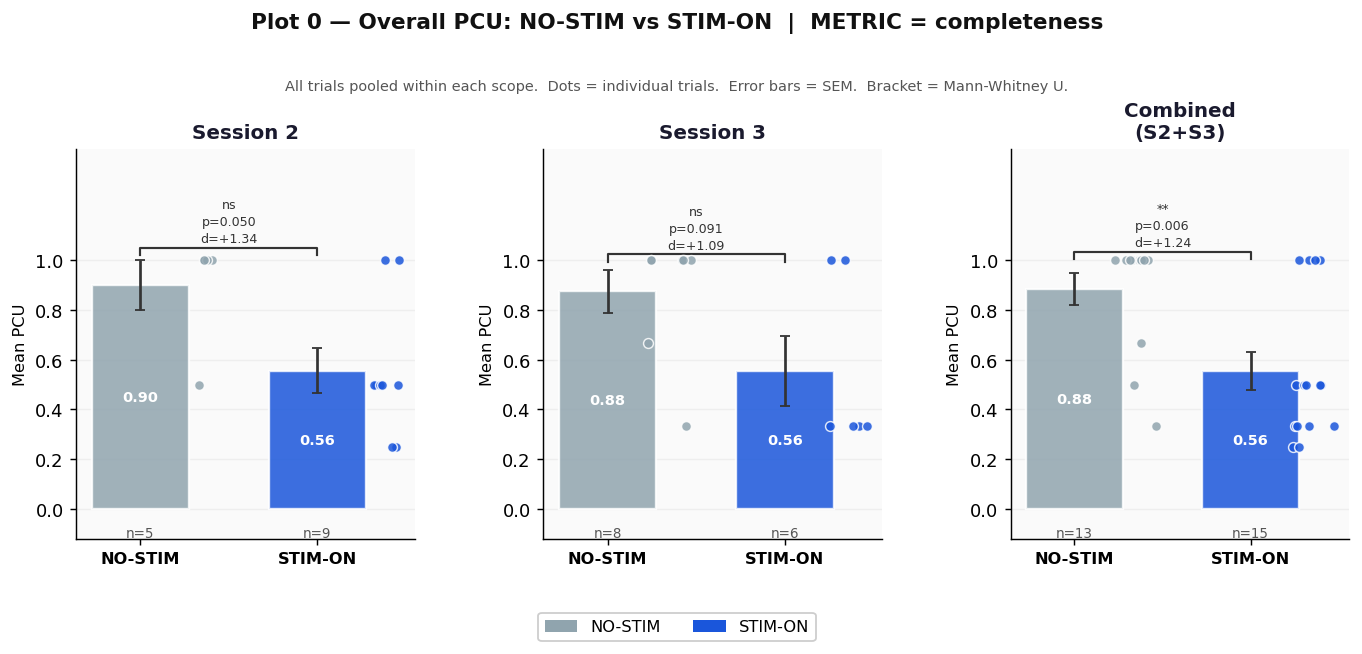

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plot0_pcu_overall_nostim_vs_stim_completeness.png


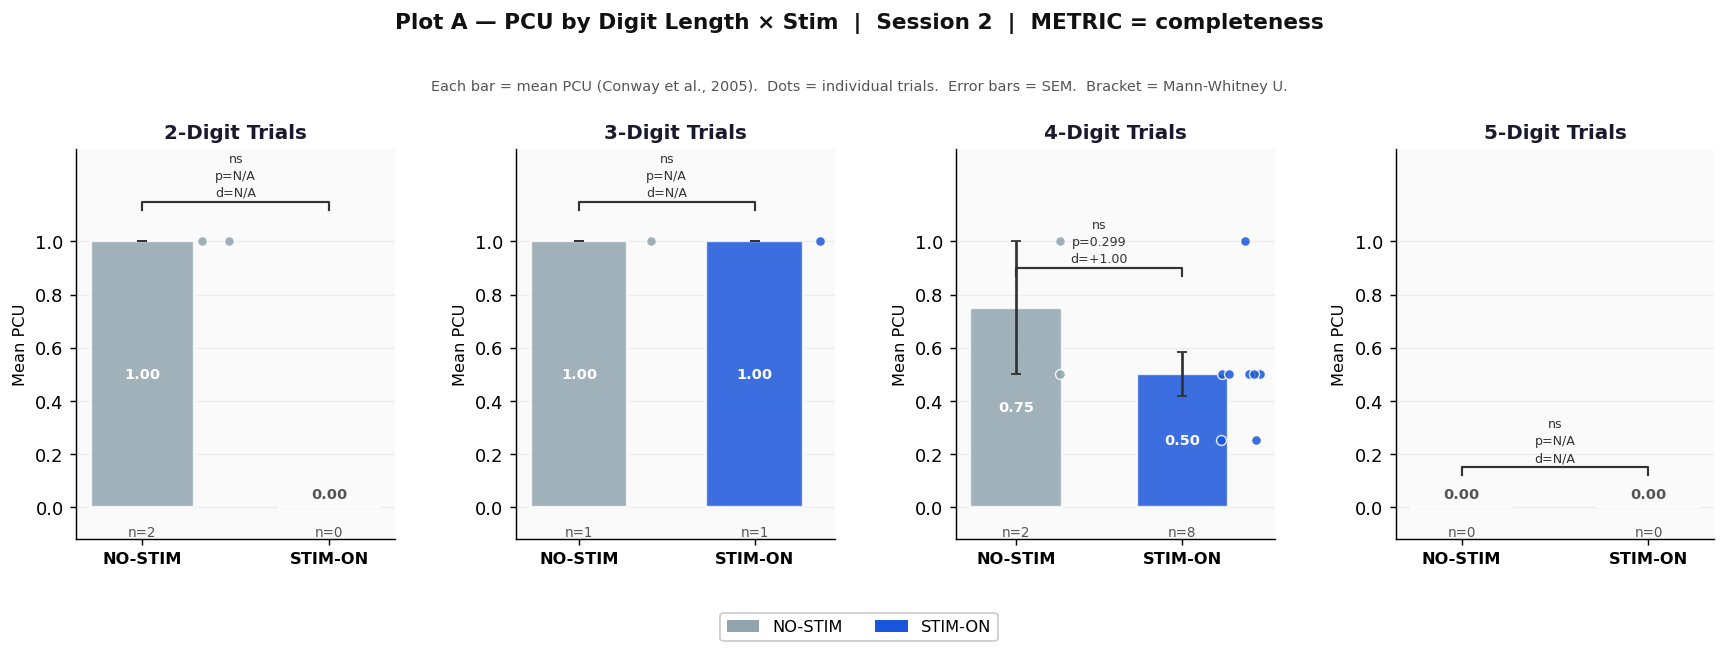

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plotA_pcu_by_digits_Session_2_completeness.png


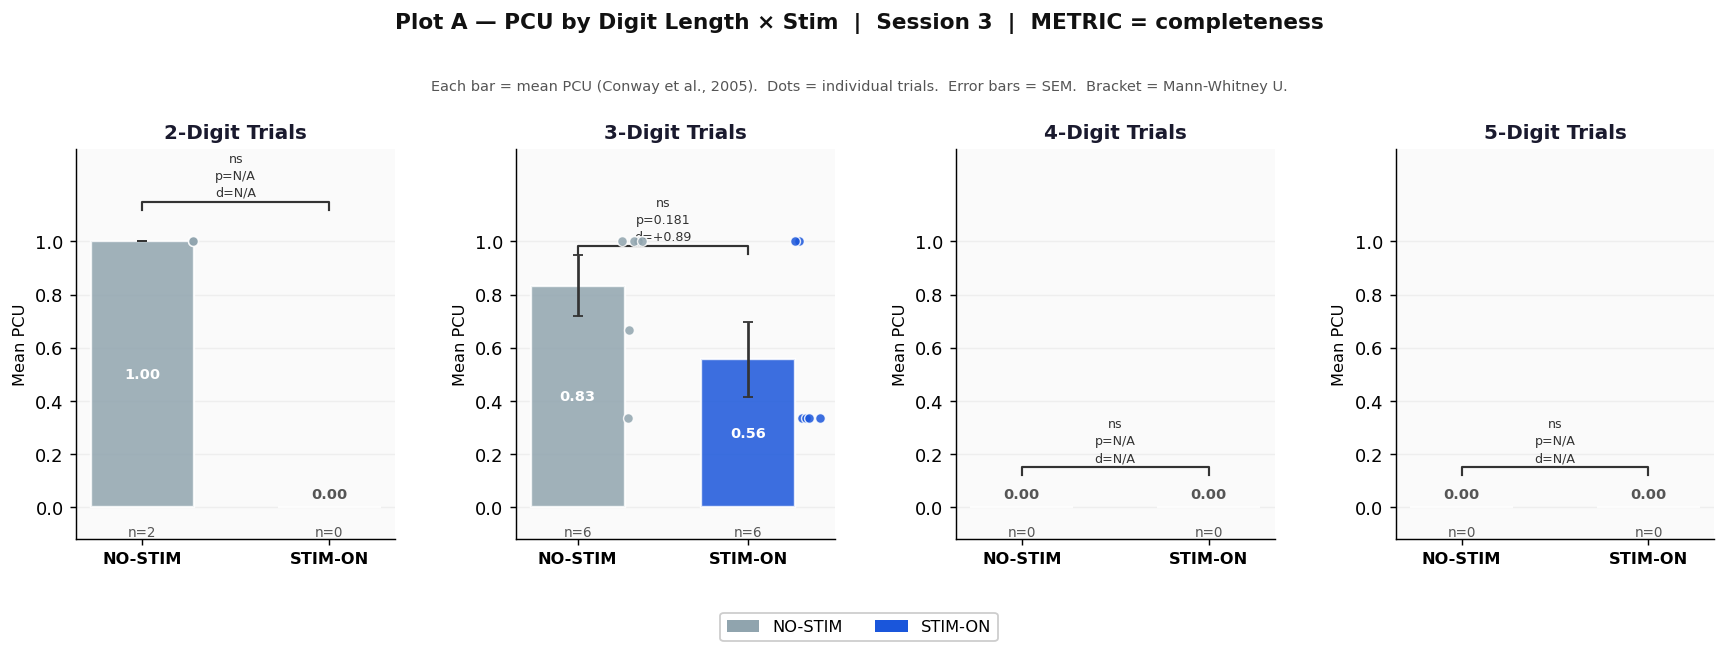

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plotA_pcu_by_digits_Session_3_completeness.png


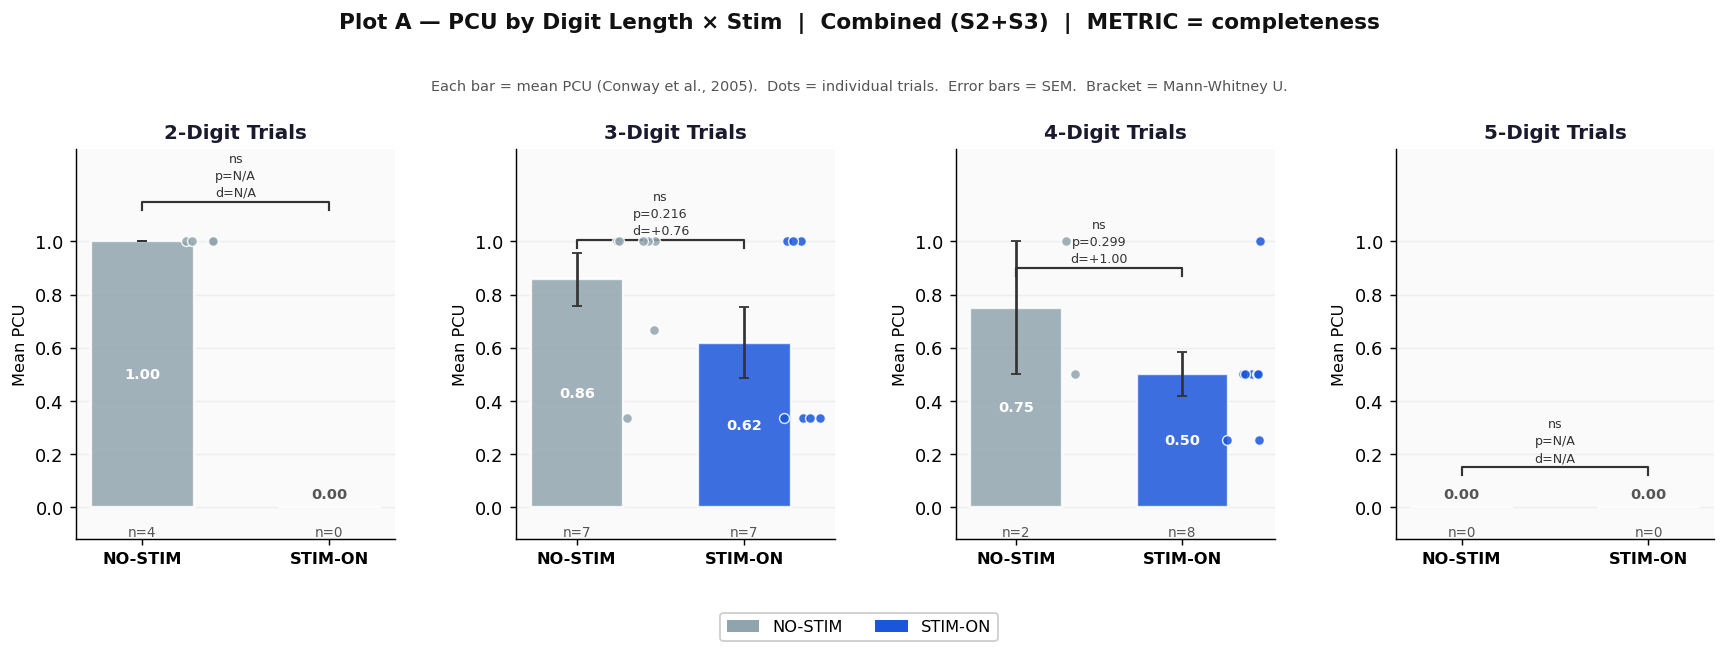

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plotA_pcu_by_digits_Combined_S2S3_completeness.png


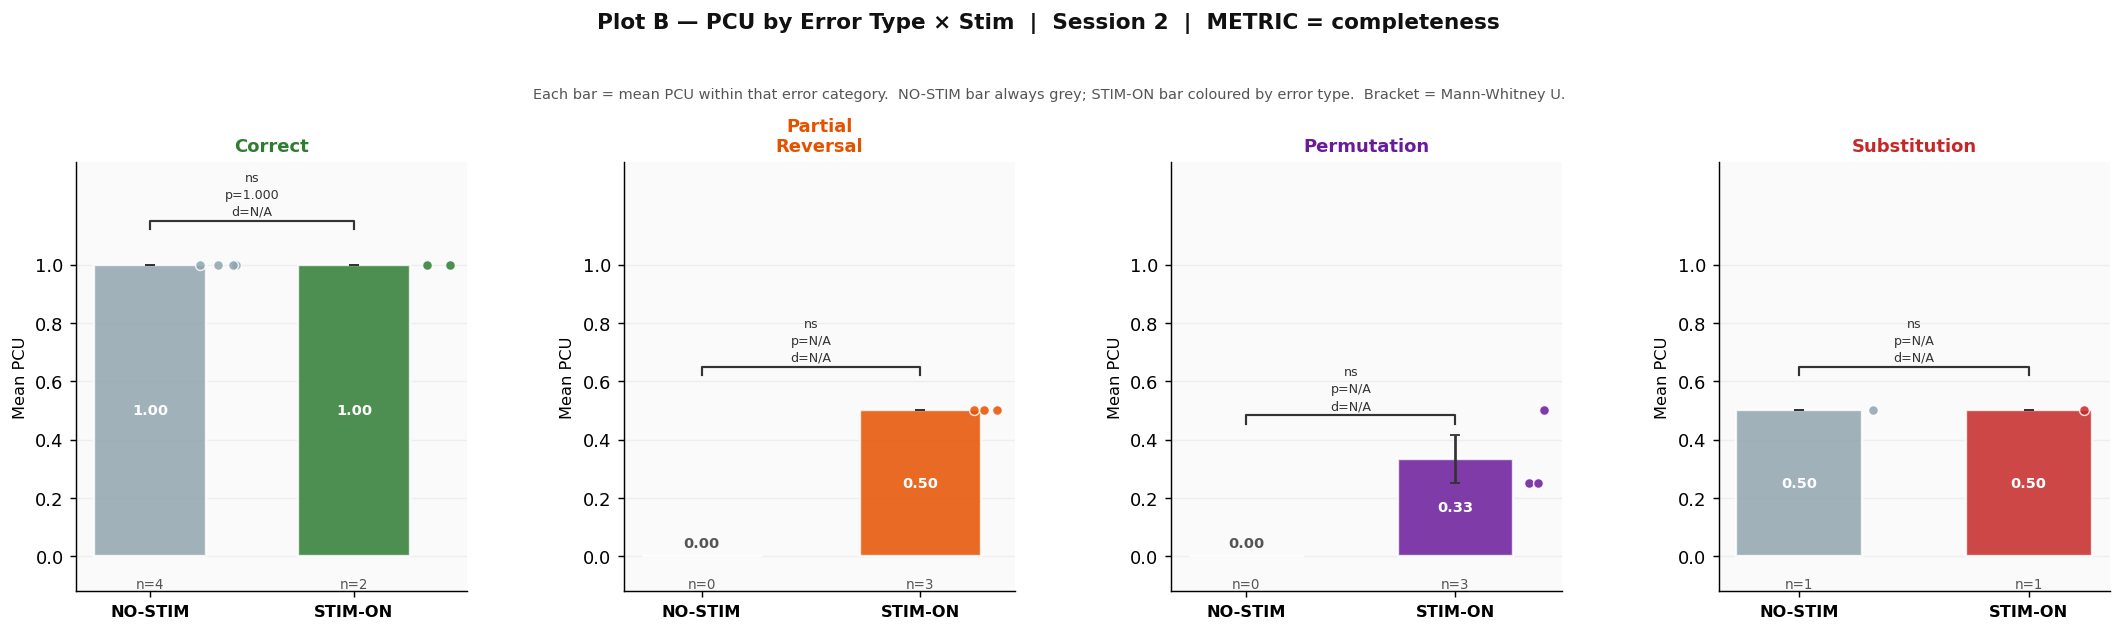

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plotB_pcu_by_errortype_Session_2_completeness.png


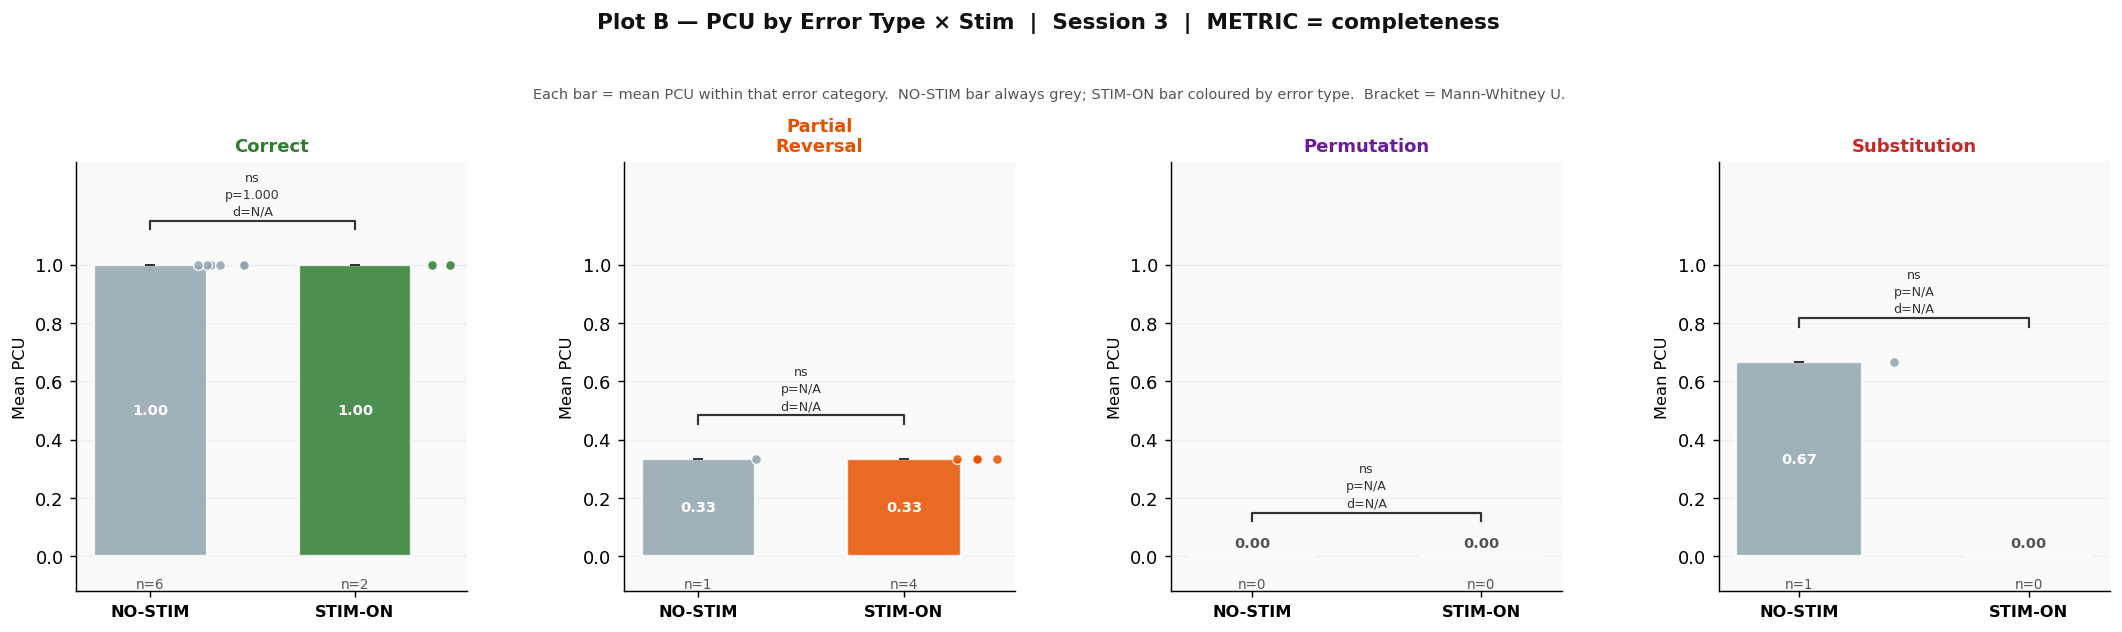

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plotB_pcu_by_errortype_Session_3_completeness.png


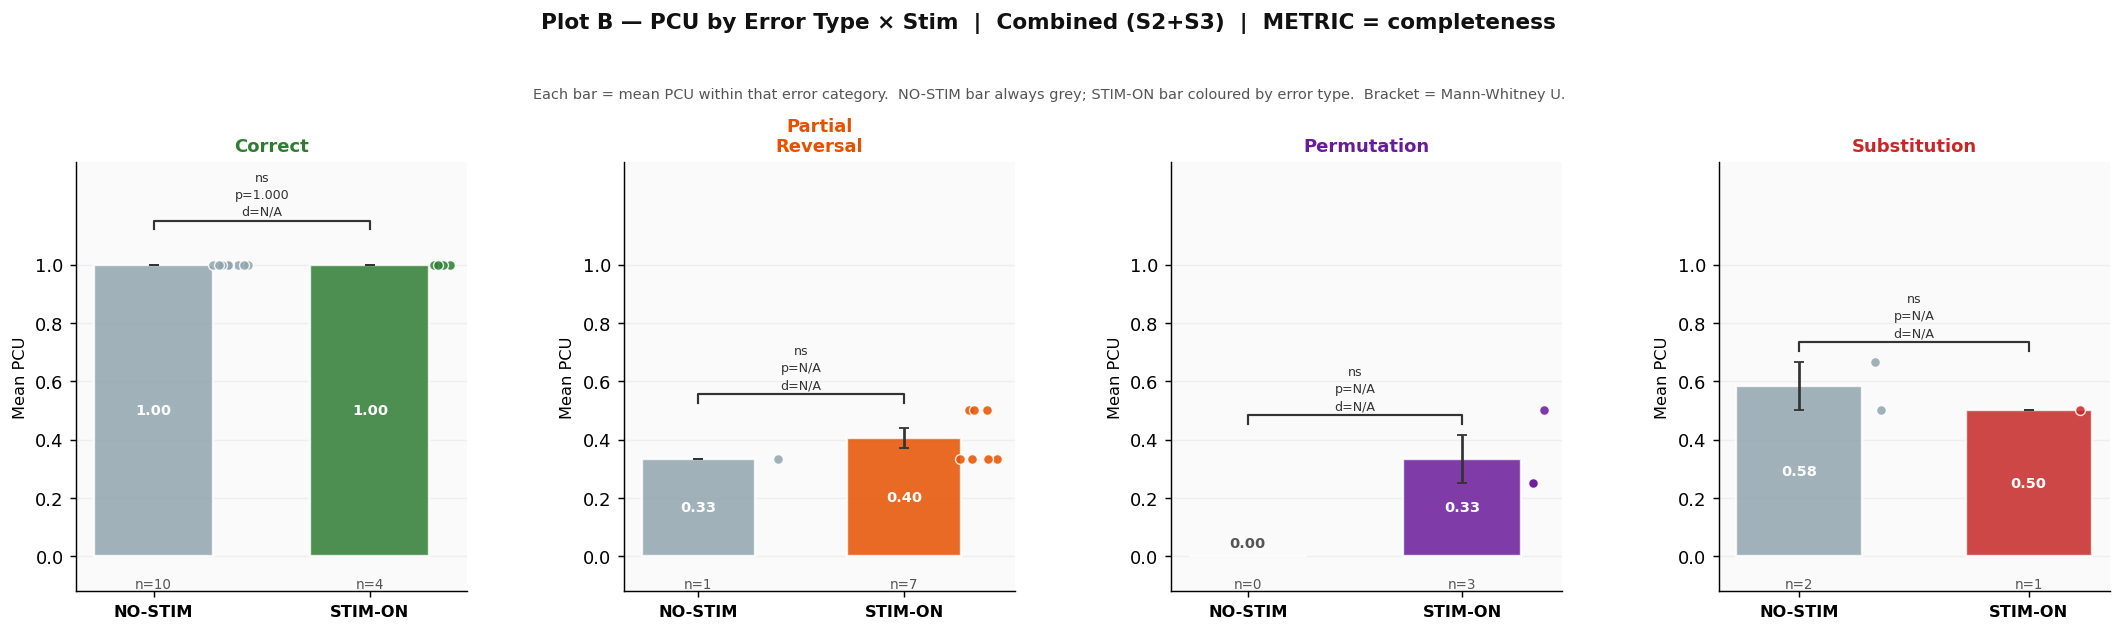

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plotB_pcu_by_errortype_Combined_S2S3_completeness.png


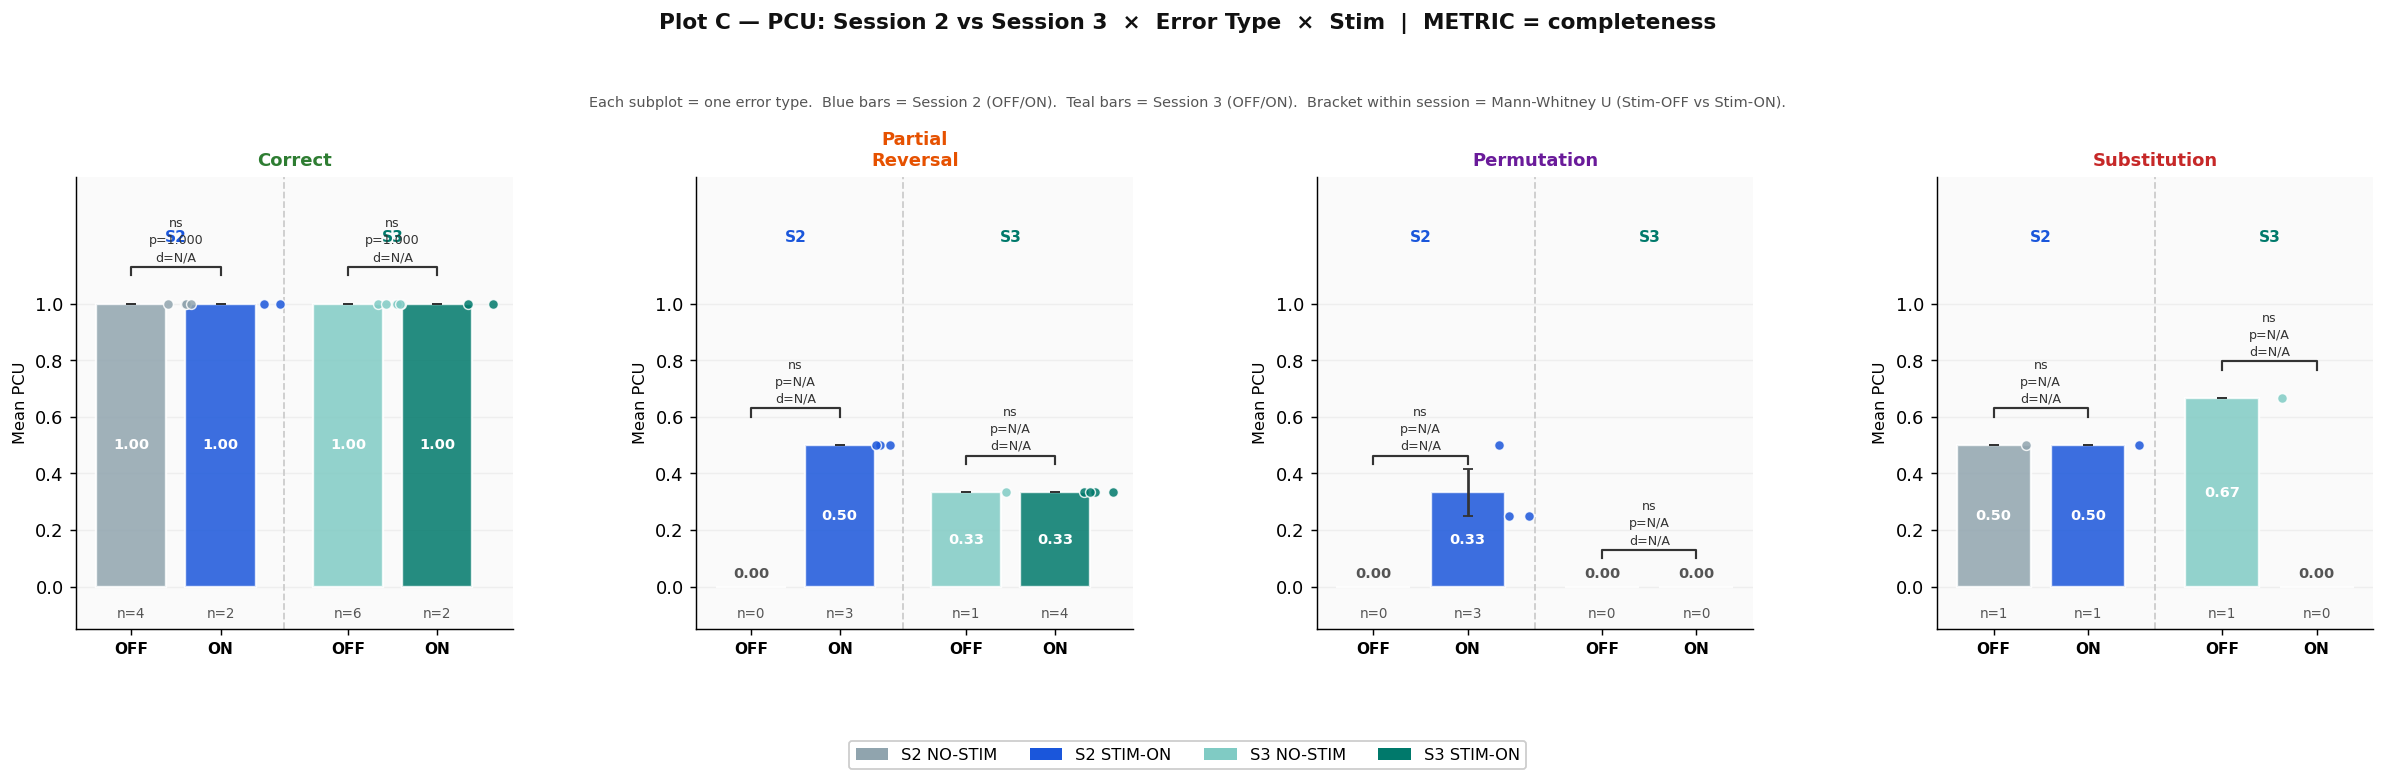

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plotC_pcu_s2_vs_s3_by_errortype_completeness.png


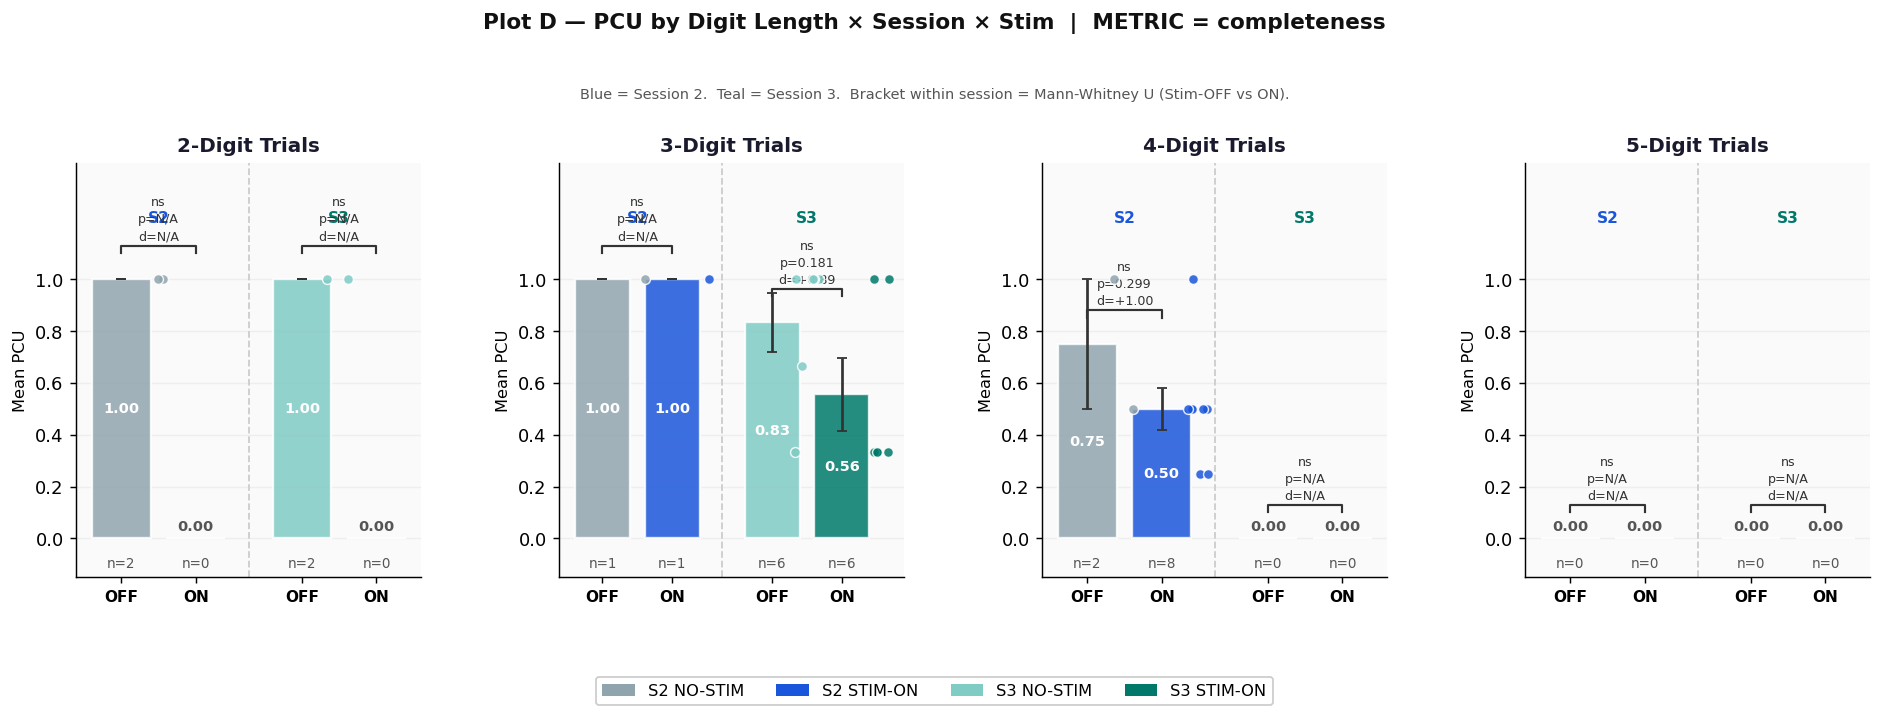

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Base\Error Type Analysis\Advanced Visuals\plotD_pcu_by_digits_s2_vs_s3_completeness.png

  PCU METRIC SUMMARY TABLE
  Scope                  Filter                  OFF mean   ON mean  n_off   n_on        p stars   Cohen d
  ----------------------------------------------------------------------------------------
  Session 2              All trials                 0.900     0.556      5      9   0.0501    ns    +1.336
  Session 3              All trials                 0.875     0.556      8      6   0.0910    ns    +1.094
  Combined               All trials                 0.885     0.556     13     15   0.0058    **    +1.243

  Session 2              2-digit                    1.000       nan      2      0      N/A   N/A       N/A
  Session 3              2-digit                    1.000       nan      2      0      N/A   N/A       N/A
  Combined               2-digit                    1.000       nan      4      0      

In [226]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell: PCU Deep-Dive — by Digit Length, by Error Type, Stim-ON vs OFF
# Conway et al. (2005) Partial-Credit Unit scoring: hits_in_position / span_length
# ══════════════════════════════════════════════════════════════════════════════

import math
import matplotlib.gridspec as gridspec

# ── 1. PCU computation ────────────────────────────────────────────────────────
def compute_pcu(presented, resp):
    """PCU (Conway et al., 2005): proportion of digits in correct serial position."""
    presented = str(presented).strip()
    resp      = str(resp).strip()
    n = len(presented)
    if n == 0:
        return 0.0
    cresp = presented[::-1]
    hits  = sum(1 for i in range(n) if i < len(resp) and resp[i] == cresp[i])
    return hits / n

# ── 2. Fine-grained error classification ─────────────────────────────────────
def classify_error_multilabel(presented, resp):
    """
    Multi-label error taxonomy for DSB wrong trials.
    Returns a list of error type strings (can have multiple).

    Labels (not mutually exclusive):
      SUBSTITUTION     — response contains a digit not in presented set
      PARTIAL_REVERSAL — patient correctly reverses the second half of presented
                         but leaves the first half unreversed, concatenated as:
                         reversed(second_half) + first_half
                         Split: first_half = presented[:ceil(n/2)],
                                second_half = presented[ceil(n/2):]
                         e.g. 3-digit 324 -> first='32', second='4'
                              -> expected response '432' (rev('4')+'32' = '4'+'32')
                         e.g. 4-digit 1432 -> first='14', second='32'
                              -> expected response '2314' (rev('32')+'14' = '23'+'14')
      PERMUTATION      — same digit multiset, not a PARTIAL_REVERSAL
                         (catch-all for other reorderings)
    """
    presented = str(presented).strip()
    resp      = str(resp).strip()

    # Removed zfill() — padding with '0' corrupts digit identity
    # when len(resp) != len(presented). Use original lengths instead.
    n = len(presented)
    if n == 0:
        return ['OTHER']

    cresp = presented[::-1]   # correct answer

    labels = []

    # ── 1. SUBSTITUTION — foreign digit present ───────────────────────────
    if sorted(resp) != sorted(presented):
        labels.append('SUBSTITUTION')

    # ── 2. PARTIAL REVERSAL ───────────────────────────────────────────────
    # Split presented into first_half (ceil(n/2) digits) and second_half (floor(n/2) digits).
    # Patient reverses the second half correctly but leaves first half as-is.
    # Expected partial-reversal response = reversed(second_half) + first_half
    #
    # Examples (verified):
    #   3-digit: 324 -> first='32', second='4'  -> rev('4')+'32'  = '432'  ✓
    #   3-digit: 143 -> first='14', second='3'  -> rev('3')+'14'  = '314'  ✓
    #   4-digit: 1432-> first='14', second='32' -> rev('32')+'14' = '2314' ✓
    #   4-digit: 4521-> first='45', second='21' -> rev('21')+'45' = '1245' ✓
    if n >= 2:
        split        = math.ceil(n / 2)
        first_half   = presented[:split]
        second_half  = presented[split:]
        partial_resp = second_half[::-1] + first_half
        if resp == partial_resp:
            labels.append('PARTIAL_REVERSAL')

    # ── 3. PERMUTATION — same multiset, not a PARTIAL_REVERSAL
    if sorted(resp) == sorted(presented):        # no foreign digits
        if 'PARTIAL_REVERSAL' not in labels:
            labels.append('PERMUTATION')

    # ── fallback ──────────────────────────────────────────────────────────
    if not labels:
        labels.append('OTHER')

    return labels


def annotate_trials_detailed(trials):
    """Add 'pcu' and 'error_labels' (list) to every trial dict in-place."""
    for t in trials:
        t['pcu'] = compute_pcu(t.get('presented', ''), t.get('resp', ''))
        if t['acc'] == 1:
            t['error_labels'] = ['CORRECT']
        else:
            t['error_labels'] = classify_error_multilabel(
                t.get('presented', ''), t.get('resp', ''))

for _trials in [all_s2, all_s3]:
    annotate_trials_detailed(_trials)

all_combined = all_s2 + all_s3

print('PCU + multi-label error types annotated.')
print('S2 error breakdown (multi-label, counts sum > n_trials if overlap):')
for k in ['CORRECT','SUBSTITUTION','PARTIAL_REVERSAL','PERMUTATION','OTHER']:
    print(f'  {k}: {sum(1 for t in all_s2 if k in t["error_labels"])}')
print('S3 error breakdown:')
for k in ['CORRECT','SUBSTITUTION','PARTIAL_REVERSAL','PERMUTATION','OTHER']:
    print(f'  {k}: {sum(1 for t in all_s3 if k in t["error_labels"])}')

# ── 3. Shared helpers ─────────────────────────────────────────────────────────
def pcu_groups(trials):
    """Split trials into (no_stim, stim_on) lists."""
    return ([t for t in trials if not t['stim_present_condB']],
            [t for t in trials if     t['stim_present_condB']])

def mean_pcu(ts):
    vals = [t['pcu'] for t in ts]
    return np.mean(vals) if vals else np.nan

def safe_sem(vals):
    return stats.sem(vals) if len(vals) > 1 else 0.0

def pcu_stat(off_vals, on_vals):
    """
    Return (p, stat_name, cohens_d_val) comparing two PCU value lists.
    Uses Mann-Whitney U (non-parametric, appropriate for small n).
    """
    if len(off_vals) < 2 or len(on_vals) < 2:
        return np.nan, 'n<2', np.nan
    u, p = stats.mannwhitneyu(off_vals, on_vals, alternative='two-sided')
    d = cohens_d(np.array(off_vals), np.array(on_vals))
    return float(p), 'Mann-Whitney U', d

def draw_bracket(ax, x1, x2, y, p, d):
    """Draw a significance bracket with p-value, stars, and Cohen's d."""
    stars = sig_stars(p)
    if stars == '':
        stars = 'ns'
    h = 0.03

    # bracket lines
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='#333')

    # p-value line
    if not np.isnan(p):
        p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
    else:
        p_str = 'p=N/A'

    # Cohen's d line
    d_str = f'd={d:+.2f}' if not np.isnan(d) else 'd=N/A'

    # stars line
    label = f'{stars}\n{p_str}\n{d_str}'

    ax.text((x1+x2)/2, y+h+0.01, label,
            ha='center', va='bottom', fontsize=7.0, color='#333',
            linespacing=1.4)

def bar_with_dots(ax, xi, vals, color, label=None):
    """Draw a single bar + jittered dots + mean PCU value label."""
    m   = mean_pcu_list(vals)
    sem = safe_sem(vals) if vals else 0.0
    bar_h = m if not np.isnan(m) else 0

    ax.bar(xi, bar_h,
           width=0.55, color=color, edgecolor='white',
           linewidth=1.3, zorder=3, label=label, alpha=0.85)

    if vals:
        jit = (np.random.rand(len(vals)) - 0.5) * 0.25
        ax.scatter(np.full(len(vals), xi) + jit + 0.35, vals,
                   s=30, color=color, edgecolor='white',
                   linewidth=0.8, alpha=0.85, zorder=5)
        ax.errorbar(xi, m, yerr=sem, fmt='none',
                    ecolor='#333', elinewidth=1.5, capsize=3, zorder=6)

    # ── mean PCU value printed inside/above bar ──────────────────────────
    if not np.isnan(bar_h) and bar_h > 0:
        label_y = bar_h / 2          # inside bar, vertically centred
        ax.text(xi, label_y, f'{bar_h:.2f}',
                ha='center', va='center', fontsize=8.0,
                fontweight='bold', color='white', zorder=7)
    elif not np.isnan(bar_h):        # bar is zero or very small — print above
        ax.text(xi, 0.02, f'{bar_h:.2f}',
                ha='center', va='bottom', fontsize=8.0,
                fontweight='bold', color='#555', zorder=7)

    # n= label below x-axis
    ax.text(xi, -0.07, f'n={len(vals)}',
            ha='center', va='top', fontsize=7.5, color='#555')

    return m

def mean_pcu_list(vals):
    return np.mean(vals) if vals else np.nan


# ════════════════════════════════════════════════════════════════════════════
# PLOT 0 — Overall PCU: NO-STIM vs STIM-ON  (S2 / S3 / Combined)
# Three side-by-side subplots so the significant Combined result
# (p=0.0058 **) is always directly visible in a single figure.
# ════════════════════════════════════════════════════════════════════════════
np.random.seed(0)
fig, axes = plt.subplots(1, 3, figsize=(11, 5), facecolor='white')
fig.subplots_adjust(wspace=0.38, top=0.78, bottom=0.18,
                    left=0.08, right=0.97)

for ax, (scope_label, trials) in zip(axes, [('Session 2',        all_s2),
                                              ('Session 3',        all_s3),
                                              ('Combined\n(S2+S3)', all_combined)]):
    off_v = [t['pcu'] for t in trials if not t['stim_present_condB']]
    on_v  = [t['pcu'] for t in trials if     t['stim_present_condB']]

    bar_with_dots(ax, 0, off_v, C_NO_STIM)
    bar_with_dots(ax, 1, on_v,  C_STIM)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['NO-STIM', 'STIM-ON'], fontsize=9, fontweight='bold')
    ax.set_ylim(-0.12, 1.45)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_ylabel('Mean PCU', fontsize=9)
    ax.yaxis.grid(True, color='#eee', zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    ax.set_title(scope_label, fontsize=11, fontweight='bold',
                 color='#1A1A2E', pad=6)

    p, _, d_val = pcu_stat(off_v, on_v)
    top_y = np.nanmax([mean_pcu_list(off_v) if off_v else 0.0,
                       mean_pcu_list(on_v)  if on_v  else 0.0])
    draw_bracket(ax, 0, 1, top_y + 0.12, p, d_val)

fig.suptitle(
    wrap_title(f'Plot 0 — Overall PCU: NO-STIM vs STIM-ON  |  METRIC = {METRIC}',
               width=90),
    fontsize=12, fontweight='bold', color='#111', y=0.99)
fig.text(0.5, 0.87,
         'All trials pooled within each scope.  '
         'Dots = individual trials.  Error bars = SEM.  '
         'Bracket = Mann-Whitney U.',
         ha='center', fontsize=8, color='#555')
fig.legend(
    handles=[mpatches.Patch(facecolor=C_NO_STIM, label='NO-STIM'),
             mpatches.Patch(facecolor=C_STIM,    label='STIM-ON')],
    loc='lower center', ncol=2, fontsize=9, framealpha=0.97,
    facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))

save_fig(fig, COMBINED_DIR / f'plot0_pcu_overall_nostim_vs_stim_{METRIC}.png')


# ════════════════════════════════════════════════════════════════════════════
# PLOT A — PCU by Digit Length (2 / 3 / 4 / 5) × Stim  ×  Session
# One figure per session (S2, S3, Combined); one subplot per digit length
# ════════════════════════════════════════════════════════════════════════════
np.random.seed(42)
DIGIT_LENGTHS = [2, 3, 4, 5]

for sess_label, trials, _ in [('Session 2', all_s2, 14),
                                ('Session 3', all_s3, 14),
                                ('Combined (S2+S3)', all_combined, 28)]:

    fig, axes = plt.subplots(1, len(DIGIT_LENGTHS),
                              figsize=(14, 5), facecolor='white')
    fig.subplots_adjust(wspace=0.38, top=0.78, bottom=0.18,
                        left=0.07, right=0.97)

    for ax, d in zip(axes, DIGIT_LENGTHS):
        bucket = [t for t in trials if t['digits'] == d]
        off_v = [t['pcu'] for t in bucket if not t['stim_present_condB']]
        on_v  = [t['pcu'] for t in bucket if     t['stim_present_condB']]

        bar_with_dots(ax, 0, off_v, C_NO_STIM)
        bar_with_dots(ax, 1, on_v,  C_STIM)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['NO-STIM', 'STIM-ON'], fontsize=9, fontweight='bold')
        ax.set_ylim(-0.12, 1.35)
        ax.set_yticks(np.arange(0, 1.01, 0.2))
        ax.set_ylabel('Mean PCU', fontsize=9)
        ax.yaxis.grid(True, color='#eee', zorder=0)
        ax.set_axisbelow(True)
        ax.set_facecolor('#FAFAFA')
        ax.set_title(f'{d}-Digit Trials', fontsize=11,
                     fontweight='bold', color='#1A1A2E', pad=6)

        p, _, d_val = pcu_stat(off_v, on_v)

        # FIX 2: Use np.nanmax to safely handle nan values from empty lists
        top_y = np.nanmax([mean_pcu_list(off_v) if off_v else 0.0,
                           mean_pcu_list(on_v)  if on_v  else 0.0])
        draw_bracket(ax, 0, 1, top_y + 0.12, p, d_val)

    fig.suptitle(
        wrap_title(f'Plot A — PCU by Digit Length × Stim  |  {sess_label}  |  METRIC = {METRIC}',
                   width=100),
        fontsize=12, fontweight='bold', color='#111', y=0.99)
    fig.text(0.5, 0.87,
             'Each bar = mean PCU (Conway et al., 2005).  '
             'Dots = individual trials.  Error bars = SEM.  '
             'Bracket = Mann-Whitney U.',
             ha='center', fontsize=8, color='#555')
    fig.legend(
        handles=[mpatches.Patch(facecolor=C_NO_STIM, label='NO-STIM'),
                 mpatches.Patch(facecolor=C_STIM,    label='STIM-ON')],
        loc='lower center', ncol=2, fontsize=9, framealpha=0.97,
        facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))

    slug = sess_label.replace(' ', '_').replace('(', '').replace(')', '').replace('+', '')
    save_fig(fig, COMBINED_DIR / f'plotA_pcu_by_digits_{slug}_{METRIC}.png')


# ════════════════════════════════════════════════════════════════════════════
# PLOT B — PCU by Error Type × Stim  ×  Session
# One figure per session; one subplot per error type
# ════════════════════════════════════════════════════════════════════════════
ERROR_TYPES   = ['CORRECT', 'PARTIAL_REVERSAL', 'PERMUTATION', 'SUBSTITUTION']
ERROR_COLORS  = {'CORRECT':          '#2E7D32',
                 'PARTIAL_REVERSAL': '#E65100',
                 'PERMUTATION':      '#6A1B9A',
                 'SUBSTITUTION':     '#C62828'}
ERROR_LABELS  = {'CORRECT':          'Correct',
                 'PARTIAL_REVERSAL': 'Partial\nReversal',
                 'PERMUTATION':      'Permutation',
                 'SUBSTITUTION':     'Substitution'}

np.random.seed(7)
for sess_label, trials, _ in [('Session 2', all_s2, 14),
                                ('Session 3', all_s3, 14),
                                ('Combined (S2+S3)', all_combined, 28)]:

    fig, axes = plt.subplots(1, len(ERROR_TYPES),
                              figsize=(17, 5.5), facecolor='white')
    fig.subplots_adjust(wspace=0.40, top=0.78, bottom=0.18,
                        left=0.06, right=0.98)

    for ax, etype in zip(axes, ERROR_TYPES):
        col   = ERROR_COLORS[etype]
        bucket = [t for t in trials if etype in t['error_labels']]
        off_v  = [t['pcu'] for t in bucket if not t['stim_present_condB']]
        on_v   = [t['pcu'] for t in bucket if     t['stim_present_condB']]

        bar_with_dots(ax, 0, off_v, C_NO_STIM)
        bar_with_dots(ax, 1, on_v,  col)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['NO-STIM', 'STIM-ON'], fontsize=9, fontweight='bold')
        ax.set_ylim(-0.12, 1.35)
        ax.set_yticks(np.arange(0, 1.01, 0.2))
        ax.set_ylabel('Mean PCU', fontsize=9)
        ax.yaxis.grid(True, color='#eee', zorder=0)
        ax.set_axisbelow(True)
        ax.set_facecolor('#FAFAFA')
        ax.set_title(ERROR_LABELS[etype], fontsize=10,
                     fontweight='bold', color=col, pad=6)

        p, _, d_val = pcu_stat(off_v, on_v)
        top_y = np.nanmax([mean_pcu_list(off_v) if off_v else 0.0,
                           mean_pcu_list(on_v)  if on_v  else 0.0])
        draw_bracket(ax, 0, 1, top_y + 0.12, p, d_val)

    fig.suptitle(
        wrap_title(f'Plot B — PCU by Error Type × Stim  |  {sess_label}  |  METRIC = {METRIC}',
                   width=110),
        fontsize=12, fontweight='bold', color='#111', y=0.99)
    fig.text(0.5, 0.87,
             'Each bar = mean PCU within that error category.  '
             'NO-STIM bar always grey; STIM-ON bar coloured by error type.  '
             'Bracket = Mann-Whitney U.',
             ha='center', fontsize=8, color='#555')

    slug = sess_label.replace(' ', '_').replace('(', '').replace(')', '').replace('+', '')
    save_fig(fig, COMBINED_DIR / f'plotB_pcu_by_errortype_{slug}_{METRIC}.png')


# ════════════════════════════════════════════════════════════════════════════
# PLOT C — Session 2 vs Session 3 PCU comparison
# One subplot per error type; within each subplot: S2-OFF  S2-ON  S3-OFF  S3-ON
# ════════════════════════════════════════════════════════════════════════════
S2_OFF_C = '#90A4AE';  S2_ON_C = '#1A56DB'
S3_OFF_C = '#80CBC4';  S3_ON_C = '#00796B'

np.random.seed(13)
fig, axes = plt.subplots(1, len(ERROR_TYPES),
                          figsize=(19, 6), facecolor='white')
fig.subplots_adjust(wspace=0.42, top=0.78, bottom=0.20,
                    left=0.05, right=0.98)

X_POSITIONS = [0, 0.7, 1.7, 2.4]   # S2-OFF  S2-ON  |gap|  S3-OFF  S3-ON

for ax, etype in zip(axes, ERROR_TYPES):
    col = ERROR_COLORS[etype]

    # FIX 1: Changed t['error_type_detail'] == etype  →  etype in t['error_labels']
    # 'error_type_detail' was never added to trial dicts; annotate_trials_detailed()
    # adds 'error_labels' (a list), so membership testing with 'in' is correct.
    s2_off = [t['pcu'] for t in all_s2 if etype in t['error_labels']
              and not t['stim_present_condB']]
    s2_on  = [t['pcu'] for t in all_s2 if etype in t['error_labels']
              and     t['stim_present_condB']]
    s3_off = [t['pcu'] for t in all_s3 if etype in t['error_labels']
              and not t['stim_present_condB']]
    s3_on  = [t['pcu'] for t in all_s3 if etype in t['error_labels']
              and     t['stim_present_condB']]

    groups = [(s2_off, S2_OFF_C), (s2_on, S2_ON_C),
              (s3_off, S3_OFF_C), (s3_on, S3_ON_C)]

    for xi, (vals, c) in zip(X_POSITIONS, groups):
        bar_with_dots(ax, xi, vals, c)

    # Divider between S2 and S3
    ax.axvline(x=1.2, color='#ccc', linewidth=1.0, linestyle='--', zorder=1)

    # Session labels
    ax.text(0.35,  1.22, 'S2', ha='center', fontsize=8.5,
            fontweight='bold', color='#1A56DB')
    ax.text(2.05, 1.22, 'S3', ha='center', fontsize=8.5,
            fontweight='bold', color='#00796B')

    # Stim-ON vs OFF brackets within each session
    for x1, x2, vals_a, vals_b in [(0, 0.7, s2_off, s2_on),
                                    (1.7, 2.4, s3_off, s3_on)]:
        p, _, d_val = pcu_stat(vals_a, vals_b)
        top_y = np.nanmax([mean_pcu_list(vals_a) if vals_a else 0.0,
                           mean_pcu_list(vals_b) if vals_b else 0.0])
        draw_bracket(ax, x1, x2, top_y + 0.10, p, d_val)

    ax.set_xticks(X_POSITIONS)
    ax.set_xticklabels(['OFF', 'ON', 'OFF', 'ON'],
                       fontsize=8.5, fontweight='bold')
    ax.set_ylim(-0.15, 1.45)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_ylabel('Mean PCU', fontsize=9)
    ax.yaxis.grid(True, color='#eee', zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    ax.set_title(ERROR_LABELS[etype], fontsize=10,
                 fontweight='bold', color=col, pad=6)

fig.suptitle(
    wrap_title(f'Plot C — PCU: Session 2 vs Session 3  ×  Error Type  ×  Stim  |  METRIC = {METRIC}',
               width=110),
    fontsize=12, fontweight='bold', color='#111', y=0.99)
fig.text(0.5, 0.87,
         'Each subplot = one error type.  '
         'Blue bars = Session 2 (OFF/ON).  Teal bars = Session 3 (OFF/ON).  '
         'Bracket within session = Mann-Whitney U (Stim-OFF vs Stim-ON).',
         ha='center', fontsize=8, color='#555')

fig.legend(
    handles=[mpatches.Patch(facecolor=S2_OFF_C, label='S2 NO-STIM'),
             mpatches.Patch(facecolor=S2_ON_C,  label='S2 STIM-ON'),
             mpatches.Patch(facecolor=S3_OFF_C, label='S3 NO-STIM'),
             mpatches.Patch(facecolor=S3_ON_C,  label='S3 STIM-ON')],
    loc='lower center', ncol=4, fontsize=9, framealpha=0.97,
    facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))

save_fig(fig, COMBINED_DIR / f'plotC_pcu_s2_vs_s3_by_errortype_{METRIC}.png')


# ════════════════════════════════════════════════════════════════════════════
# PLOT D — PCU by Digit Length × Session (S2 vs S3), Stim-ON vs OFF
# One subplot per digit length; 4 bars each: S2-OFF S2-ON S3-OFF S3-ON
# ════════════════════════════════════════════════════════════════════════════
np.random.seed(99)
fig, axes = plt.subplots(1, len(DIGIT_LENGTHS),
                          figsize=(15, 5.5), facecolor='white')
fig.subplots_adjust(wspace=0.40, top=0.78, bottom=0.20,
                    left=0.06, right=0.98)

for ax, d in zip(axes, DIGIT_LENGTHS):
    s2_off = [t['pcu'] for t in all_s2 if t['digits'] == d
              and not t['stim_present_condB']]
    s2_on  = [t['pcu'] for t in all_s2 if t['digits'] == d
              and     t['stim_present_condB']]
    s3_off = [t['pcu'] for t in all_s3 if t['digits'] == d
              and not t['stim_present_condB']]
    s3_on  = [t['pcu'] for t in all_s3 if t['digits'] == d
              and     t['stim_present_condB']]

    for xi, (vals, c) in zip(X_POSITIONS,
                              [(s2_off, S2_OFF_C), (s2_on, S2_ON_C),
                               (s3_off, S3_OFF_C), (s3_on, S3_ON_C)]):
        bar_with_dots(ax, xi, vals, c)

    ax.axvline(x=1.2, color='#ccc', linewidth=1.0, linestyle='--', zorder=1)
    ax.text(0.35,  1.22, 'S2', ha='center', fontsize=8.5,
            fontweight='bold', color='#1A56DB')
    ax.text(2.05, 1.22, 'S3', ha='center', fontsize=8.5,
            fontweight='bold', color='#00796B')

    for x1, x2, vals_a, vals_b in [(0, 0.7, s2_off, s2_on),
                                    (1.7, 2.4, s3_off, s3_on)]:
        p, _, d_val = pcu_stat(vals_a, vals_b)
        top_y = np.nanmax([mean_pcu_list(vals_a) if vals_a else 0.0,
                           mean_pcu_list(vals_b) if vals_b else 0.0])
        draw_bracket(ax, x1, x2, top_y + 0.10, p, d_val)

    ax.set_xticks(X_POSITIONS)
    ax.set_xticklabels(['OFF', 'ON', 'OFF', 'ON'],
                       fontsize=8.5, fontweight='bold')
    ax.set_ylim(-0.15, 1.45)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_ylabel('Mean PCU', fontsize=9)
    ax.yaxis.grid(True, color='#eee', zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    ax.set_title(f'{d}-Digit Trials', fontsize=11,
                 fontweight='bold', color='#1A1A2E', pad=6)

fig.suptitle(
    wrap_title(f'Plot D — PCU by Digit Length × Session × Stim  |  METRIC = {METRIC}',
               width=100),
    fontsize=12, fontweight='bold', color='#111', y=0.99)
fig.text(0.5, 0.87,
         'Blue = Session 2.  Teal = Session 3.  '
         'Bracket within session = Mann-Whitney U (Stim-OFF vs ON).',
         ha='center', fontsize=8, color='#555')
fig.legend(
    handles=[mpatches.Patch(facecolor=S2_OFF_C, label='S2 NO-STIM'),
             mpatches.Patch(facecolor=S2_ON_C,  label='S2 STIM-ON'),
             mpatches.Patch(facecolor=S3_OFF_C, label='S3 NO-STIM'),
             mpatches.Patch(facecolor=S3_ON_C,  label='S3 STIM-ON')],
    loc='lower center', ncol=4, fontsize=9, framealpha=0.97,
    facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))

save_fig(fig, COMBINED_DIR / f'plotD_pcu_by_digits_s2_vs_s3_{METRIC}.png')


# ════════════════════════════════════════════════════════════════════════════
# PRINT — Metric summary table (PCU means + Mann-Whitney U + Cohen's d)
# ════════════════════════════════════════════════════════════════════════════
print('\n' + '='*90)
print('  PCU METRIC SUMMARY TABLE')
print('='*90)
print(f'  {"Scope":<22} {"Filter":<22} {"OFF mean":>9} {"ON mean":>9} '
      f'{"n_off":>6} {"n_on":>6} {"p":>8} {"stars":>5} {"Cohen d":>9}')
print('  ' + '-'*88)

def summary_row(scope, filter_label, off_vals, on_vals):
    m_off = mean_pcu_list(off_vals)
    m_on  = mean_pcu_list(on_vals)
    p, _, d = pcu_stat(off_vals, on_vals)
    stars = sig_stars(p) if not np.isnan(p) else 'N/A'
    p_s   = f'{p:.4f}' if not np.isnan(p) else '   N/A'
    d_s   = f'{d:+.3f}' if not np.isnan(d) else '   N/A'
    print(f'  {scope:<22} {filter_label:<22} {m_off:>9.3f} {m_on:>9.3f} '
          f'{len(off_vals):>6} {len(on_vals):>6} {p_s:>8} {stars:>5} {d_s:>9}')

# All trials
for sess_label, trials in [('Session 2', all_s2),
                             ('Session 3', all_s3),
                             ('Combined',  all_combined)]:
    off_v = [t['pcu'] for t in trials if not t['stim_present_condB']]
    on_v  = [t['pcu'] for t in trials if     t['stim_present_condB']]
    summary_row(sess_label, 'All trials', off_v, on_v)

print()

# By digit length
for d in DIGIT_LENGTHS:
    for sess_label, trials in [('Session 2', all_s2),
                                 ('Session 3', all_s3),
                                 ('Combined',  all_combined)]:
        off_v = [t['pcu'] for t in trials if t['digits'] == d
                 and not t['stim_present_condB']]
        on_v  = [t['pcu'] for t in trials if t['digits'] == d
                 and     t['stim_present_condB']]
        summary_row(sess_label, f'{d}-digit', off_v, on_v)
    print()

# By error type
for etype in ERROR_TYPES:
    for sess_label, trials in [('Session 2', all_s2),
                                 ('Session 3', all_s3),
                                 ('Combined',  all_combined)]:
        off_v = [t['pcu'] for t in trials if etype in t['error_labels']
                 and not t['stim_present_condB']]
        on_v  = [t['pcu'] for t in trials if etype in t['error_labels']
                 and     t['stim_present_condB']]
        summary_row(sess_label, etype, off_v, on_v)
    print()

print('='*90)

## Session 1 vs Session 2

Loaded: Subject=6  Session=1  mA_max=0.60  N_packets=560
Loaded: Subject=6  Session=2  mA_max=4.60  N_packets=386

PCU + multi-label error types annotated.
S1 error breakdown:
  CORRECT: 8
  SUBSTITUTION: 5
  TRANSPOSITION: 1
  PARTIAL_REVERSAL: 4
  PERMUTATION: 0
  OTHER: 0
S2 error breakdown:
  CORRECT: 6
  SUBSTITUTION: 2
  TRANSPOSITION: 4
  PARTIAL_REVERSAL: 5
  PERMUTATION: 2
  OTHER: 0


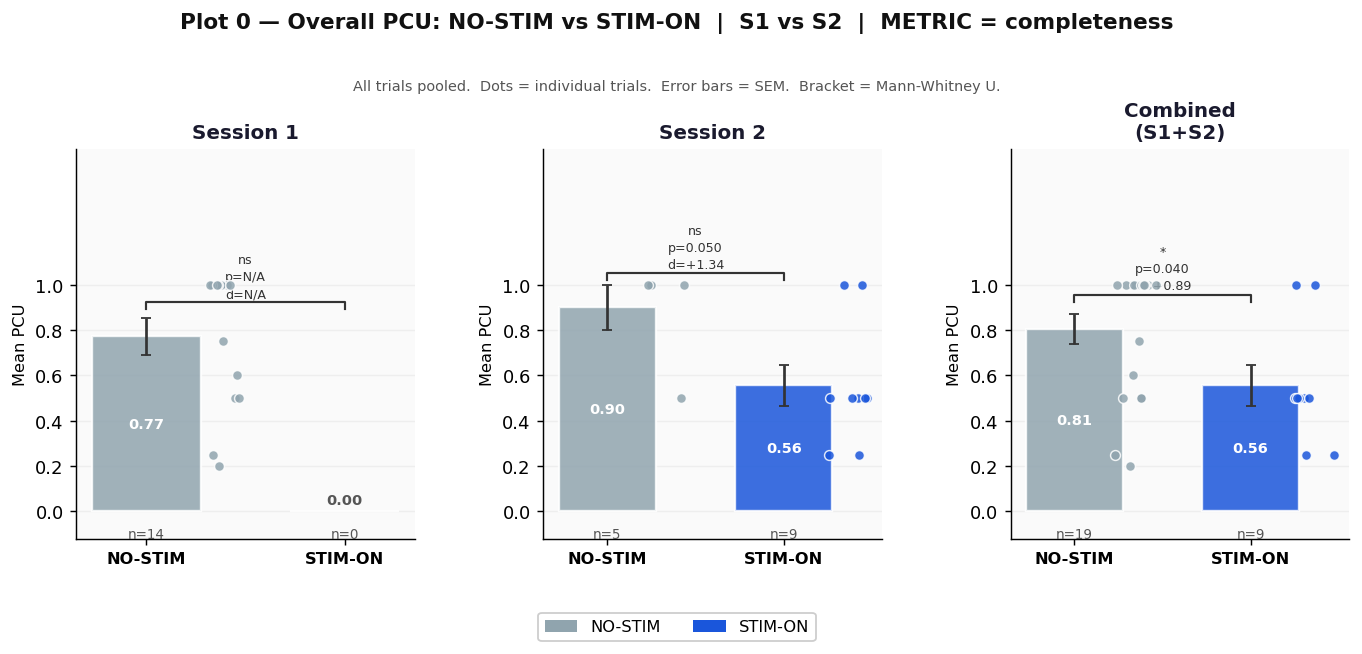

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1 v 2\PCU Analysis\plot0_pcu_overall_completeness.png


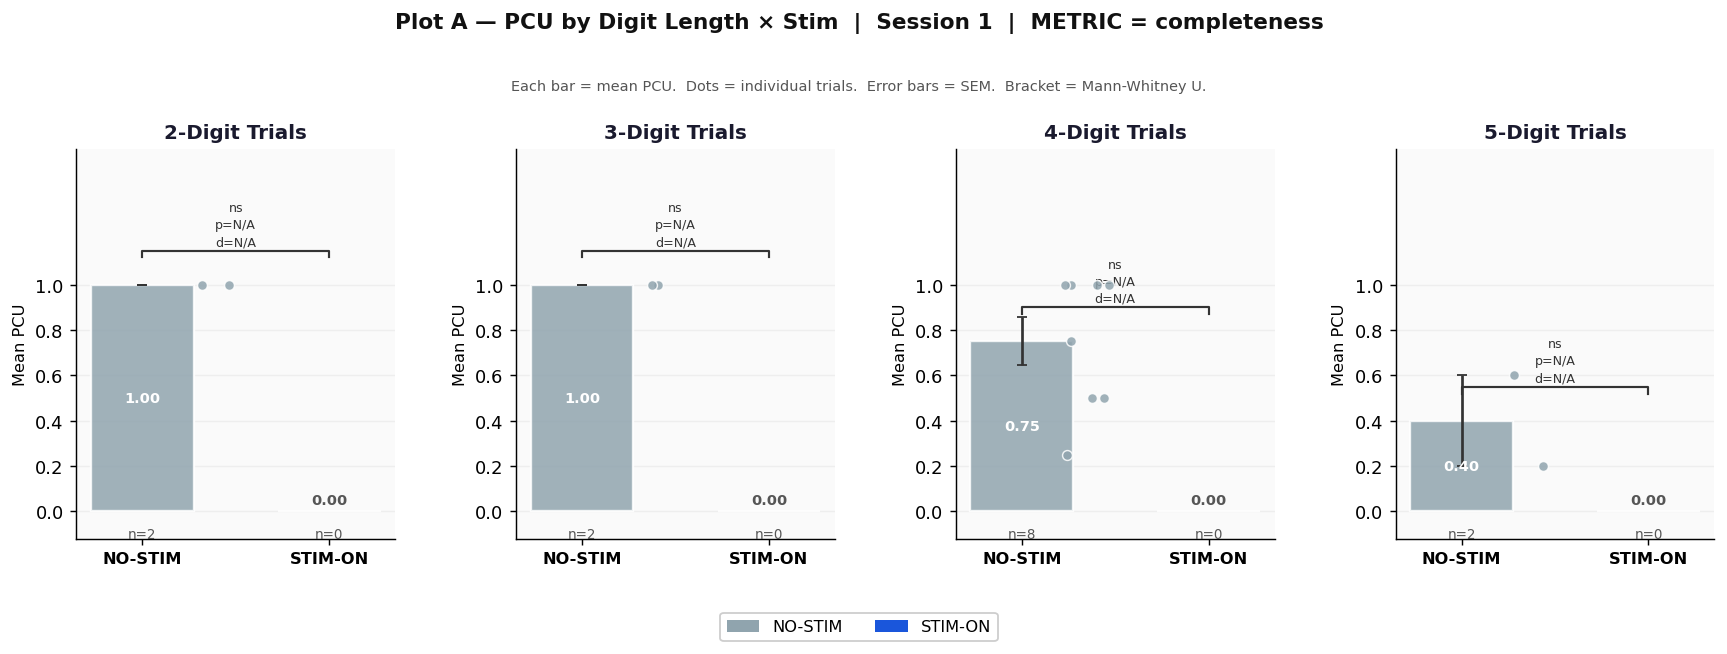

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1 v 2\PCU Analysis\plotA_pcu_by_digits_Session_1_completeness.png


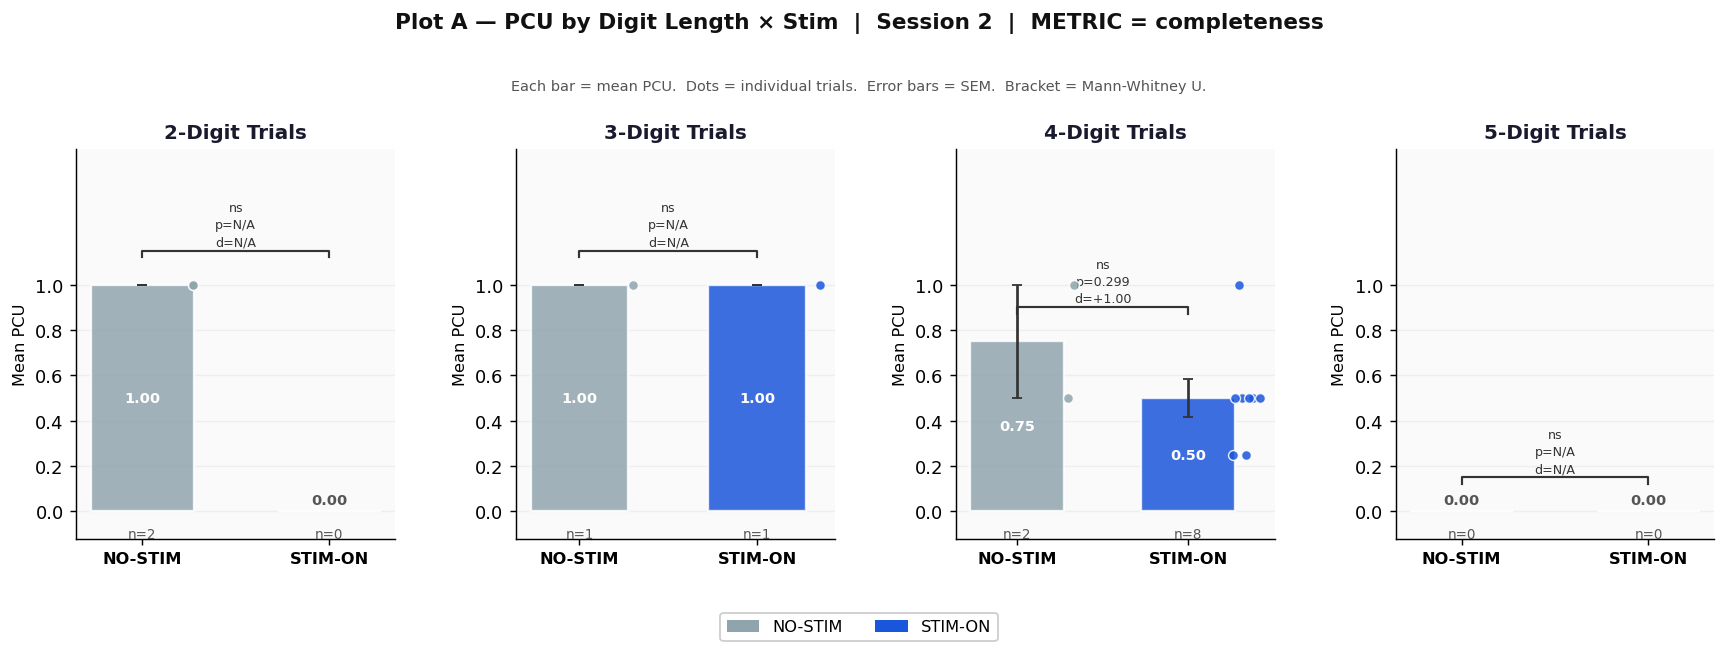

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1 v 2\PCU Analysis\plotA_pcu_by_digits_Session_2_completeness.png


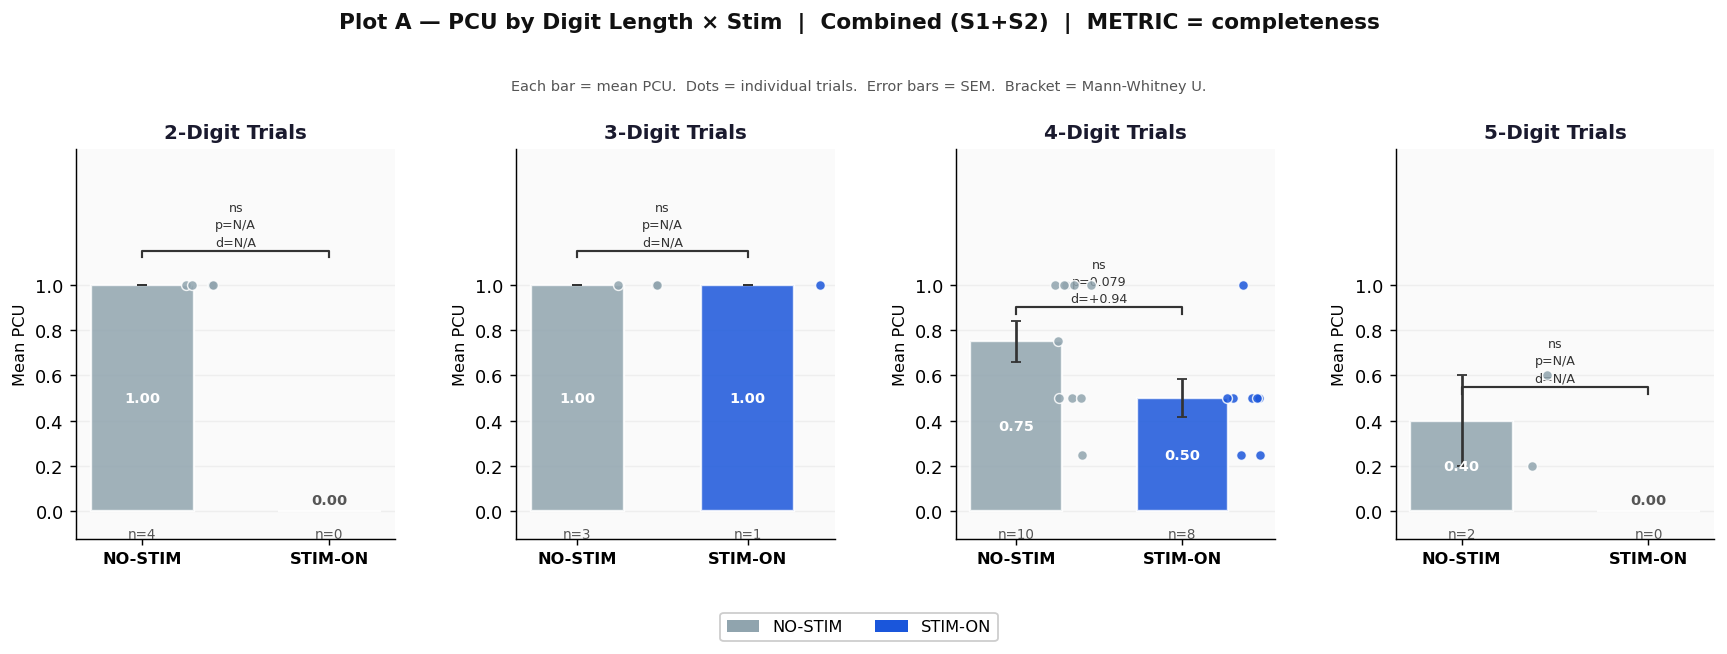

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1 v 2\PCU Analysis\plotA_pcu_by_digits_Combined_S1S2_completeness.png


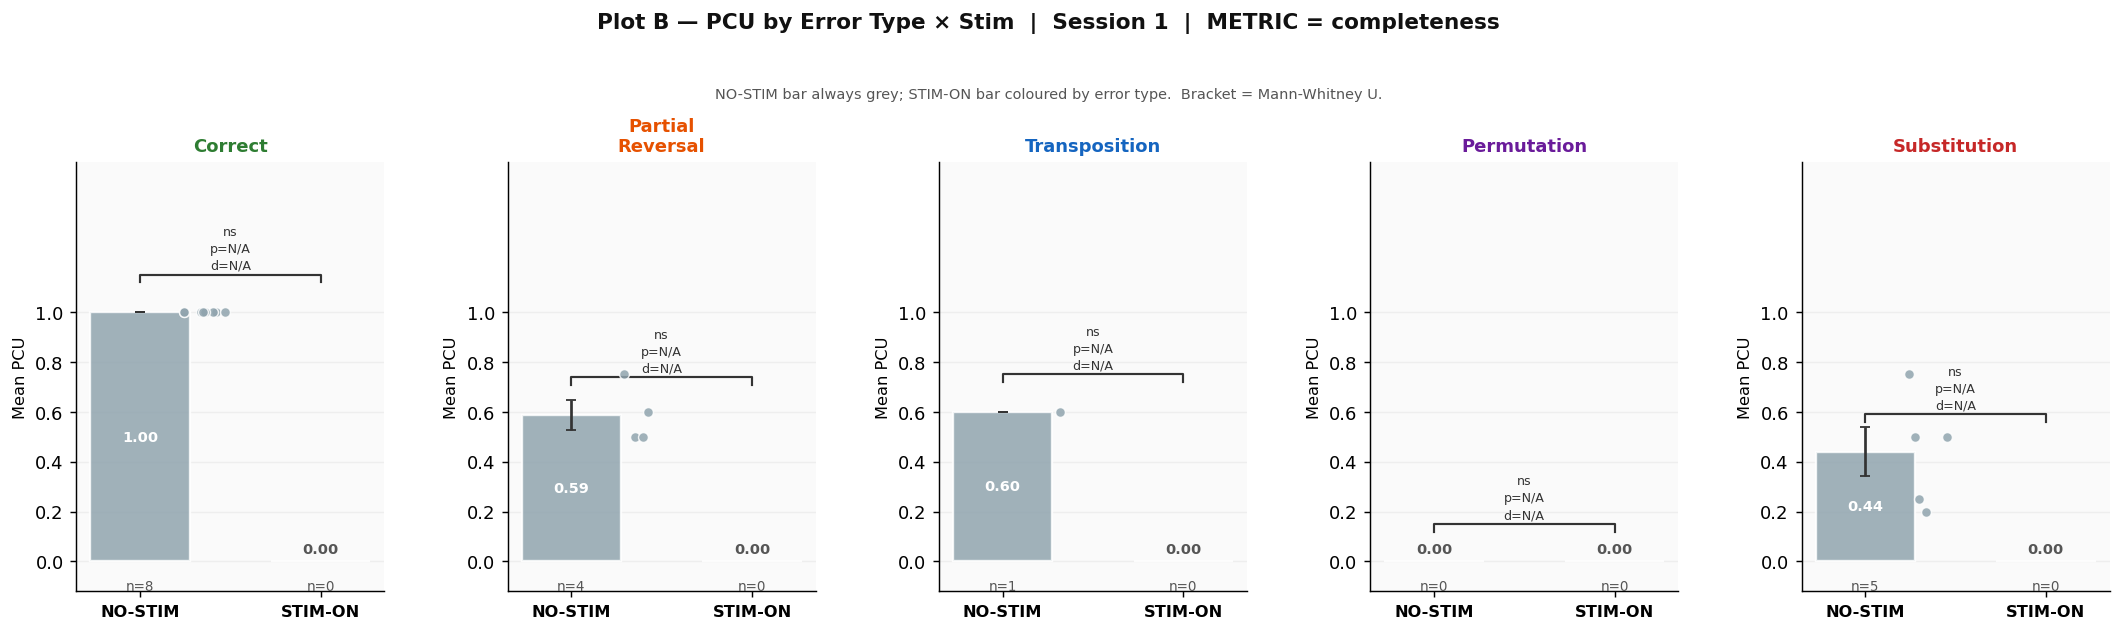

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1 v 2\PCU Analysis\plotB_pcu_by_errortype_Session_1_completeness.png


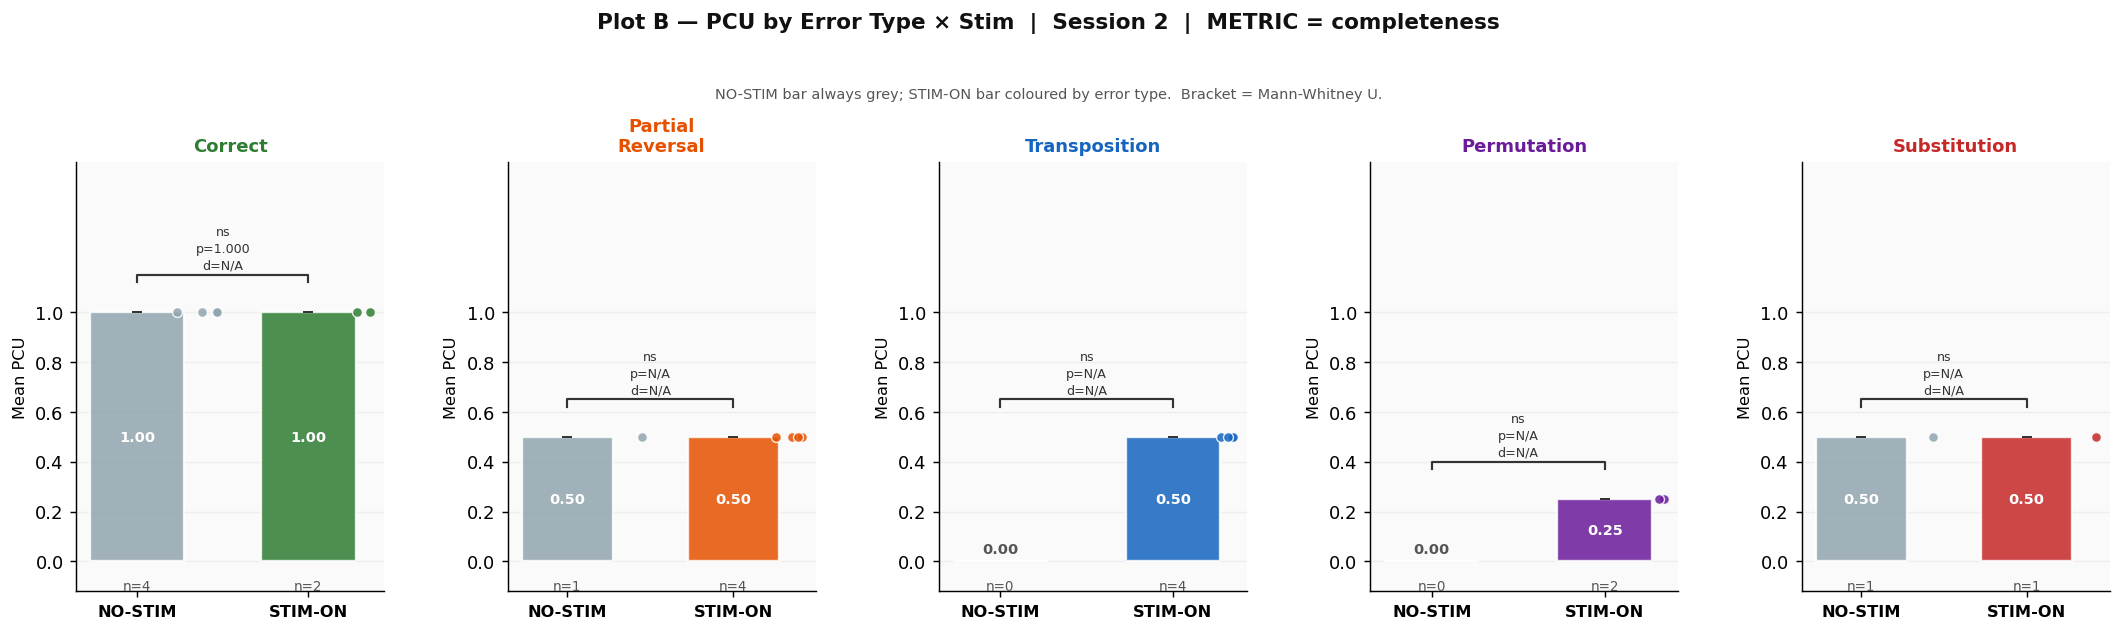

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1 v 2\PCU Analysis\plotB_pcu_by_errortype_Session_2_completeness.png


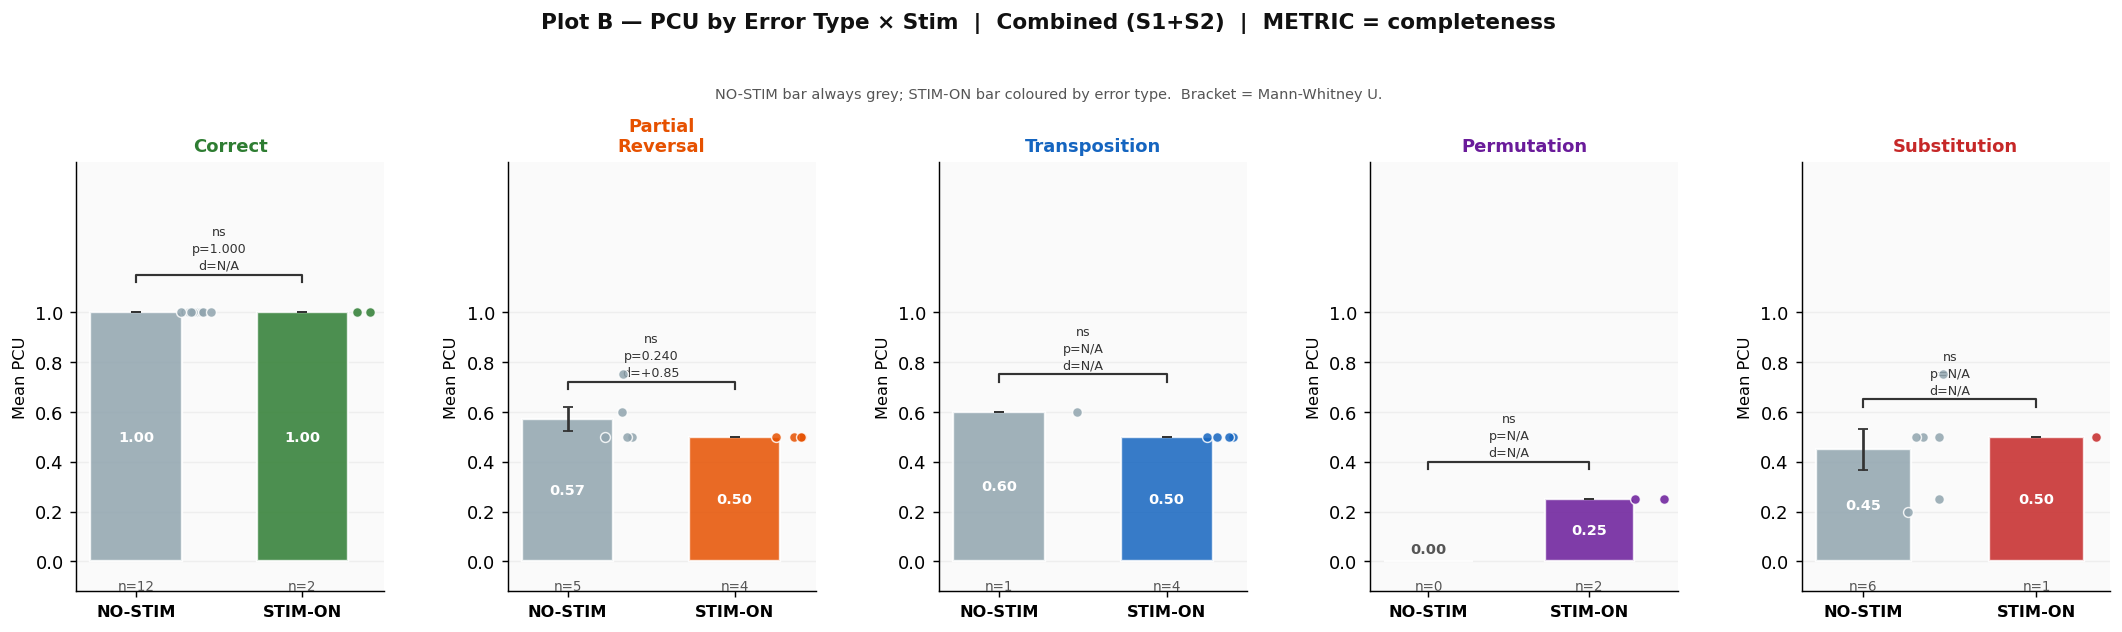

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1 v 2\PCU Analysis\plotB_pcu_by_errortype_Combined_S1S2_completeness.png


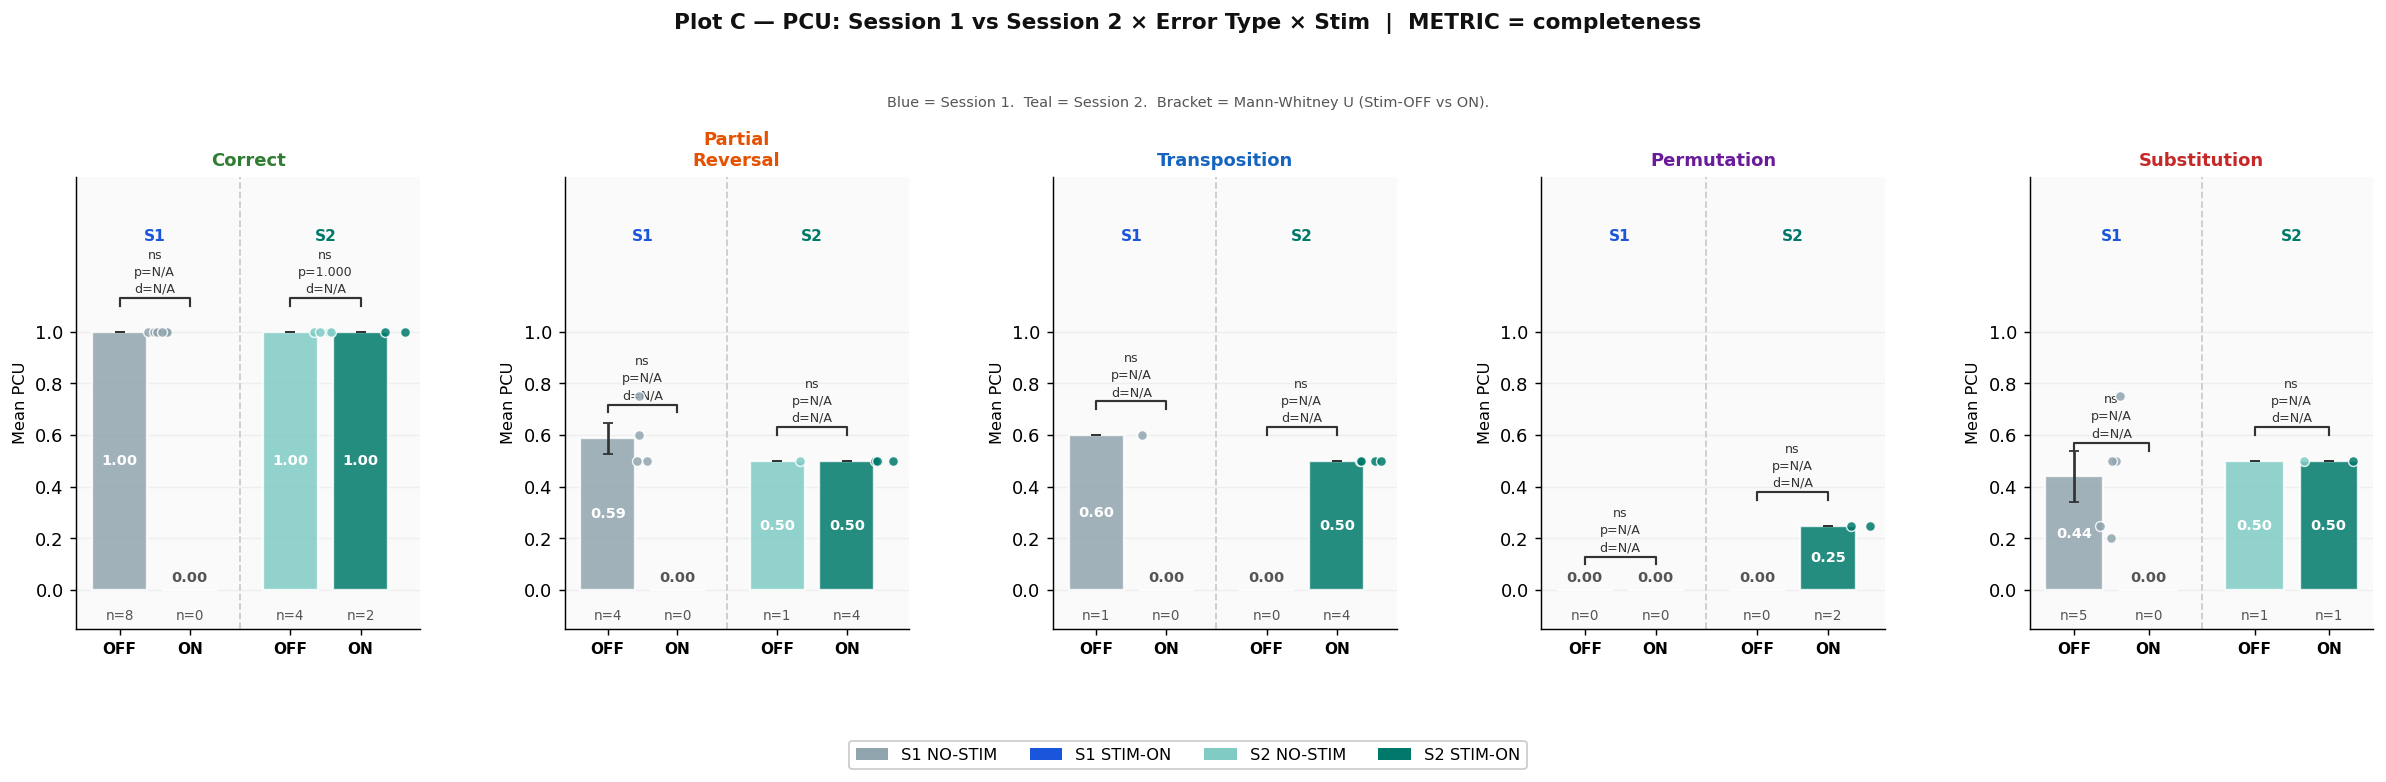

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1 v 2\PCU Analysis\plotC_pcu_s1_vs_s2_by_errortype_completeness.png


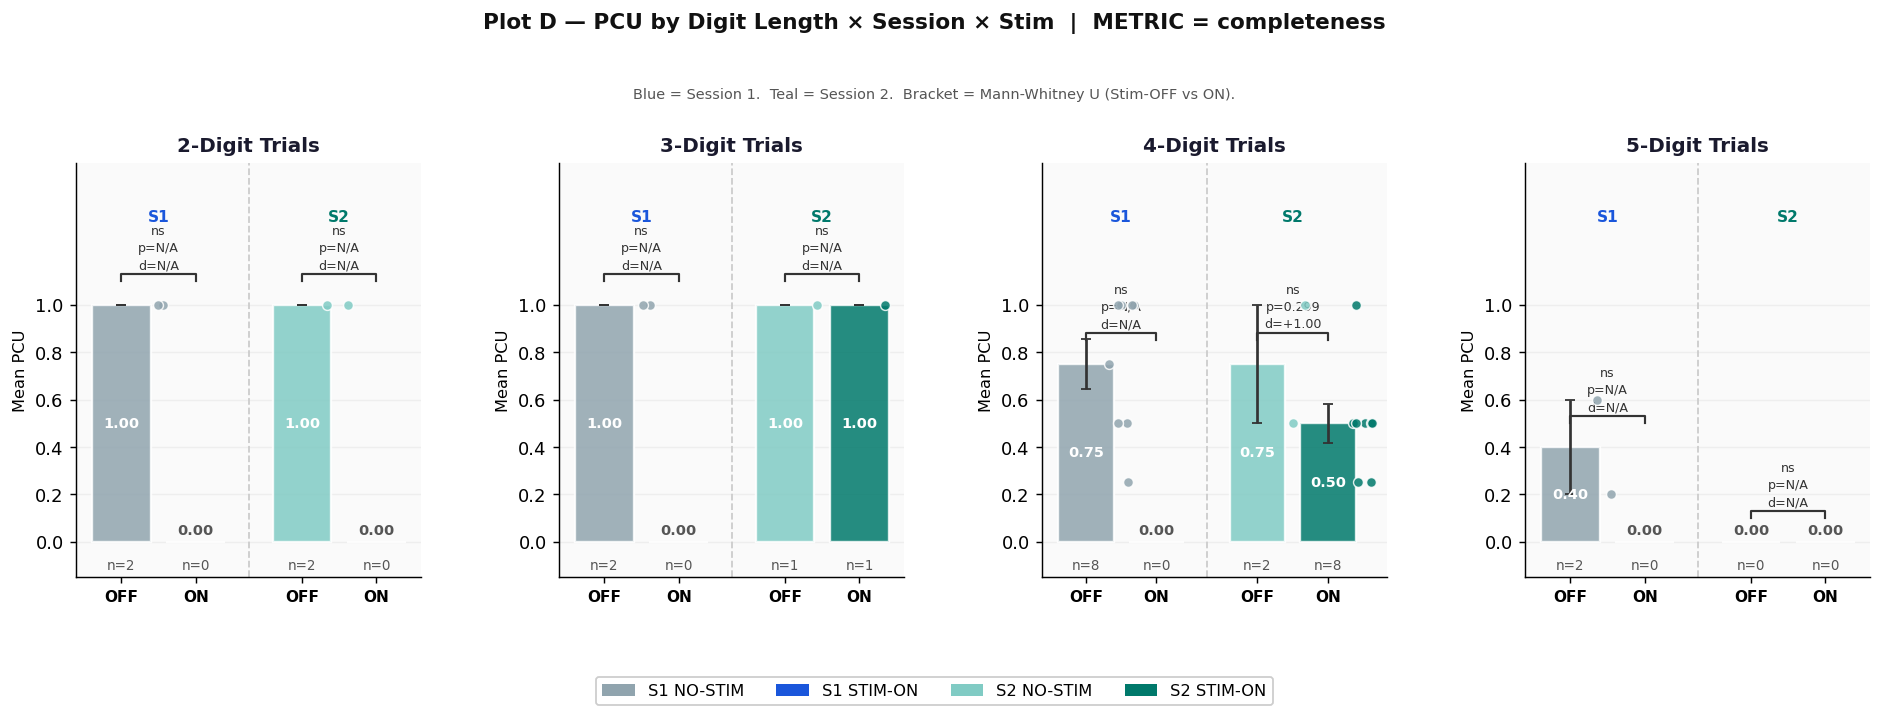

Saved -> C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1 v 2\PCU Analysis\plotD_pcu_by_digits_s1_vs_s2_completeness.png

  PCU METRIC SUMMARY TABLE  |  Session 1 vs Session 2
  Scope                  Filter                  OFF mean   ON mean  n_off   n_on        p stars   Cohen d
  ----------------------------------------------------------------------------------------
  Session 1              All trials                 0.771       nan     14      0      N/A   N/A       N/A
  Session 2              All trials                 0.900     0.556      5      9   0.0501    ns    +1.336
  Combined               All trials                 0.805     0.556     19      9   0.0401     *    +0.889

  Session 1              2-digit                    1.000       nan      2      0      N/A   N/A       N/A
  Session 2              2-digit                    1.000       nan      2      0      N/A   N/A       N/A
  Combined               2-digit                    1.000       nan      4      0      N/

In [229]:
# ══════════════════════════════════════════════════════════════════════════════
# SELF-CONTAINED: PCU Deep-Dive — Session 1 vs Session 2
# Conway et al. (2005) Partial-Credit Unit scoring
# ══════════════════════════════════════════════════════════════════════════════

import json
import math
import textwrap
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path

warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        130,
    'savefig.dpi':       160,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# ── Paths ─────────────────────────────────────────────────────────────────────
JSON_PATH_S1   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1426\Report_Json_Session_Report_20260305T151332.json")
CSV_PATH_S1    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-1-Scores.csv")
EVENTS_PATH_S1 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\Preprocessed Data\Events.csv")

JSON_PATH_S2   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json")
CSV_PATH_S2    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv")
EVENTS_PATH_S2 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv")

COMBINED_DIR   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1 v 2\PCU Analysis")
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants & colours ───────────────────────────────────────────────────────
STIM_THRESHOLD = 2.0
METRIC         = 'completeness'

C_NO_STIM = '#90A4AE'
C_STIM    = '#1A56DB'
S1_OFF_C  = '#90A4AE';  S1_ON_C = '#1A56DB'
S2_OFF_C  = '#80CBC4';  S2_ON_C = '#00796B'

# ── Generic helpers ───────────────────────────────────────────────────────────
def cohens_d(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt(((len(a)-1)*np.var(a, ddof=1) +
                      (len(b)-1)*np.var(b, ddof=1)) / (len(a)+len(b)-2))
    return float((np.mean(a) - np.mean(b)) / pooled) if pooled > 0 else np.nan

def sig_stars(p):
    if p is None or np.isnan(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def wrap_title(text, width=90):
    return '\n'.join(textwrap.wrap(text, width))

def save_fig(fig, path):
    fig.savefig(path, bbox_inches='tight', dpi=160, facecolor='white')
    plt.show()
    plt.close(fig)
    print(f'Saved -> {path}')

# ── Data loading ──────────────────────────────────────────────────────────────
def load_session_data(json_path, csv_path, events_path):
    with open(json_path) as f:
        report = json.load(f)
    eprime_df = pd.read_csv(csv_path,    encoding='utf-8-sig', low_memory=False)
    ev_df     = pd.read_csv(events_path, encoding='utf-8-sig', low_memory=False)

    meta = dict(
        subject=str(eprime_df['Subject'].iloc[0]),
        session=str(eprime_df['Session'].iloc[0]),
        date=str(eprime_df['SessionDate'].iloc[0]),
    )

    stim_tick = None
    for stream in report['BrainSenseLfp']:
        prev = None
        for pkt in stream['LfpData']:
            curr = pkt['Left']['mA']
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_tick = pkt['TicksInMs']
                break
            prev = curr
        if stim_tick:
            break
    assert stim_tick, 'No 0->+mA transition in BrainSenseLfp!'

    welcome_ms    = int(eprime_df['Welcome.TargetOnsetTime'].iloc[0])
    MANUAL_OFFSET = stim_tick - welcome_ms
    def to_rel(ms): return float(ms) + MANUAL_OFFSET - stim_tick

    ticks, mAs = [], []
    for stream in report['BrainSenseLfp']:
        for pkt in stream['LfpData']:
            ticks.append(pkt['TicksInMs'])
            mAs.append(pkt['Left']['mA'])
    ticks = np.array(ticks, dtype=float)
    mAs   = np.array(mAs,   dtype=float)
    order = np.argsort(ticks)
    ticks_rel = ticks[order] - stim_tick
    mAs       = mAs[order]

    print(f"Loaded: Subject={meta['subject']}  Session={meta['session']}  "
          f"mA_max={mAs.max():.2f}  N_packets={len(ticks)}")
    return report, eprime_df, ev_df, meta, to_rel, ticks_rel, mAs


def stim_frac_in_window(t0, t1, ticks_rel, mAs, threshold=2.0):
    if t0 is None or t1 is None or t1 <= t0:
        return 0.0
    mask = (ticks_rel >= t0) & (ticks_rel <= t1)
    t_r, t_m = ticks_rel[mask], mAs[mask]
    if len(t_r) < 2:
        return 0.0
    dt    = np.diff(t_r)
    mid   = (t_m[:-1] + t_m[1:]) / 2.0
    total = t_r[-1] - t_r[0]
    return float(np.sum(dt[mid >= threshold]) / total) if total > 0 else 0.0


def peak_mA(t0, t1, ticks_rel, mAs):
    if t0 is None or t1 is None or t1 <= t0:
        return 0.0
    mask = (ticks_rel >= t0) & (ticks_rel <= t1)
    if not mask.any():
        idx = int(np.argmin(np.abs(ticks_rel - (t0 + t1) / 2)))
        return float(mAs[idx])
    return float(mAs[mask].max())


def build_all_trials(eprime_df, ev_df, to_rel, ticks_rel, mAs, sess_label):
    def ev_all(etype, tn):
        return ev_df[(ev_df['Event_Type'] == etype) &
                     (ev_df['Trial_Number'] == tn)]['Time_ms'].tolist()
    def ev_first(etype, tn):
        v = ev_all(etype, tn)
        return v[0] if v else None

    trials = []
    for tn in range(1, 15):
        sr = ev_df[(ev_df['Event_Type'] == 'Main Trial Start') &
                   (ev_df['Trial_Number'] == tn)]
        if sr.empty:
            continue
        r = sr.iloc[0]

        acc     = int(r['ACC'])        if pd.notna(r['ACC'])        else None
        cresp_v = r['CRESP']           if pd.notna(r['CRESP'])      else None
        resp_v  = r['RESP']            if pd.notna(r['RESP'])       else None
        nd      = int(r['Num_Digits']) if pd.notna(r['Num_Digits']) else None
        if None in (acc, cresp_v, resp_v, nd):
            continue

        cresp_s   = str(int(cresp_v)).zfill(nd)
        resp_s    = str(int(resp_v)).zfill(nd)
        presented = cresp_s[::-1]

        t_start_ms  = ev_first('Main Trial Start', tn)
        t_end_ms    = ev_first('Main Trial End',   tn)
        t_start     = to_rel(t_start_ms) if t_start_ms else None
        t_end       = to_rel(t_end_ms)   if t_end_ms   else None

        fix_starts  = [to_rel(ms) for ms in ev_all('Fixation Start', tn)]
        stim_starts = [to_rel(ms) for ms in ev_all('Stimulus Start', tn)]
        stim_ends   = [to_rel(ms) for ms in ev_all('Stimulus End',   tn)]
        cs_ms = ev_first('Choice Start',   tn); cs = to_rel(cs_ms) if cs_ms else None
        ce_ms = ev_first('Choice End',     tn); ce = to_rel(ce_ms) if ce_ms else None
        fs_ms = ev_first('Feedback Start', tn); fs = to_rel(fs_ms) if fs_ms else None
        fe_ms = ev_first('Feedback End',   tn); fe = to_rel(fe_ms) if fe_ms else None

        trial_lo = fix_starts[0] if fix_starts else t_start
        trial_hi = fe if fe else t_end
        mask_full = (ticks_rel >= trial_lo) & (ticks_rel <= trial_hi)
        stim_present_condA = bool(mask_full.any() and np.any(mAs[mask_full] >= STIM_THRESHOLD))

        pre_fb_frac = 0.0
        if fix_starts and stim_starts:
            pre_fb_frac = max(pre_fb_frac,
                stim_frac_in_window(fix_starts[0], stim_starts[0], ticks_rel, mAs, STIM_THRESHOLD))
        if stim_starts and stim_ends:
            pre_fb_frac = max(pre_fb_frac,
                stim_frac_in_window(stim_starts[0], stim_ends[0], ticks_rel, mAs, STIM_THRESHOLD))
        if cs and ce:
            pre_fb_frac = max(pre_fb_frac,
                stim_frac_in_window(cs, ce, ticks_rel, mAs, STIM_THRESHOLD))
        fb_frac = stim_frac_in_window(fs, fe, ticks_rel, mAs, STIM_THRESHOLD) if fs and fe else 0.0

        feedback_only_stim = stim_present_condA and (pre_fb_frac < 0.3) and (fb_frac >= 0.3)
        stim_present_condB = stim_present_condA and not feedback_only_stim

        whole_peak = peak_mA(trial_lo, trial_hi, ticks_rel, mAs)

        trials.append(dict(
            session            = sess_label,
            trial_num          = tn,
            digits             = nd,
            acc                = acc,
            presented          = presented,
            cresp              = cresp_s,
            resp               = resp_s,
            stim_present       = stim_present_condA,
            stim_present_condB = stim_present_condB,
            feedback_only_stim = feedback_only_stim,
            whole_peak_mA      = round(whole_peak, 3),
        ))
    return trials

# ── Load sessions ─────────────────────────────────────────────────────────────
_, ep_s1, ev_s1, meta_s1, to_rel_s1, tr_s1, mA_s1 = load_session_data(
    JSON_PATH_S1, CSV_PATH_S1, EVENTS_PATH_S1)
_, ep_s2, ev_s2, meta_s2, to_rel_s2, tr_s2, mA_s2 = load_session_data(
    JSON_PATH_S2, CSV_PATH_S2, EVENTS_PATH_S2)

# ── PCU computation ───────────────────────────────────────────────────────────
def compute_pcu(presented, resp):
    presented = str(presented).strip()
    resp      = str(resp).strip()
    n = len(presented)
    if n == 0:
        return 0.0
    cresp = presented[::-1]
    hits  = sum(1 for i in range(n) if i < len(resp) and resp[i] == cresp[i])
    return hits / n

# ── Multi-label error classification ─────────────────────────────────────────
def classify_error_multilabel(presented, resp):
    presented = str(presented).strip()
    resp      = str(resp).strip()
    n = len(presented)
    if n == 0:
        return ['OTHER']
    cresp  = presented[::-1]
    labels = []

    # SUBSTITUTION — foreign digit present
    if sorted(resp) != sorted(presented):
        labels.append('SUBSTITUTION')

    # PARTIAL REVERSAL — last 2 of presented reversed start the response
    if n >= 2:
        last2_reversed = presented[n-1] + presented[n-2]
        if resp[:2] == last2_reversed:
            labels.append('PARTIAL_REVERSAL')

    # TRANSPOSITION — exactly 2 adjacent positions differ from cresp,
    #                 swapping them recovers cresp
    diffs = [i for i in range(n) if i < len(resp) and resp[i] != cresp[i]]
    if len(diffs) == 2:
        i, j = diffs
        if abs(i - j) == 1:
            swapped = list(resp)
            swapped[i], swapped[j] = swapped[j], swapped[i]
            if ''.join(swapped) == cresp:
                labels.append('TRANSPOSITION')

    # PERMUTATION — same multiset, no other label matched
    if sorted(resp) == sorted(presented):
        if 'PARTIAL_REVERSAL' not in labels and 'TRANSPOSITION' not in labels:
            labels.append('PERMUTATION')

    if not labels:
        labels.append('OTHER')
    return labels


def annotate_trials_detailed(trials):
    for t in trials:
        t['pcu'] = compute_pcu(t.get('presented', ''), t.get('resp', ''))
        if t['acc'] == 1:
            t['error_labels'] = ['CORRECT']
        else:
            t['error_labels'] = classify_error_multilabel(
                t.get('presented', ''), t.get('resp', ''))

all_s1 = build_all_trials(ep_s1, ev_s1, to_rel_s1, tr_s1, mA_s1, 'Session 1')
annotate_trials_detailed(all_s1)
all_s2 = build_all_trials(ep_s2, ev_s2, to_rel_s2, tr_s2, mA_s2, 'Session 2')
annotate_trials_detailed(all_s2)
all_combined = all_s1 + all_s2

print('\nPCU + multi-label error types annotated.')
for sess_label, trials in [('S1', all_s1), ('S2', all_s2)]:
    print(f'{sess_label} error breakdown:')
    for k in ['CORRECT','SUBSTITUTION','TRANSPOSITION','PARTIAL_REVERSAL','PERMUTATION','OTHER']:
        print(f'  {k}: {sum(1 for t in trials if k in t["error_labels"])}')

# ── Shared plot helpers ───────────────────────────────────────────────────────
def mean_pcu_list(vals):
    return np.mean(vals) if vals else np.nan

def safe_sem(vals):
    return stats.sem(vals) if len(vals) > 1 else 0.0

def pcu_stat(off_vals, on_vals):
    if len(off_vals) < 2 or len(on_vals) < 2:
        return np.nan, 'n<2', np.nan
    u, p = stats.mannwhitneyu(off_vals, on_vals, alternative='two-sided')
    d = cohens_d(np.array(off_vals), np.array(on_vals))
    return float(p), 'Mann-Whitney U', d

def draw_bracket(ax, x1, x2, y, p, d):
    stars = sig_stars(p)
    if stars == '': stars = 'ns'
    h = 0.03
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='#333')
    p_str = f'p={p:.3f}' if (not np.isnan(p) and p >= 0.001) else ('p<0.001' if not np.isnan(p) else 'p=N/A')
    d_str = f'd={d:+.2f}' if not np.isnan(d) else 'd=N/A'
    ax.text((x1+x2)/2, y+h+0.01, f'{stars}\n{p_str}\n{d_str}',
            ha='center', va='bottom', fontsize=7.0, color='#333', linespacing=1.4)

def bar_with_dots(ax, xi, vals, color, label=None):
    m     = mean_pcu_list(vals)
    sem   = safe_sem(vals) if vals else 0.0
    bar_h = m if not np.isnan(m) else 0
    ax.bar(xi, bar_h, width=0.55, color=color, edgecolor='white',
           linewidth=1.3, zorder=3, label=label, alpha=0.85)
    if vals:
        jit = (np.random.rand(len(vals)) - 0.5) * 0.25
        ax.scatter(np.full(len(vals), xi) + jit + 0.35, vals,
                   s=30, color=color, edgecolor='white',
                   linewidth=0.8, alpha=0.85, zorder=5)
        ax.errorbar(xi, m, yerr=sem, fmt='none',
                    ecolor='#333', elinewidth=1.5, capsize=3, zorder=6)
    if not np.isnan(bar_h) and bar_h > 0.05:
        ax.text(xi, bar_h/2, f'{bar_h:.2f}',
                ha='center', va='center', fontsize=8.0,
                fontweight='bold', color='white', zorder=7)
    else:
        ax.text(xi, 0.02, f'{bar_h:.2f}' if not np.isnan(bar_h) else '0.00',
                ha='center', va='bottom', fontsize=8.0,
                fontweight='bold', color='#555', zorder=7)
    ax.text(xi, -0.07, f'n={len(vals)}',
            ha='center', va='top', fontsize=7.5, color='#555')
    return m

# ── Error type config ─────────────────────────────────────────────────────────
ERROR_TYPES  = ['CORRECT', 'PARTIAL_REVERSAL', 'TRANSPOSITION', 'PERMUTATION', 'SUBSTITUTION']
ERROR_COLORS = {'CORRECT':          '#2E7D32',
                'PARTIAL_REVERSAL': '#E65100',
                'TRANSPOSITION':    '#1565C0',
                'PERMUTATION':      '#6A1B9A',
                'SUBSTITUTION':     '#C62828'}
ERROR_LABELS = {'CORRECT':          'Correct',
                'PARTIAL_REVERSAL': 'Partial\nReversal',
                'TRANSPOSITION':    'Transposition',
                'PERMUTATION':      'Permutation',
                'SUBSTITUTION':     'Substitution'}

DIGIT_LENGTHS = [2, 3, 4, 5]
X_POSITIONS   = [0, 0.7, 1.7, 2.4]   # S1-OFF  S1-ON  |gap|  S2-OFF  S2-ON

sessions_info = [
    ('Session 1',        all_s1,       14),
    ('Session 2',        all_s2,       14),
    ('Combined (S1+S2)', all_combined, 28),
]

# ════════════════════════════════════════════════════════════════════════════
# PLOT 0 — Overall PCU: NO-STIM vs STIM-ON  (S1 / S2 / Combined)
# ════════════════════════════════════════════════════════════════════════════
np.random.seed(0)
fig, axes = plt.subplots(1, 3, figsize=(11, 5), facecolor='white')
fig.subplots_adjust(wspace=0.38, top=0.78, bottom=0.18, left=0.08, right=0.97)

for ax, (scope_label, trials) in zip(axes, [('Session 1',        all_s1),
                                              ('Session 2',        all_s2),
                                              ('Combined\n(S1+S2)', all_combined)]):
    off_v = [t['pcu'] for t in trials if not t['stim_present_condB']]
    on_v  = [t['pcu'] for t in trials if     t['stim_present_condB']]
    bar_with_dots(ax, 0, off_v, C_NO_STIM)
    bar_with_dots(ax, 1, on_v,  C_STIM)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['NO-STIM', 'STIM-ON'], fontsize=9, fontweight='bold')
    ax.set_ylim(-0.12, 1.60); ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_ylabel('Mean PCU', fontsize=9)
    ax.yaxis.grid(True, color='#eee', zorder=0); ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    ax.set_title(scope_label, fontsize=11, fontweight='bold', color='#1A1A2E', pad=6)
    p, _, d_val = pcu_stat(off_v, on_v)
    top_y = np.nanmax([mean_pcu_list(off_v) if off_v else 0.0,
                       mean_pcu_list(on_v)  if on_v  else 0.0])
    draw_bracket(ax, 0, 1, top_y + 0.12, p, d_val)

fig.suptitle(wrap_title(f'Plot 0 — Overall PCU: NO-STIM vs STIM-ON  |  S1 vs S2  |  METRIC = {METRIC}', 90),
             fontsize=12, fontweight='bold', color='#111', y=0.99)
fig.text(0.5, 0.87, 'All trials pooled.  Dots = individual trials.  Error bars = SEM.  Bracket = Mann-Whitney U.',
         ha='center', fontsize=8, color='#555')
fig.legend(handles=[mpatches.Patch(facecolor=C_NO_STIM, label='NO-STIM'),
                    mpatches.Patch(facecolor=C_STIM,    label='STIM-ON')],
           loc='lower center', ncol=2, fontsize=9, framealpha=0.97,
           facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))
save_fig(fig, COMBINED_DIR / f'plot0_pcu_overall_{METRIC}.png')


# ════════════════════════════════════════════════════════════════════════════
# PLOT A — PCU by Digit Length × Stim × Session
# ════════════════════════════════════════════════════════════════════════════
np.random.seed(42)
for sess_label, trials, _ in sessions_info:
    fig, axes = plt.subplots(1, len(DIGIT_LENGTHS), figsize=(14, 5), facecolor='white')
    fig.subplots_adjust(wspace=0.38, top=0.78, bottom=0.18, left=0.07, right=0.97)
    for ax, d in zip(axes, DIGIT_LENGTHS):
        bucket = [t for t in trials if t['digits'] == d]
        off_v = [t['pcu'] for t in bucket if not t['stim_present_condB']]
        on_v  = [t['pcu'] for t in bucket if     t['stim_present_condB']]
        bar_with_dots(ax, 0, off_v, C_NO_STIM)
        bar_with_dots(ax, 1, on_v,  C_STIM)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['NO-STIM', 'STIM-ON'], fontsize=9, fontweight='bold')
        ax.set_ylim(-0.12, 1.60); ax.set_yticks(np.arange(0, 1.01, 0.2))
        ax.set_ylabel('Mean PCU', fontsize=9)
        ax.yaxis.grid(True, color='#eee', zorder=0); ax.set_axisbelow(True)
        ax.set_facecolor('#FAFAFA')
        ax.set_title(f'{d}-Digit Trials', fontsize=11, fontweight='bold', color='#1A1A2E', pad=6)
        p, _, d_val = pcu_stat(off_v, on_v)
        top_y = np.nanmax([mean_pcu_list(off_v) if off_v else 0.0,
                           mean_pcu_list(on_v)  if on_v  else 0.0])
        draw_bracket(ax, 0, 1, top_y + 0.12, p, d_val)
    fig.suptitle(wrap_title(f'Plot A — PCU by Digit Length × Stim  |  {sess_label}  |  METRIC = {METRIC}', 100),
                 fontsize=12, fontweight='bold', color='#111', y=0.99)
    fig.text(0.5, 0.87, 'Each bar = mean PCU.  Dots = individual trials.  Error bars = SEM.  Bracket = Mann-Whitney U.',
             ha='center', fontsize=8, color='#555')
    fig.legend(handles=[mpatches.Patch(facecolor=C_NO_STIM, label='NO-STIM'),
                        mpatches.Patch(facecolor=C_STIM,    label='STIM-ON')],
               loc='lower center', ncol=2, fontsize=9, framealpha=0.97,
               facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))
    slug = sess_label.replace(' ', '_').replace('(', '').replace(')', '').replace('+', '')
    save_fig(fig, COMBINED_DIR / f'plotA_pcu_by_digits_{slug}_{METRIC}.png')


# ════════════════════════════════════════════════════════════════════════════
# PLOT B — PCU by Error Type × Stim × Session
# ════════════════════════════════════════════════════════════════════════════
np.random.seed(7)
for sess_label, trials, _ in sessions_info:
    fig, axes = plt.subplots(1, len(ERROR_TYPES), figsize=(17, 5.5), facecolor='white')
    fig.subplots_adjust(wspace=0.40, top=0.78, bottom=0.18, left=0.06, right=0.98)
    for ax, etype in zip(axes, ERROR_TYPES):
        col    = ERROR_COLORS[etype]
        bucket = [t for t in trials if etype in t['error_labels']]
        off_v  = [t['pcu'] for t in bucket if not t['stim_present_condB']]
        on_v   = [t['pcu'] for t in bucket if     t['stim_present_condB']]
        bar_with_dots(ax, 0, off_v, C_NO_STIM)
        bar_with_dots(ax, 1, on_v,  col)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['NO-STIM', 'STIM-ON'], fontsize=9, fontweight='bold')
        ax.set_ylim(-0.12, 1.60); ax.set_yticks(np.arange(0, 1.01, 0.2))
        ax.set_ylabel('Mean PCU', fontsize=9)
        ax.yaxis.grid(True, color='#eee', zorder=0); ax.set_axisbelow(True)
        ax.set_facecolor('#FAFAFA')
        ax.set_title(ERROR_LABELS[etype], fontsize=10, fontweight='bold', color=col, pad=6)
        p, _, d_val = pcu_stat(off_v, on_v)
        top_y = np.nanmax([mean_pcu_list(off_v) if off_v else 0.0,
                           mean_pcu_list(on_v)  if on_v  else 0.0])
        draw_bracket(ax, 0, 1, top_y + 0.12, p, d_val)
    fig.suptitle(wrap_title(f'Plot B — PCU by Error Type × Stim  |  {sess_label}  |  METRIC = {METRIC}', 110),
                 fontsize=12, fontweight='bold', color='#111', y=0.99)
    fig.text(0.5, 0.87, 'NO-STIM bar always grey; STIM-ON bar coloured by error type.  Bracket = Mann-Whitney U.',
             ha='center', fontsize=8, color='#555')
    slug = sess_label.replace(' ', '_').replace('(', '').replace(')', '').replace('+', '')
    save_fig(fig, COMBINED_DIR / f'plotB_pcu_by_errortype_{slug}_{METRIC}.png')


# ════════════════════════════════════════════════════════════════════════════
# PLOT C — Session 1 vs Session 2 × Error Type × Stim
# ════════════════════════════════════════════════════════════════════════════
np.random.seed(13)
fig, axes = plt.subplots(1, len(ERROR_TYPES), figsize=(19, 6), facecolor='white')
fig.subplots_adjust(wspace=0.42, top=0.78, bottom=0.20, left=0.05, right=0.98)

for ax, etype in zip(axes, ERROR_TYPES):
    col = ERROR_COLORS[etype]
    s1_off = [t['pcu'] for t in all_s1 if etype in t['error_labels'] and not t['stim_present_condB']]
    s1_on  = [t['pcu'] for t in all_s1 if etype in t['error_labels'] and     t['stim_present_condB']]
    s2_off = [t['pcu'] for t in all_s2 if etype in t['error_labels'] and not t['stim_present_condB']]
    s2_on  = [t['pcu'] for t in all_s2 if etype in t['error_labels'] and     t['stim_present_condB']]
    for xi, (vals, c) in zip(X_POSITIONS, [(s1_off, S1_OFF_C), (s1_on, S1_ON_C),
                                            (s2_off, S2_OFF_C), (s2_on, S2_ON_C)]):
        bar_with_dots(ax, xi, vals, c)
    ax.axvline(x=1.2, color='#ccc', linewidth=1.0, linestyle='--', zorder=1)
    ax.text(0.35, 1.35, 'S1', ha='center', fontsize=8.5, fontweight='bold', color=S1_ON_C)
    ax.text(2.05, 1.35, 'S2', ha='center', fontsize=8.5, fontweight='bold', color=S2_ON_C)
    for x1, x2, va, vb in [(0, 0.7, s1_off, s1_on), (1.7, 2.4, s2_off, s2_on)]:
        p, _, d_val = pcu_stat(va, vb)
        top_y = np.nanmax([mean_pcu_list(va) if va else 0.0,
                           mean_pcu_list(vb) if vb else 0.0])
        draw_bracket(ax, x1, x2, top_y + 0.10, p, d_val)
    ax.set_xticks(X_POSITIONS); ax.set_xticklabels(['OFF', 'ON', 'OFF', 'ON'], fontsize=8.5, fontweight='bold')
    ax.set_ylim(-0.15, 1.60); ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_ylabel('Mean PCU', fontsize=9)
    ax.yaxis.grid(True, color='#eee', zorder=0); ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    ax.set_title(ERROR_LABELS[etype], fontsize=10, fontweight='bold', color=col, pad=6)

fig.suptitle(wrap_title(f'Plot C — PCU: Session 1 vs Session 2 × Error Type × Stim  |  METRIC = {METRIC}', 110),
             fontsize=12, fontweight='bold', color='#111', y=0.99)
fig.text(0.5, 0.87, 'Blue = Session 1.  Teal = Session 2.  Bracket = Mann-Whitney U (Stim-OFF vs ON).',
         ha='center', fontsize=8, color='#555')
fig.legend(handles=[mpatches.Patch(facecolor=S1_OFF_C, label='S1 NO-STIM'),
                    mpatches.Patch(facecolor=S1_ON_C,  label='S1 STIM-ON'),
                    mpatches.Patch(facecolor=S2_OFF_C, label='S2 NO-STIM'),
                    mpatches.Patch(facecolor=S2_ON_C,  label='S2 STIM-ON')],
           loc='lower center', ncol=4, fontsize=9, framealpha=0.97,
           facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))
save_fig(fig, COMBINED_DIR / f'plotC_pcu_s1_vs_s2_by_errortype_{METRIC}.png')


# ════════════════════════════════════════════════════════════════════════════
# PLOT D — PCU by Digit Length × Session × Stim
# ════════════════════════════════════════════════════════════════════════════
np.random.seed(99)
fig, axes = plt.subplots(1, len(DIGIT_LENGTHS), figsize=(15, 5.5), facecolor='white')
fig.subplots_adjust(wspace=0.40, top=0.78, bottom=0.20, left=0.06, right=0.98)

for ax, d in zip(axes, DIGIT_LENGTHS):
    s1_off = [t['pcu'] for t in all_s1 if t['digits'] == d and not t['stim_present_condB']]
    s1_on  = [t['pcu'] for t in all_s1 if t['digits'] == d and     t['stim_present_condB']]
    s2_off = [t['pcu'] for t in all_s2 if t['digits'] == d and not t['stim_present_condB']]
    s2_on  = [t['pcu'] for t in all_s2 if t['digits'] == d and     t['stim_present_condB']]
    for xi, (vals, c) in zip(X_POSITIONS, [(s1_off, S1_OFF_C), (s1_on, S1_ON_C),
                                            (s2_off, S2_OFF_C), (s2_on, S2_ON_C)]):
        bar_with_dots(ax, xi, vals, c)
    ax.axvline(x=1.2, color='#ccc', linewidth=1.0, linestyle='--', zorder=1)
    ax.text(0.35, 1.35, 'S1', ha='center', fontsize=8.5, fontweight='bold', color=S1_ON_C)
    ax.text(2.05, 1.35, 'S2', ha='center', fontsize=8.5, fontweight='bold', color=S2_ON_C)
    for x1, x2, va, vb in [(0, 0.7, s1_off, s1_on), (1.7, 2.4, s2_off, s2_on)]:
        p, _, d_val = pcu_stat(va, vb)
        top_y = np.nanmax([mean_pcu_list(va) if va else 0.0,
                           mean_pcu_list(vb) if vb else 0.0])
        draw_bracket(ax, x1, x2, top_y + 0.10, p, d_val)
    ax.set_xticks(X_POSITIONS); ax.set_xticklabels(['OFF', 'ON', 'OFF', 'ON'], fontsize=8.5, fontweight='bold')
    ax.set_ylim(-0.15, 1.60); ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_ylabel('Mean PCU', fontsize=9)
    ax.yaxis.grid(True, color='#eee', zorder=0); ax.set_axisbelow(True)
    ax.set_facecolor('#FAFAFA')
    ax.set_title(f'{d}-Digit Trials', fontsize=11, fontweight='bold', color='#1A1A2E', pad=6)

fig.suptitle(wrap_title(f'Plot D — PCU by Digit Length × Session × Stim  |  METRIC = {METRIC}', 100),
             fontsize=12, fontweight='bold', color='#111', y=0.99)
fig.text(0.5, 0.87, 'Blue = Session 1.  Teal = Session 2.  Bracket = Mann-Whitney U (Stim-OFF vs ON).',
         ha='center', fontsize=8, color='#555')
fig.legend(handles=[mpatches.Patch(facecolor=S1_OFF_C, label='S1 NO-STIM'),
                    mpatches.Patch(facecolor=S1_ON_C,  label='S1 STIM-ON'),
                    mpatches.Patch(facecolor=S2_OFF_C, label='S2 NO-STIM'),
                    mpatches.Patch(facecolor=S2_ON_C,  label='S2 STIM-ON')],
           loc='lower center', ncol=4, fontsize=9, framealpha=0.97,
           facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))
save_fig(fig, COMBINED_DIR / f'plotD_pcu_by_digits_s1_vs_s2_{METRIC}.png')


# ════════════════════════════════════════════════════════════════════════════
# PRINT — Summary table
# ════════════════════════════════════════════════════════════════════════════
print('\n' + '='*90)
print('  PCU METRIC SUMMARY TABLE  |  Session 1 vs Session 2')
print('='*90)
print(f'  {"Scope":<22} {"Filter":<22} {"OFF mean":>9} {"ON mean":>9} '
      f'{"n_off":>6} {"n_on":>6} {"p":>8} {"stars":>5} {"Cohen d":>9}')
print('  ' + '-'*88)

def summary_row(scope, filter_label, off_vals, on_vals):
    m_off = mean_pcu_list(off_vals)
    m_on  = mean_pcu_list(on_vals)
    p, _, d = pcu_stat(off_vals, on_vals)
    stars = sig_stars(p) if not np.isnan(p) else 'N/A'
    p_s   = f'{p:.4f}' if not np.isnan(p) else '   N/A'
    d_s   = f'{d:+.3f}' if not np.isnan(d) else '   N/A'
    print(f'  {scope:<22} {filter_label:<22} {m_off:>9.3f} {m_on:>9.3f} '
          f'{len(off_vals):>6} {len(on_vals):>6} {p_s:>8} {stars:>5} {d_s:>9}')

for sess_label, trials in [('Session 1', all_s1), ('Session 2', all_s2), ('Combined', all_combined)]:
    off_v = [t['pcu'] for t in trials if not t['stim_present_condB']]
    on_v  = [t['pcu'] for t in trials if     t['stim_present_condB']]
    summary_row(sess_label, 'All trials', off_v, on_v)
print()
for d in DIGIT_LENGTHS:
    for sess_label, trials in [('Session 1', all_s1), ('Session 2', all_s2), ('Combined', all_combined)]:
        off_v = [t['pcu'] for t in trials if t['digits'] == d and not t['stim_present_condB']]
        on_v  = [t['pcu'] for t in trials if t['digits'] == d and     t['stim_present_condB']]
        summary_row(sess_label, f'{d}-digit', off_v, on_v)
    print()
for etype in ERROR_TYPES:
    for sess_label, trials in [('Session 1', all_s1), ('Session 2', all_s2), ('Combined', all_combined)]:
        off_v = [t['pcu'] for t in trials if etype in t['error_labels'] and not t['stim_present_condB']]
        on_v  = [t['pcu'] for t in trials if etype in t['error_labels'] and     t['stim_present_condB']]
        summary_row(sess_label, etype, off_v, on_v)
    print()
print('='*90)

In [227]:
# # ══════════════════════════════════════════════════════════════════════════════
# # Cell: PCU Deep-Dive — by Digit Length, by Error Type, Stim-ON vs OFF
# # Conway et al. (2005) Partial-Credit Unit scoring: hits_in_position / span_length
# # ══════════════════════════════════════════════════════════════════════════════

# import matplotlib.gridspec as gridspec

# # ── 1. PCU computation ────────────────────────────────────────────────────────
# def compute_pcu(presented, resp):
#     """PCU (Conway et al., 2005): proportion of digits in correct serial position."""
#     presented = str(presented).strip()
#     resp      = str(resp).strip()
#     n = len(presented)
#     if n == 0:
#         return 0.0
#     cresp = presented[::-1]
#     hits  = sum(1 for i in range(n) if i < len(resp) and resp[i] == cresp[i])
#     return hits / n

# # ── 2. Fine-grained error classification ─────────────────────────────────────
# def classify_error_multilabel(presented, resp):
#     """
#     Multi-label error taxonomy for DSB wrong trials.
#     Returns a list of error type strings (can have multiple).

#     Labels (not mutually exclusive):
#       SUBSTITUTION     — response contains a digit not in presented set
#       PARTIAL_REVERSAL — last 2 digits of presented (reversed) appear at
#                          start of response
#       TRANSPOSITION    — exactly 2 adjacent positions differ from cresp,
#                          and swapping them gives cresp
#       PERMUTATION      — same digit multiset, none of the above patterns
#                          (catch-all for other reorderings)
#     """
#     presented = str(presented).strip()
#     resp      = str(resp).strip()

#     # FIX 3: Removed zfill() — padding with '0' corrupts digit identity
#     # when len(resp) != len(presented), inserting fake '0' digits into
#     # SUBSTITUTION and TRANSPOSITION checks. Use original lengths instead.
#     n = len(presented)
#     if n == 0:
#         return ['OTHER']

#     cresp = presented[::-1]   # correct answer

#     labels = []

#     # ── 1. SUBSTITUTION — foreign digit present ───────────────────────────
#     if sorted(resp) != sorted(presented):
#         labels.append('SUBSTITUTION')

#     # ── 2. PARTIAL REVERSAL — last 2 of presented reversed start response ─
#     # For span n, last 2 of presented = presented[n-2:n]
#     # Their reversal = presented[n-1] + presented[n-2]
#     # This should appear at resp[0:2]
#     if n >= 2:
#         last2_reversed = presented[n-1] + presented[n-2]
#         if resp[:2] == last2_reversed:
#             labels.append('PARTIAL_REVERSAL')

#     # ── 3. TRANSPOSITION — exactly 2 adjacent positions differ from cresp,
#     #        swapping them recovers cresp ────────────────────────────────────
#     # Only meaningful when lengths match; skip otherwise.
#     if len(resp) == n:
#         diffs = [i for i in range(n) if resp[i] != cresp[i]]
#         if len(diffs) == 2:
#             i, j = diffs
#             if abs(i - j) == 1:                      # must be adjacent
#                 swapped = list(resp)
#                 swapped[i], swapped[j] = swapped[j], swapped[i]
#                 if ''.join(swapped) == cresp:
#                     labels.append('TRANSPOSITION')

#     # ── 4. PERMUTATION — same multiset, no other label matched ───────────
#     if sorted(resp) == sorted(presented):        # no foreign digits
#         if 'PARTIAL_REVERSAL' not in labels and 'TRANSPOSITION' not in labels:
#             labels.append('PERMUTATION')

#     # ── fallback ──────────────────────────────────────────────────────────
#     if not labels:
#         labels.append('OTHER')

#     return labels


# def annotate_trials_detailed(trials):
#     """Add 'pcu' and 'error_labels' (list) to every trial dict in-place."""
#     for t in trials:
#         t['pcu'] = compute_pcu(t.get('presented', ''), t.get('resp', ''))
#         if t['acc'] == 1:
#             t['error_labels'] = ['CORRECT']
#         else:
#             t['error_labels'] = classify_error_multilabel(
#                 t.get('presented', ''), t.get('resp', ''))

# for _trials in [all_s2, all_s3]:
#     annotate_trials_detailed(_trials)

# all_combined = all_s2 + all_s3

# print('PCU + multi-label error types annotated.')
# print('S2 error breakdown (multi-label, counts sum > n_trials if overlap):')
# for k in ['CORRECT','SUBSTITUTION','TRANSPOSITION','PARTIAL_REVERSAL','PERMUTATION','OTHER']:
#     print(f'  {k}: {sum(1 for t in all_s2 if k in t["error_labels"])}')
# print('S3 error breakdown:')
# for k in ['CORRECT','SUBSTITUTION','TRANSPOSITION','PARTIAL_REVERSAL','PERMUTATION','OTHER']:
#     print(f'  {k}: {sum(1 for t in all_s3 if k in t["error_labels"])}')

# # ── 3. Shared helpers ─────────────────────────────────────────────────────────
# def pcu_groups(trials):
#     """Split trials into (no_stim, stim_on) lists."""
#     return ([t for t in trials if not t['stim_present_condB']],
#             [t for t in trials if     t['stim_present_condB']])

# def mean_pcu(ts):
#     vals = [t['pcu'] for t in ts]
#     return np.mean(vals) if vals else np.nan

# def safe_sem(vals):
#     return stats.sem(vals) if len(vals) > 1 else 0.0

# def pcu_stat(off_vals, on_vals):
#     """
#     Return (p, stat_name, cohens_d_val) comparing two PCU value lists.
#     Uses Mann-Whitney U (non-parametric, appropriate for small n).
#     """
#     if len(off_vals) < 2 or len(on_vals) < 2:
#         return np.nan, 'n<2', np.nan
#     u, p = stats.mannwhitneyu(off_vals, on_vals, alternative='two-sided')
#     d = cohens_d(np.array(off_vals), np.array(on_vals))
#     return float(p), 'Mann-Whitney U', d

# def draw_bracket(ax, x1, x2, y, p, d):
#     """Draw a significance bracket with p-value, stars, and Cohen's d."""
#     stars = sig_stars(p)
#     if stars == '':
#         stars = 'ns'
#     h = 0.03

#     # bracket lines
#     ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, color='#333')

#     # p-value line
#     if not np.isnan(p):
#         p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
#     else:
#         p_str = 'p=N/A'

#     # Cohen's d line
#     d_str = f'd={d:+.2f}' if not np.isnan(d) else 'd=N/A'

#     # stars line
#     label = f'{stars}\n{p_str}\n{d_str}'

#     ax.text((x1+x2)/2, y+h+0.01, label,
#             ha='center', va='bottom', fontsize=7.0, color='#333',
#             linespacing=1.4)

# def bar_with_dots(ax, xi, vals, color, label=None):
#     """Draw a single bar + jittered dots + mean PCU value label."""
#     m   = mean_pcu_list(vals)
#     sem = safe_sem(vals) if vals else 0.0
#     bar_h = m if not np.isnan(m) else 0

#     ax.bar(xi, bar_h,
#            width=0.55, color=color, edgecolor='white',
#            linewidth=1.3, zorder=3, label=label, alpha=0.85)

#     if vals:
#         jit = (np.random.rand(len(vals)) - 0.5) * 0.25
#         ax.scatter(np.full(len(vals), xi) + jit + 0.35, vals,
#                    s=30, color=color, edgecolor='white',
#                    linewidth=0.8, alpha=0.85, zorder=5)
#         ax.errorbar(xi, m, yerr=sem, fmt='none',
#                     ecolor='#333', elinewidth=1.5, capsize=3, zorder=6)

#     # ── mean PCU value printed inside/above bar ──────────────────────────
#     if not np.isnan(bar_h) and bar_h > 0:
#         label_y = bar_h / 2          # inside bar, vertically centred
#         ax.text(xi, label_y, f'{bar_h:.2f}',
#                 ha='center', va='center', fontsize=8.0,
#                 fontweight='bold', color='white', zorder=7)
#     elif not np.isnan(bar_h):        # bar is zero or very small — print above
#         ax.text(xi, 0.02, f'{bar_h:.2f}',
#                 ha='center', va='bottom', fontsize=8.0,
#                 fontweight='bold', color='#555', zorder=7)

#     # n= label below x-axis
#     ax.text(xi, -0.07, f'n={len(vals)}',
#             ha='center', va='top', fontsize=7.5, color='#555')

#     return m

# def mean_pcu_list(vals):
#     return np.mean(vals) if vals else np.nan


# # ════════════════════════════════════════════════════════════════════════════
# # PLOT A — PCU by Digit Length (2 / 3 / 4 / 5) × Stim  ×  Session
# # One figure per session (S2, S3, Combined); one subplot per digit length
# # ════════════════════════════════════════════════════════════════════════════
# np.random.seed(42)
# DIGIT_LENGTHS = [2, 3, 4, 5]

# for sess_label, trials, _ in [('Session 2', all_s2, 14),
#                                 ('Session 3', all_s3, 14),
#                                 ('Combined (S2+S3)', all_combined, 28)]:

#     fig, axes = plt.subplots(1, len(DIGIT_LENGTHS),
#                               figsize=(14, 5), facecolor='white')
#     fig.subplots_adjust(wspace=0.38, top=0.78, bottom=0.18,
#                         left=0.07, right=0.97)

#     for ax, d in zip(axes, DIGIT_LENGTHS):
#         bucket = [t for t in trials if t['digits'] == d]
#         off_v = [t['pcu'] for t in bucket if not t['stim_present_condB']]
#         on_v  = [t['pcu'] for t in bucket if     t['stim_present_condB']]

#         bar_with_dots(ax, 0, off_v, C_NO_STIM)
#         bar_with_dots(ax, 1, on_v,  C_STIM)

#         ax.set_xticks([0, 1])
#         ax.set_xticklabels(['NO-STIM', 'STIM-ON'], fontsize=9, fontweight='bold')
#         ax.set_ylim(-0.12, 1.35)
#         ax.set_yticks(np.arange(0, 1.01, 0.2))
#         ax.set_ylabel('Mean PCU', fontsize=9)
#         ax.yaxis.grid(True, color='#eee', zorder=0)
#         ax.set_axisbelow(True)
#         ax.set_facecolor('#FAFAFA')
#         ax.set_title(f'{d}-Digit Trials', fontsize=11,
#                      fontweight='bold', color='#1A1A2E', pad=6)

#         p, _, d_val = pcu_stat(off_v, on_v)

#         # FIX 2: Use np.nanmax to safely handle nan values from empty lists
#         top_y = np.nanmax([mean_pcu_list(off_v) if off_v else 0.0,
#                            mean_pcu_list(on_v)  if on_v  else 0.0])
#         draw_bracket(ax, 0, 1, top_y + 0.12, p, d_val)

#     fig.suptitle(
#         wrap_title(f'Plot A — PCU by Digit Length × Stim  |  {sess_label}  |  METRIC = {METRIC}',
#                    width=100),
#         fontsize=12, fontweight='bold', color='#111', y=0.99)
#     fig.text(0.5, 0.87,
#              'Each bar = mean PCU (Conway et al., 2005).  '
#              'Dots = individual trials.  Error bars = SEM.  '
#              'Bracket = Mann-Whitney U.',
#              ha='center', fontsize=8, color='#555')
#     fig.legend(
#         handles=[mpatches.Patch(facecolor=C_NO_STIM, label='NO-STIM'),
#                  mpatches.Patch(facecolor=C_STIM,    label='STIM-ON')],
#         loc='lower center', ncol=2, fontsize=9, framealpha=0.97,
#         facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))

#     slug = sess_label.replace(' ', '_').replace('(', '').replace(')', '').replace('+', '')
#     save_fig(fig, COMBINED_DIR / f'plotA_pcu_by_digits_{slug}_{METRIC}.png')


# # ════════════════════════════════════════════════════════════════════════════
# # PLOT B — PCU by Error Type × Stim  ×  Session
# # One figure per session; one subplot per error type
# # ════════════════════════════════════════════════════════════════════════════
# ERROR_TYPES   = ['CORRECT', 'PARTIAL_REVERSAL', 'TRANSPOSITION',
#                  'PERMUTATION', 'SUBSTITUTION']
# ERROR_COLORS  = {'CORRECT':          '#2E7D32',
#                  'PARTIAL_REVERSAL': '#E65100',
#                  'TRANSPOSITION':    '#1565C0',
#                  'PERMUTATION':      '#6A1B9A',
#                  'SUBSTITUTION':     '#C62828'}
# ERROR_LABELS  = {'CORRECT':          'Correct',
#                  'PARTIAL_REVERSAL': 'Partial\nReversal',
#                  'TRANSPOSITION':    'Transposition',
#                  'PERMUTATION':      'Permutation',
#                  'SUBSTITUTION':     'Substitution'}

# np.random.seed(7)
# for sess_label, trials, _ in [('Session 2', all_s2, 14),
#                                 ('Session 3', all_s3, 14),
#                                 ('Combined (S2+S3)', all_combined, 28)]:

#     fig, axes = plt.subplots(1, len(ERROR_TYPES),
#                               figsize=(17, 5.5), facecolor='white')
#     fig.subplots_adjust(wspace=0.40, top=0.78, bottom=0.18,
#                         left=0.06, right=0.98)

#     for ax, etype in zip(axes, ERROR_TYPES):
#         col   = ERROR_COLORS[etype]
#         bucket = [t for t in trials if etype in t['error_labels']]
#         off_v  = [t['pcu'] for t in bucket if not t['stim_present_condB']]
#         on_v   = [t['pcu'] for t in bucket if     t['stim_present_condB']]

#         bar_with_dots(ax, 0, off_v, C_NO_STIM)
#         bar_with_dots(ax, 1, on_v,  col)

#         ax.set_xticks([0, 1])
#         ax.set_xticklabels(['NO-STIM', 'STIM-ON'], fontsize=9, fontweight='bold')
#         ax.set_ylim(-0.12, 1.35)
#         ax.set_yticks(np.arange(0, 1.01, 0.2))
#         ax.set_ylabel('Mean PCU', fontsize=9)
#         ax.yaxis.grid(True, color='#eee', zorder=0)
#         ax.set_axisbelow(True)
#         ax.set_facecolor('#FAFAFA')
#         ax.set_title(ERROR_LABELS[etype], fontsize=10,
#                      fontweight='bold', color=col, pad=6)

#         p, _, d_val = pcu_stat(off_v, on_v)
#         top_y = np.nanmax([mean_pcu_list(off_v) if off_v else 0.0,
#                            mean_pcu_list(on_v)  if on_v  else 0.0])
#         draw_bracket(ax, 0, 1, top_y + 0.12, p, d_val)

#     fig.suptitle(
#         wrap_title(f'Plot B — PCU by Error Type × Stim  |  {sess_label}  |  METRIC = {METRIC}',
#                    width=110),
#         fontsize=12, fontweight='bold', color='#111', y=0.99)
#     fig.text(0.5, 0.87,
#              'Each bar = mean PCU within that error category.  '
#              'NO-STIM bar always grey; STIM-ON bar coloured by error type.  '
#              'Bracket = Mann-Whitney U.',
#              ha='center', fontsize=8, color='#555')

#     slug = sess_label.replace(' ', '_').replace('(', '').replace(')', '').replace('+', '')
#     save_fig(fig, COMBINED_DIR / f'plotB_pcu_by_errortype_{slug}_{METRIC}.png')


# # ════════════════════════════════════════════════════════════════════════════
# # PLOT C — Session 2 vs Session 3 PCU comparison
# # One subplot per error type; within each subplot: S2-OFF  S2-ON  S3-OFF  S3-ON
# # ════════════════════════════════════════════════════════════════════════════
# S2_OFF_C = '#90A4AE';  S2_ON_C = '#1A56DB'
# S3_OFF_C = '#80CBC4';  S3_ON_C = '#00796B'

# np.random.seed(13)
# fig, axes = plt.subplots(1, len(ERROR_TYPES),
#                           figsize=(19, 6), facecolor='white')
# fig.subplots_adjust(wspace=0.42, top=0.78, bottom=0.20,
#                     left=0.05, right=0.98)

# X_POSITIONS = [0, 0.7, 1.7, 2.4]   # S2-OFF  S2-ON  |gap|  S3-OFF  S3-ON

# for ax, etype in zip(axes, ERROR_TYPES):
#     col = ERROR_COLORS[etype]

#     # FIX 1: Changed t['error_type_detail'] == etype  →  etype in t['error_labels']
#     # 'error_type_detail' was never added to trial dicts; annotate_trials_detailed()
#     # adds 'error_labels' (a list), so membership testing with 'in' is correct.
#     s2_off = [t['pcu'] for t in all_s2 if etype in t['error_labels']
#               and not t['stim_present_condB']]
#     s2_on  = [t['pcu'] for t in all_s2 if etype in t['error_labels']
#               and     t['stim_present_condB']]
#     s3_off = [t['pcu'] for t in all_s3 if etype in t['error_labels']
#               and not t['stim_present_condB']]
#     s3_on  = [t['pcu'] for t in all_s3 if etype in t['error_labels']
#               and     t['stim_present_condB']]

#     groups = [(s2_off, S2_OFF_C), (s2_on, S2_ON_C),
#               (s3_off, S3_OFF_C), (s3_on, S3_ON_C)]

#     for xi, (vals, c) in zip(X_POSITIONS, groups):
#         bar_with_dots(ax, xi, vals, c)

#     # Divider between S2 and S3
#     ax.axvline(x=1.2, color='#ccc', linewidth=1.0, linestyle='--', zorder=1)

#     # Session labels
#     ax.text(0.35,  1.22, 'S2', ha='center', fontsize=8.5,
#             fontweight='bold', color='#1A56DB')
#     ax.text(2.05, 1.22, 'S3', ha='center', fontsize=8.5,
#             fontweight='bold', color='#00796B')

#     # Stim-ON vs OFF brackets within each session
#     for x1, x2, vals_a, vals_b in [(0, 0.7, s2_off, s2_on),
#                                     (1.7, 2.4, s3_off, s3_on)]:
#         p, _, d_val = pcu_stat(vals_a, vals_b)
#         top_y = np.nanmax([mean_pcu_list(vals_a) if vals_a else 0.0,
#                            mean_pcu_list(vals_b) if vals_b else 0.0])
#         draw_bracket(ax, x1, x2, top_y + 0.10, p, d_val)

#     ax.set_xticks(X_POSITIONS)
#     ax.set_xticklabels(['OFF', 'ON', 'OFF', 'ON'],
#                        fontsize=8.5, fontweight='bold')
#     ax.set_ylim(-0.15, 1.45)
#     ax.set_yticks(np.arange(0, 1.01, 0.2))
#     ax.set_ylabel('Mean PCU', fontsize=9)
#     ax.yaxis.grid(True, color='#eee', zorder=0)
#     ax.set_axisbelow(True)
#     ax.set_facecolor('#FAFAFA')
#     ax.set_title(ERROR_LABELS[etype], fontsize=10,
#                  fontweight='bold', color=col, pad=6)

# fig.suptitle(
#     wrap_title(f'Plot C — PCU: Session 2 vs Session 3  ×  Error Type  ×  Stim  |  METRIC = {METRIC}',
#                width=110),
#     fontsize=12, fontweight='bold', color='#111', y=0.99)
# fig.text(0.5, 0.87,
#          'Each subplot = one error type.  '
#          'Blue bars = Session 2 (OFF/ON).  Teal bars = Session 3 (OFF/ON).  '
#          'Bracket within session = Mann-Whitney U (Stim-OFF vs Stim-ON).',
#          ha='center', fontsize=8, color='#555')

# fig.legend(
#     handles=[mpatches.Patch(facecolor=S2_OFF_C, label='S2 NO-STIM'),
#              mpatches.Patch(facecolor=S2_ON_C,  label='S2 STIM-ON'),
#              mpatches.Patch(facecolor=S3_OFF_C, label='S3 NO-STIM'),
#              mpatches.Patch(facecolor=S3_ON_C,  label='S3 STIM-ON')],
#     loc='lower center', ncol=4, fontsize=9, framealpha=0.97,
#     facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))

# save_fig(fig, COMBINED_DIR / f'plotC_pcu_s2_vs_s3_by_errortype_{METRIC}.png')


# # ════════════════════════════════════════════════════════════════════════════
# # PLOT D — PCU by Digit Length × Session (S2 vs S3), Stim-ON vs OFF
# # One subplot per digit length; 4 bars each: S2-OFF S2-ON S3-OFF S3-ON
# # ════════════════════════════════════════════════════════════════════════════
# np.random.seed(99)
# fig, axes = plt.subplots(1, len(DIGIT_LENGTHS),
#                           figsize=(15, 5.5), facecolor='white')
# fig.subplots_adjust(wspace=0.40, top=0.78, bottom=0.20,
#                     left=0.06, right=0.98)

# for ax, d in zip(axes, DIGIT_LENGTHS):
#     s2_off = [t['pcu'] for t in all_s2 if t['digits'] == d
#               and not t['stim_present_condB']]
#     s2_on  = [t['pcu'] for t in all_s2 if t['digits'] == d
#               and     t['stim_present_condB']]
#     s3_off = [t['pcu'] for t in all_s3 if t['digits'] == d
#               and not t['stim_present_condB']]
#     s3_on  = [t['pcu'] for t in all_s3 if t['digits'] == d
#               and     t['stim_present_condB']]

#     for xi, (vals, c) in zip(X_POSITIONS,
#                               [(s2_off, S2_OFF_C), (s2_on, S2_ON_C),
#                                (s3_off, S3_OFF_C), (s3_on, S3_ON_C)]):
#         bar_with_dots(ax, xi, vals, c)

#     ax.axvline(x=1.2, color='#ccc', linewidth=1.0, linestyle='--', zorder=1)
#     ax.text(0.35,  1.22, 'S2', ha='center', fontsize=8.5,
#             fontweight='bold', color='#1A56DB')
#     ax.text(2.05, 1.22, 'S3', ha='center', fontsize=8.5,
#             fontweight='bold', color='#00796B')

#     for x1, x2, vals_a, vals_b in [(0, 0.7, s2_off, s2_on),
#                                     (1.7, 2.4, s3_off, s3_on)]:
#         p, _, d_val = pcu_stat(vals_a, vals_b)
#         top_y = np.nanmax([mean_pcu_list(vals_a) if vals_a else 0.0,
#                            mean_pcu_list(vals_b) if vals_b else 0.0])
#         draw_bracket(ax, x1, x2, top_y + 0.10, p, d_val)

#     ax.set_xticks(X_POSITIONS)
#     ax.set_xticklabels(['OFF', 'ON', 'OFF', 'ON'],
#                        fontsize=8.5, fontweight='bold')
#     ax.set_ylim(-0.15, 1.45)
#     ax.set_yticks(np.arange(0, 1.01, 0.2))
#     ax.set_ylabel('Mean PCU', fontsize=9)
#     ax.yaxis.grid(True, color='#eee', zorder=0)
#     ax.set_axisbelow(True)
#     ax.set_facecolor('#FAFAFA')
#     ax.set_title(f'{d}-Digit Trials', fontsize=11,
#                  fontweight='bold', color='#1A1A2E', pad=6)

# fig.suptitle(
#     wrap_title(f'Plot D — PCU by Digit Length × Session × Stim  |  METRIC = {METRIC}',
#                width=100),
#     fontsize=12, fontweight='bold', color='#111', y=0.99)
# fig.text(0.5, 0.87,
#          'Blue = Session 2.  Teal = Session 3.  '
#          'Bracket within session = Mann-Whitney U (Stim-OFF vs ON).',
#          ha='center', fontsize=8, color='#555')
# fig.legend(
#     handles=[mpatches.Patch(facecolor=S2_OFF_C, label='S2 NO-STIM'),
#              mpatches.Patch(facecolor=S2_ON_C,  label='S2 STIM-ON'),
#              mpatches.Patch(facecolor=S3_OFF_C, label='S3 NO-STIM'),
#              mpatches.Patch(facecolor=S3_ON_C,  label='S3 STIM-ON')],
#     loc='lower center', ncol=4, fontsize=9, framealpha=0.97,
#     facecolor='white', edgecolor='#ccc', bbox_to_anchor=(0.5, 0.01))

# save_fig(fig, COMBINED_DIR / f'plotD_pcu_by_digits_s2_vs_s3_{METRIC}.png')


# # ════════════════════════════════════════════════════════════════════════════
# # PRINT — Metric summary table (PCU means + Mann-Whitney U + Cohen's d)
# # ════════════════════════════════════════════════════════════════════════════
# print('\n' + '='*90)
# print('  PCU METRIC SUMMARY TABLE')
# print('='*90)
# print(f'  {"Scope":<22} {"Filter":<22} {"OFF mean":>9} {"ON mean":>9} '
#       f'{"n_off":>6} {"n_on":>6} {"p":>8} {"stars":>5} {"Cohen d":>9}')
# print('  ' + '-'*88)

# def summary_row(scope, filter_label, off_vals, on_vals):
#     m_off = mean_pcu_list(off_vals)
#     m_on  = mean_pcu_list(on_vals)
#     p, _, d = pcu_stat(off_vals, on_vals)
#     stars = sig_stars(p) if not np.isnan(p) else 'N/A'
#     p_s   = f'{p:.4f}' if not np.isnan(p) else '   N/A'
#     d_s   = f'{d:+.3f}' if not np.isnan(d) else '   N/A'
#     print(f'  {scope:<22} {filter_label:<22} {m_off:>9.3f} {m_on:>9.3f} '
#           f'{len(off_vals):>6} {len(on_vals):>6} {p_s:>8} {stars:>5} {d_s:>9}')

# # All trials
# for sess_label, trials in [('Session 2', all_s2),
#                              ('Session 3', all_s3),
#                              ('Combined',  all_combined)]:
#     off_v = [t['pcu'] for t in trials if not t['stim_present_condB']]
#     on_v  = [t['pcu'] for t in trials if     t['stim_present_condB']]
#     summary_row(sess_label, 'All trials', off_v, on_v)

# print()

# # By digit length
# for d in DIGIT_LENGTHS:
#     for sess_label, trials in [('Session 2', all_s2),
#                                  ('Session 3', all_s3),
#                                  ('Combined',  all_combined)]:
#         off_v = [t['pcu'] for t in trials if t['digits'] == d
#                  and not t['stim_present_condB']]
#         on_v  = [t['pcu'] for t in trials if t['digits'] == d
#                  and     t['stim_present_condB']]
#         summary_row(sess_label, f'{d}-digit', off_v, on_v)
#     print()

# # By error type
# for etype in ERROR_TYPES:
#     for sess_label, trials in [('Session 2', all_s2),
#                                  ('Session 3', all_s3),
#                                  ('Combined',  all_combined)]:
#         off_v = [t['pcu'] for t in trials if etype in t['error_labels']
#                  and not t['stim_present_condB']]
#         on_v  = [t['pcu'] for t in trials if etype in t['error_labels']
#                  and     t['stim_present_condB']]
#         summary_row(sess_label, etype, off_v, on_v)
#     print()

# print('='*90)